# Whole-genome sequencing taxonomy classification and detection of antimicrobial resistance genes in oral Streptococcus species

In [1]:
# ensure writable lib path
user_lib <- Sys.getenv("R_LIBS_USER")
if (!dir.exists(user_lib)) {
  dir.create(user_lib, recursive = TRUE)
}
.libPaths(c(user_lib, .libPaths()))

# packages
cran_pkgs <- c(
  "readxl", "dplyr", "tidyr", "ggplot2", "readr", "stringr", 
  "pheatmap", "purrr", "tibble", "patchwork", "RColorBrewer", 
  "ggnewscale", "rentrez", "ggalluvial", "ape", "vegan", 
  "phytools", "gridExtra", "writexl", "ggdendro"
)
bioc_pkgs <- c("ggtree", "ggtreeExtra")

# Install 
missing_cran <- cran_pkgs[!sapply(cran_pkgs, requireNamespace, quietly = TRUE)]
if (length(missing_cran) > 0) {
  install.packages(missing_cran, lib = user_lib, repos = "https://cloud.r-project.org")
}

missing_bioc <- bioc_pkgs[!sapply(bioc_pkgs, requireNamespace, quietly = TRUE)]
if (length(missing_bioc) > 0) {
  if (!requireNamespace("BiocManager", quietly = TRUE)) {
    install.packages("BiocManager", lib = user_lib, repos = "https://cloud.r-project.org")
  }
  BiocManager::install(missing_bioc, lib = user_lib, ask = FALSE)
}

In [2]:
install.packages("phytools")

Installing package into ‘/Users/zbj374/Library/R/x86_64/4.5/library’
(as ‘lib’ is unspecified)



In [3]:
# libraries
library(readxl)
library(dplyr)
library(tidyr)
library(ggplot2)
library(readr)
library(stringr)
library(pheatmap)
library(purrr)
library(tibble)
library(patchwork)
library(RColorBrewer)
library(ggnewscale)
library(rentrez)
library(ggalluvial)
library(ape)
library(ggtree)
library(ggtreeExtra)
library(vegan)
#library(phytools)
library(gridExtra)
library(grid)
library(writexl)
library(ggdendro)




Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘ape’


The following object is masked from ‘package:dplyr’:

    where


ggtree v4.0.5 Learn more at https://yulab-smu.top/contribution-tree-data/

Please cite:

Guangchuang Yu.  Data Integration, Manipulation and Visualization of
Phylogenetic Trees (1st edition). Chapman and Hall/CRC. 2022,
doi:10.1201/9781003279242, ISBN: 9781032233574


Attaching package: ‘ggtree’


The following object is masked from ‘package:ape’:

    rotate


The following object is masked from ‘package:tidyr’:

    expand


ggtreeExtra v1.20.1 Learn more at https://yulab-smu.top/contribution-tree-data/

Please cite:

S Xu, Z Dai, P Guo, X Fu, S Liu, L Zhou, W Tang, T Feng, M Chen, L
Zhan, T Wu, E Hu, Y Jiang, X Bo, G Yu. ggtreeExtra: Compact
visualization of richly annotated phylogenetic data.

### Metadata preparation

In [4]:
df = read_excel("../metadata/strepseq_master_sheet.xlsx")
dim(df)
colnames(df)
head(df)

New names:
• `` -> `...21`
• `` -> `...25`


[1] 96 25

[1] "SAMPLE_ID"                                                                 
 [2] "ZEROPREFIX_SAMPLE_ID"                                                      
 [3] "Included_in_PMID_40182115"                                                 
 [4] "GM_FILE_ID"                                                                
 [5] "Genome_sequencing_qc"                                                      
 [6] "Number_contigs_genome"                                                     
 [7] "Genome_size"                                                               
 [8] "Topmost_percent_Bracken_read_classification"                               
 [9] "Species_GTDB_release207_ANIpercent"                                        
[10] "Abricate_resfinder-v2019-09-10_genes_coverage_lt_60perc_identity_lt_90perc"
[11] "wgs_report_extract"                                                        
[12] "Exlcude_due_to_uncertainty_about_sample_identity"                          
[13] "MATCH_NAME"                                                                
[14] "Resistance"                                                                
[15] "Brøndplacering"                                                            
[16] "Navn"                                                                      
[17] "Maldi species 1. test"                                                     
[18] "Maldi species 2. test"                                                     
[19] "Zone diameter"                                                             
[20] "Hvor de kommer fra"                                                        
[21] "...21"                                                                     
[22] "gtdb-tk-2.6.1_on_r226"                                                     
[23] "gtdb-tk-2.1.1_on_r214"                                                     
[24] "gtdb-tk-2.1.1_on_r207v2"                                                   
[25] "...25"

SAMPLE_ID,ZEROPREFIX_SAMPLE_ID,Included_in_PMID_40182115,GM_FILE_ID,Genome_sequencing_qc,Number_contigs_genome,Genome_size,Topmost_percent_Bracken_read_classification,Species_GTDB_release207_ANIpercent,Abricate_resfinder-v2019-09-10_genes_coverage_lt_60perc_identity_lt_90perc,⋯,Navn,Maldi species 1. test,Maldi species 2. test,Zone diameter,Hvor de kommer fra,...21,gtdb-tk-2.6.1_on_r226,gtdb-tk-2.1.1_on_r214,gtdb-tk-2.1.1_on_r207v2,...25
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<lgl>
43m,0043m,?,0043m-CMPN001x78_260114_LH00793_B23GCKKLT3,Pass,15,1736353,Streptococcus sp. oral taxon 431 (20.17%),No species (%),"mef(A)_2,msr(D)_2",⋯,43m,Mitis Oralis,Mitis Oralis,,Astrid udtaget fra Marias,NA,s__,s__,s__,TRUE
48m,0048m,?,0048m-CMPN001x79_260114_LH00793_B23GCKKLT3,Pass,22,1986905,Streptococcus oralis (66.06%),Streptococcus sp900555155 (95.2%),"mef(A)_3,msr(D)_3",⋯,48m,Mitis Oralis,Mitis Oralis,,Astrid udtaget fra Marias,NA,s__Streptococcus oralis_CS,s__Streptococcus sp900555155,s__Streptococcus sp900555155,TRUE
52a,0052a,?,0052a-CMPN001x80_260114_LH00793_B23GCKKLT3,Pass,51,1949352,Streptococcus anginosus (81.63%),Streptococcus anginosusxC (97.1%),NA,⋯,52a,Anginosus,Anginosus,,Astrid udtaget fra Marias,NA,s__Streptococcus hominis,s__Streptococcus anginosus_C,s__Streptococcus anginosus_C,TRUE
59s,0059s,?,0059s-CMPN001x81_260114_LH00793_B23GCKKLT3,Pass,31,2359974,Streptococcus sanguinis (75.12%),Streptococcus sanguinisxH (95.6%),NA,⋯,59s,Sanguinis,Sanguinis,,Astrid udtaget fra Marias,NA,s__Streptococcus sanguinis_H,s__Streptococcus sanguinis_H,s__Streptococcus sanguinis_H,TRUE
68g,0068g,?,0068g-CMPN001x82_260114_LH00793_B23GCKKLT3,Pass,18,2242707,Streptococcus gordonii (84.26%),Streptococcus gordonii (95.8%),NA,⋯,68g,Gordonii,Gordonii,,Astrid udtaget fra Marias,NA,s__Streptococcus gordonii,s__Streptococcus gordonii,s__Streptococcus gordonii,TRUE
68m,0068m,?,0068m-CMPN001x83_260114_LH00793_B23GCKKLT3,Pass,162,2105310,Streptococcus mitis (37.24%),No species (%),"mef(A)_2,msr(D)_2,tet(M)_2",⋯,68m,Mitis Oralis,Mitis Oralis,,Astrid udtaget fra Marias,NA,s__,s__,s__,TRUE


In [5]:
# How many included in the original paper
table(df$Included_in_PMID_40182115)

# Resistance counts
table(df$Resistance)
sum(is.na(df$Resistance))

# How many have zone diameter data
sum(!is.na(df$`Zone diameter`) & df$`Zone diameter` != " ")


  ?  NO YES 
 18  16  62 


 Ampicillin_resistant Clindamycin_resistant  Penicillin_resistant 
                   19                    48                    10 

[1] 19

[1] 90

In [6]:
zone_stats <- df |>
  transmute(
    Resistance = str_trim(as.character(Resistance)),
    Zone_diameter_raw = as.character(`Zone diameter`)
  ) |>
  mutate(
    # Extract antibiotic name from values like "Clindamycin_resistant"
    antibiotic = str_remove(Resistance, "_resistant$") |> str_to_lower(),
    # Parse zone diameter 
    zone_diameter = parse_number(str_replace_all(Zone_diameter_raw, ",", "."))
  ) |>
  filter(!is.na(antibiotic), antibiotic != "", !is.na(zone_diameter)) |>
  group_by(antibiotic) |>
  summarise(
    n = n(),
    min_zone_diameter = min(zone_diameter),
    max_zone_diameter = max(zone_diameter),
    .groups = "drop"
  ) |>
  arrange(antibiotic)

zone_stats

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `zone_diameter = parse_number(str_replace_all(Zone_diameter_raw,
  ",", "."))`.
Caused by warning:
! 13 parsing failures.
row col expected actual
  1  -- a number       
  2  -- a number       
  3  -- a number       
  4  -- a number       
  5  -- a number       
... ... ........ ......
See problems(...) for more details.”


antibiotic,n,min_zone_diameter,max_zone_diameter
<chr>,<int>,<dbl>,<dbl>
ampicillin,19,0,14
clindamycin,48,0,18
penicillin,10,0,11


96 samples and 20 columns.

Columns used in future analysis:

SAMPLE_ID  
GM_FILE_ID

__QUALITY CONTROL__

*Genome_sequencing_qc*
Quality control status of genome sequencing (Pass/Fail).

*Number_contigs_genome*
Number of contigs in the assembled genome. Lower numbers = better assembly quality.

*Genome_size*
Total assembled genome length. Useful for detecting outliers or contamination.

__SPECIES IDENTIFICATION__

*Species_GTDB_release207_ANIpercent*
Species assignment based on GTDB taxonomy (release 207) using ANI comparison. Includes both species name and ANI percentage indicating similarity to reference.

*Abricate_resfinder-v2019-09-10_genes_coverage_lt_60perc_identity_lt_90perc*
Antimicrobial resistance genes detected using Abricate with the ResFinder database (version 2019-09-10), with 60% coverage and 90% identity. In the future this will be rerun with a newer version of the database. 

*Exlcude_due_to_uncertainty_about_sample_identity*
Flag KEEP/EXCLUDE.

*Maldi species 2. test*
Species identification result from a second MALDI-TOF run done after initial MALDI-TOF run, after performing isolation protocol in the lab.


__AR__

*Resistance*
Phenotypic resistance classification (Clindamycin_resistant, Ampicillin_resistant, Penicillin_resistant). 

In [7]:
df |> filter((Genome_sequencing_qc == "Fail") |
                            Exlcude_due_to_uncertainty_about_sample_identity == "EXCLUDE") 

SAMPLE_ID,ZEROPREFIX_SAMPLE_ID,Included_in_PMID_40182115,GM_FILE_ID,Genome_sequencing_qc,Number_contigs_genome,Genome_size,Topmost_percent_Bracken_read_classification,Species_GTDB_release207_ANIpercent,Abricate_resfinder-v2019-09-10_genes_coverage_lt_60perc_identity_lt_90perc,⋯,Navn,Maldi species 1. test,Maldi species 2. test,Zone diameter,Hvor de kommer fra,...21,gtdb-tk-2.6.1_on_r226,gtdb-tk-2.1.1_on_r214,gtdb-tk-2.1.1_on_r207v2,...25
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<lgl>
76p,0076p,?,0076p-CMPN001x86_260114_LH00793_B23GCKKLT3,Fail,186,4138567,Streptococcus parasanguinis (51.86%),No species (%),"tetA(46)_1,tetB(46)_1",⋯,76p,Parasanguinis,Parasanguinis,,Astrid udtaget fra Marias,NA,Unclassified Bacteria,Unclassified Bacteria,Unclassified Bacteria,TRUE
116s,0116s,?,0116s-CMPN001x91_260114_LH00793_B23GCKKLT3,Pass,81,2284047,Streptococcus salivarius (89.37%),Streptococcus salivarius (95.6%),NA,⋯,116s,Salivarius,Salivarius,NA,Astrid udtaget fra Marias,NA,s__Streptococcus salivarius_D,s__Streptococcus salivarius,s__Streptococcus salivarius,TRUE
92Cv,092Cv,YES,092Cv-CMPN001x15_260114_LH00793_B23GCKKLT3,Pass,54,2375309,Streptococcus salivarius (88.3%),Streptococcus sp001556435 (95.9%),"erm(B)_18,lsa(C)_1,mef(A)_2,msr(D)_2,tet(M)_4",⋯,92Cv,Vestibularis,Vestibularis,R11,Marias,NA,s__Streptococcus sp001556435,s__Streptococcus sp001556435,s__Streptococcus sp001556435,TRUE
145Csv,145Csv,NO,145Csv-CMPN001x67_260114_LH00793_B23GCKKLT3,Pass,104,2097367,Streptococcus oralis (36.88%),Streptococcus oralisxK (95.9%),"erm(B)_18,tet(M)_12",⋯,145Csv,Salivarius,Vestibularis,R0,Astrids,NA,s__Streptococcus oralis_K,s__Streptococcus oralis_K,s__Streptococcus oralis_K,TRUE
97Csv,97Csv,YES,97Csv-CMPN001x17_260114_LH00793_B23GCKKLT3,Pass,51,2375249,Streptococcus salivarius (89.37%),Streptococcus sp001556435 (95.9%),"erm(B)_18,lsa(C)_1,mef(A)_2,msr(D)_2,tet(M)_4",⋯,97Csv,Vestibularis,Vestibularis,R0,Marias,NA,s__Streptococcus sp001556435,s__Streptococcus sp001556435,s__Streptococcus sp001556435,TRUE
kontrol,kontrol,NO,CMPN001xneg96-CMPN001xneg96_260114_LH00793_B23GCKKLT3,Fail,EMPTY,EMPTY,EMPTY,EMPTY,EMPTY,⋯,Kontrol,NA,NA,NA,NA,NA,Unclassified,Unclassified,Unclassified,TRUE


In [8]:
# keep only relevant columns

df_filtered <- df |> select(c('SAMPLE_ID','GM_FILE_ID','Genome_sequencing_qc',
                            'Number_contigs_genome','Genome_size','Species_GTDB_release207_ANIpercent',
                            'Abricate_resfinder-v2019-09-10_genes_coverage_lt_60perc_identity_lt_90perc',
                            'Exlcude_due_to_uncertainty_about_sample_identity',
                            'Resistance','Maldi species 2. test', 'Zone diameter')) |>

                    filter((Genome_sequencing_qc == "Pass") & 
                            Exlcude_due_to_uncertainty_about_sample_identity == "KEEP") |>

                    select(-c(Genome_sequencing_qc, 
                            Exlcude_due_to_uncertainty_about_sample_identity))

dim(df_filtered)
head(df_filtered)


[1] 89  9

SAMPLE_ID,GM_FILE_ID,Number_contigs_genome,Genome_size,Species_GTDB_release207_ANIpercent,Abricate_resfinder-v2019-09-10_genes_coverage_lt_60perc_identity_lt_90perc,Resistance,Maldi species 2. test,Zone diameter
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
43m,0043m-CMPN001x78_260114_LH00793_B23GCKKLT3,15,1736353,No species (%),"mef(A)_2,msr(D)_2",NA,Mitis Oralis,
48m,0048m-CMPN001x79_260114_LH00793_B23GCKKLT3,22,1986905,Streptococcus sp900555155 (95.2%),"mef(A)_3,msr(D)_3",NA,Mitis Oralis,
52a,0052a-CMPN001x80_260114_LH00793_B23GCKKLT3,51,1949352,Streptococcus anginosusxC (97.1%),NA,NA,Anginosus,
59s,0059s-CMPN001x81_260114_LH00793_B23GCKKLT3,31,2359974,Streptococcus sanguinisxH (95.6%),NA,NA,Sanguinis,
68g,0068g-CMPN001x82_260114_LH00793_B23GCKKLT3,18,2242707,Streptococcus gordonii (95.8%),NA,NA,Gordonii,
68m,0068m-CMPN001x83_260114_LH00793_B23GCKKLT3,162,2105310,No species (%),"mef(A)_2,msr(D)_2,tet(M)_2",NA,Mitis Oralis,


In [9]:
# stats

assembly_metrics <- df_filtered |>
  transmute(
    contigs = parse_number(as.character(Number_contigs_genome)),
    genome_size = parse_number(as.character(Genome_size))
  ) |>
  summarise(
    n_samples = n(),
    contigs_min = min(contigs, na.rm = TRUE),
    contigs_max = max(contigs, na.rm = TRUE),
    contigs_avg = mean(contigs, na.rm = TRUE),
    genome_size_min = min(genome_size, na.rm = TRUE),
    genome_size_max = max(genome_size, na.rm = TRUE),
    genome_size_avg = mean(genome_size, na.rm = TRUE)
  )

assembly_metrics

n_samples,contigs_min,contigs_max,contigs_avg,genome_size_min,genome_size_max,genome_size_avg
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
89,9,183,65.4382,1736353,2489835,2142286


89 samples remain for further analysis, 7 removed due to low quality, contamination or duplication with another sample.

### Check between GTDB releases 207 - 214 - 226

In [10]:
# helpers
extract_strep_species <- function(classification) {
  classification |>
    str_extract("s__Streptococcus [^;]+") |>
    str_remove("s__Streptococcus ") |>
    str_trim() |>
    na_if("") |>
    replace_na("no species")                         # convert empty strings to NA
    
}

read_gtdb_file <- function(filepath, version_name) {
  read_delim(filepath, delim = "\t", show_col_types = FALSE, trim_ws = TRUE) |>
    transmute(
      user_genome = str_trim(user_genome),
      !!paste0("species_", version_name) := extract_strep_species(classification)
    )
}

# read
gtdb_207 <- read_gtdb_file("../results/gdtb_names/gtdbtk_207.tsv", "207")
gtdb_214 <- read_gtdb_file("../results/gdtb_names/gtdbtk_214.tsv", "214")
gtdb_226 <- read_tsv(
    "../results/gdtb_names/gtdbtk_226.tsv",
    show_col_types = FALSE,
    na = c("", "NA", "N/A")
  ) |>
  transmute(
    user_genome = str_trim(user_genome),
    species_226 = str_trim(species)
  ) |>
  mutate(species_226 = replace_na(species_226, "no species"))

# apply filtering 
valid_ids <- df_filtered |>
  transmute(user_genome = str_trim(as.character(GM_FILE_ID))) |>
  distinct()

gtdb_207_qc <- gtdb_207 |> semi_join(valid_ids, by = "user_genome")
gtdb_214_qc <- gtdb_214 |> semi_join(valid_ids, by = "user_genome")
gtdb_226_qc <- gtdb_226 |> semi_join(valid_ids, by = "user_genome")

# combine
gtdb_comparison <- gtdb_207_qc |>
  inner_join(gtdb_214_qc, by = "user_genome") |>
  inner_join(gtdb_226_qc, by = "user_genome")




# only mismatches
gtdb_mismatches <- gtdb_comparison |>
  filter(!(species_207 == species_214 & species_214 == species_226))

gtdb_mismatches_207_214 <- gtdb_comparison |>
  filter(!(species_207 == species_214))

cat("Total genomes in all 3 releases:", nrow(gtdb_comparison), "\n")
cat("Mismatches:", nrow(gtdb_mismatches), "\n")
cat("Mismatches 207-214:", nrow(gtdb_mismatches_207_214), "\n")

# save file
write_tsv(gtdb_mismatches, "../results/gdtb_names/gtdb_species_mismatches_qc.tsv")

gtdb_mismatches_207_214

gtdb_comparison |> filter(species_207 == "no species")

Total genomes in all 3 releases: 89 
Mismatches: 38 
Mismatches 207-214: 4 


user_genome,species_207,species_214,species_226
<chr>,<chr>,<chr>,<chr>
098Cp-CMPN001x18_260114_LH00793_B23GCKKLT3,koreensis,ilei,ilei
113Cp-CMPN001x29_260114_LH00793_B23GCKKLT3,parasanguinis_B,parasanguinis_I,parasanguinis_J
149Ap-CMPN001x71_260114_LH00793_B23GCKKLT3,sp001813295,parasanguinis_E,sp036663675
98Cap-CMPN001x19_260114_LH00793_B23GCKKLT3,koreensis,ilei,ilei


user_genome,species_207,species_214,species_226
<chr>,<chr>,<chr>,<chr>
0043m-CMPN001x78_260114_LH00793_B23GCKKLT3,no species,no species,no species
0068m-CMPN001x83_260114_LH00793_B23GCKKLT3,no species,no species,no species
033Cm-CMPN001x01_260114_LH00793_B23GCKKLT3,no species,no species,no species
069Cv-CMPN001x07_260114_LH00793_B23GCKKLT3,no species,no species,no species
116mi-CMPN001x92_260114_LH00793_B23GCKKLT3,no species,no species,sp001553685


Since in further analysis we will be comparing these genomes with genomes from All The Bacteria database, which uses the taxonomy from GTDB release 214, I will also proceed with using the species identification from that release, to make the most accurate comparison possible.

### GDTB 207 vs MALDI-tof run 2 species comparison

In [11]:
# df from 214 names + df_filtered

df_filtered <- df_filtered |>
  select(-matches("^species_214")) |>
  left_join(
    gtdb_214_qc |>
      distinct(user_genome, .keep_all = TRUE) |>
      select(user_genome, species_214),
    by = c("GM_FILE_ID" = "user_genome")
  )

species_df <- df_filtered |>
  select(
    SAMPLE_ID,
    Resistance,
    Maldi_2 = `Maldi species 2. test`,
    GTDB_214 = species_214
  ) |>
  mutate(
    Maldi_2 = str_to_lower(str_trim(Maldi_2))
  )

sample_n(species_df, 5)

SAMPLE_ID,Resistance,Maldi_2,GTDB_214
<chr>,<chr>,<chr>,<chr>
116mi,NA,infantis,no species
83Cg,Clindamycin_resistant,gordonii,gordonii
55Csv,Clindamycin_resistant,vestibularis,salivarius
129Cs,Clindamycin_resistant,sanguinis,sanguinis
149As,Ampicillin_resistant,salivarius,salivarius


__Species distribution__

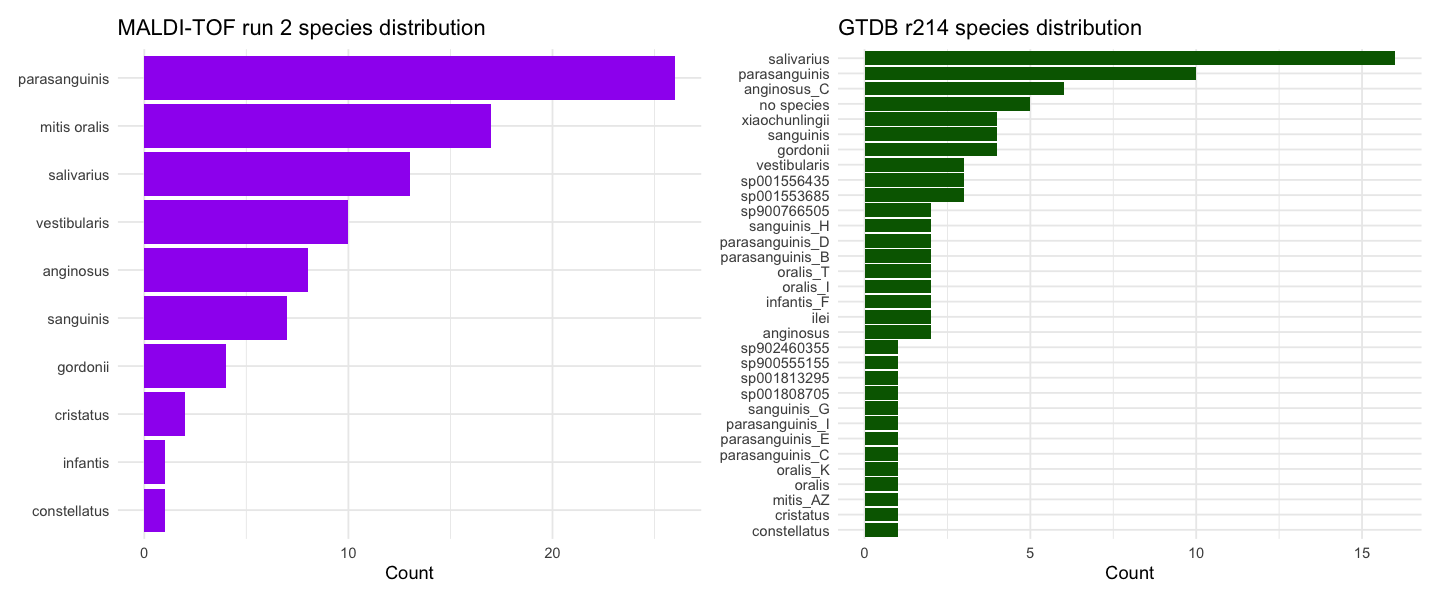

In [12]:
# GTDB_207

p_gtdb <- species_df |>
  count(GTDB_214, sort = TRUE) |>
  ggplot(aes(x = reorder(GTDB_214, n), y = n)) +
  geom_col(fill = "dark green") +
  coord_flip() +
  labs(title = "GTDB r214 species distribution", x = NULL, y = "Count") +
  theme_minimal()

p_maldi <- species_df |>
  count(Maldi_2, sort = TRUE) |>
  ggplot(aes(x = reorder(Maldi_2, n), y = n)) +
  geom_col(fill = "purple") +
  coord_flip() +
  labs(title = "MALDI-TOF run 2 species distribution", x = NULL, y = "Count") +
  theme_minimal()

options(repr.plot.width = 12, repr.plot.height = 5)
p_maldi | p_gtdb




##### Matches and mismatches between GDTB and Maldi 2 results

In [13]:


species_df <- species_df |>
  mutate(
    match_status = case_when(
      GTDB_214 == "no species" ~ "unknown",
      GTDB_214 == Maldi_2 ~ "match",   # exact match only
      TRUE ~ "mismatch"
    )
  )

species_df |> count(match_status)

head(species_df)

match_status,n
<chr>,<int>
match,36
mismatch,48
unknown,5


SAMPLE_ID,Resistance,Maldi_2,GTDB_214,match_status
<chr>,<chr>,<chr>,<chr>,<chr>
43m,NA,mitis oralis,no species,unknown
48m,NA,mitis oralis,sp900555155,mismatch
52a,NA,anginosus,anginosus_C,mismatch
59s,NA,sanguinis,sanguinis_H,mismatch
68g,NA,gordonii,gordonii,match
68m,NA,mitis oralis,no species,unknown


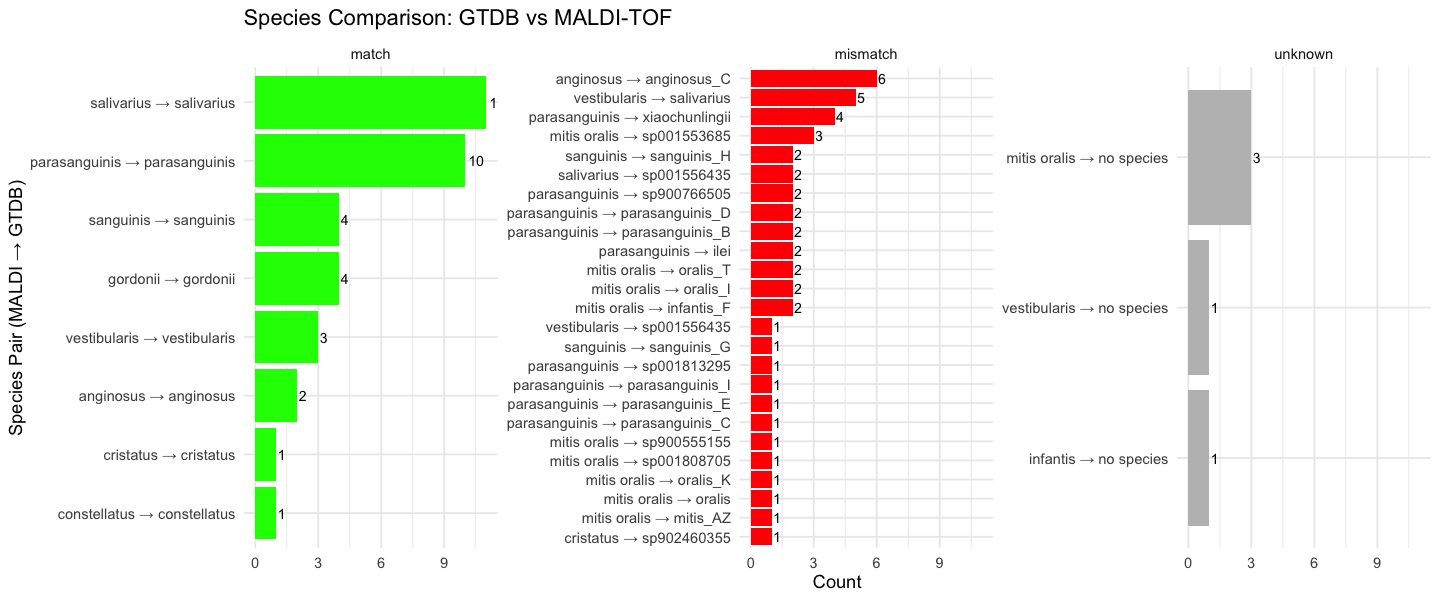

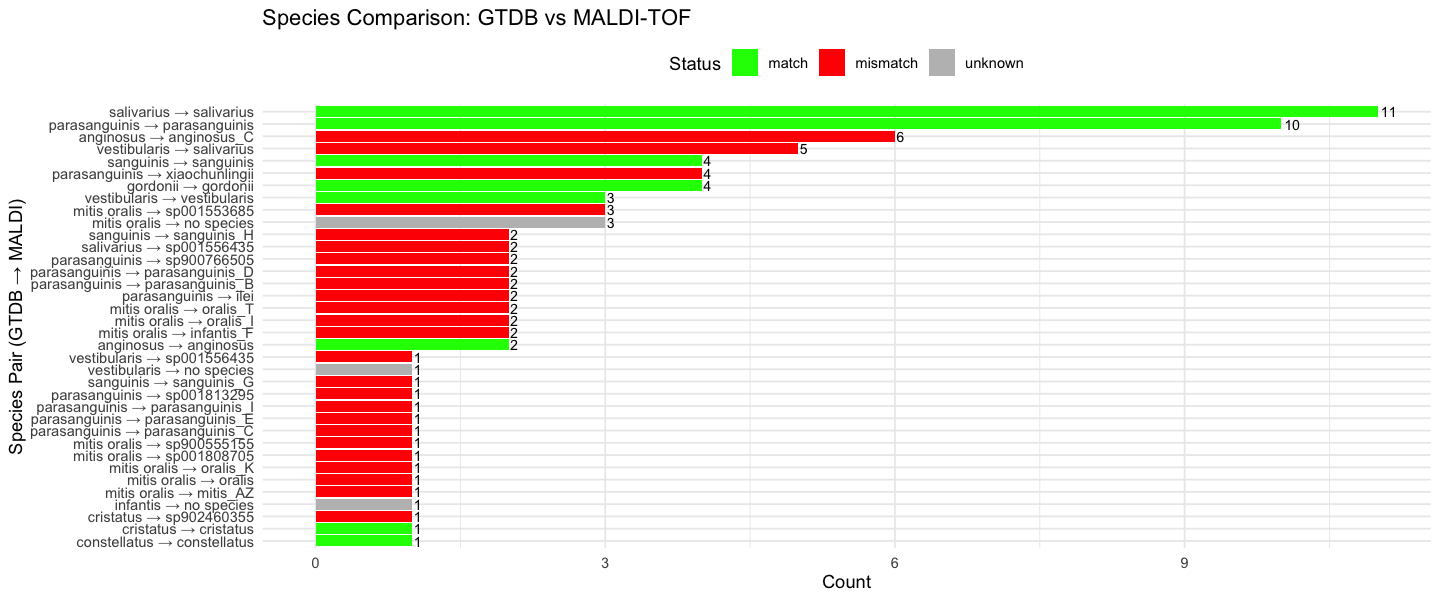

In [14]:
# mismatch counts
mismatch_counts <- species_df |>
  filter(match_status == "mismatch") |>
  count(GTDB_214, Maldi_2, sort = TRUE) |>
  mutate(pair = paste(Maldi_2, "→", GTDB_214))

# match counts
match_counts <- species_df |>
  filter(match_status == "match") |>
  count(GTDB_214, Maldi_2, sort = TRUE) |>
  mutate(pair = paste(Maldi_2, "→", GTDB_214))

# unknown counts
unknown_counts <- species_df |>
  filter(match_status == "unknown") |>
  count(GTDB_214, Maldi_2, sort = TRUE) |>
  mutate(pair = paste(Maldi_2, "→", GTDB_214))

# combined
combined_counts <- bind_rows(
  mismatch_counts |> mutate(status = "mismatch"),
  match_counts |> mutate(status = "match"),
  unknown_counts |> mutate(status = "unknown")
)

#combined_counts

# faceted plot with wider dimensions
ggplot(combined_counts, aes(x = reorder(pair, n), y = n, fill = status)) +
  geom_col() +
  geom_text(aes(label = n), hjust = -0.2, size = 3) +
  coord_flip() +
  facet_wrap(~status, scales = "free_y", nrow = 1) +
  scale_fill_manual(values = c("match" = "green", "mismatch" = "red", "unknown" = "gray")) +
  labs(title = "Species Comparison: GTDB vs MALDI-TOF", 
       x = "Species Pair (MALDI → GTDB)", 
       y = "Count") +
  theme_minimal() +
  theme(legend.position = "none")


# all match statuses together
ggplot(combined_counts, aes(x = reorder(pair, n), y = n, fill = status)) +
  geom_col() +
  geom_text(aes(label = n), hjust = -0.2, size = 3) +
  coord_flip() +
  scale_fill_manual(values = c("match" = "green", "mismatch" = "red", "unknown" = "gray")) +
  labs(title = "Species Comparison: GTDB vs MALDI-TOF", 
       x = "Species Pair (GTDB → MALDI)", 
       y = "Count",
       fill = "Status") +
  theme_minimal() +
  theme(legend.position = "top")



Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”


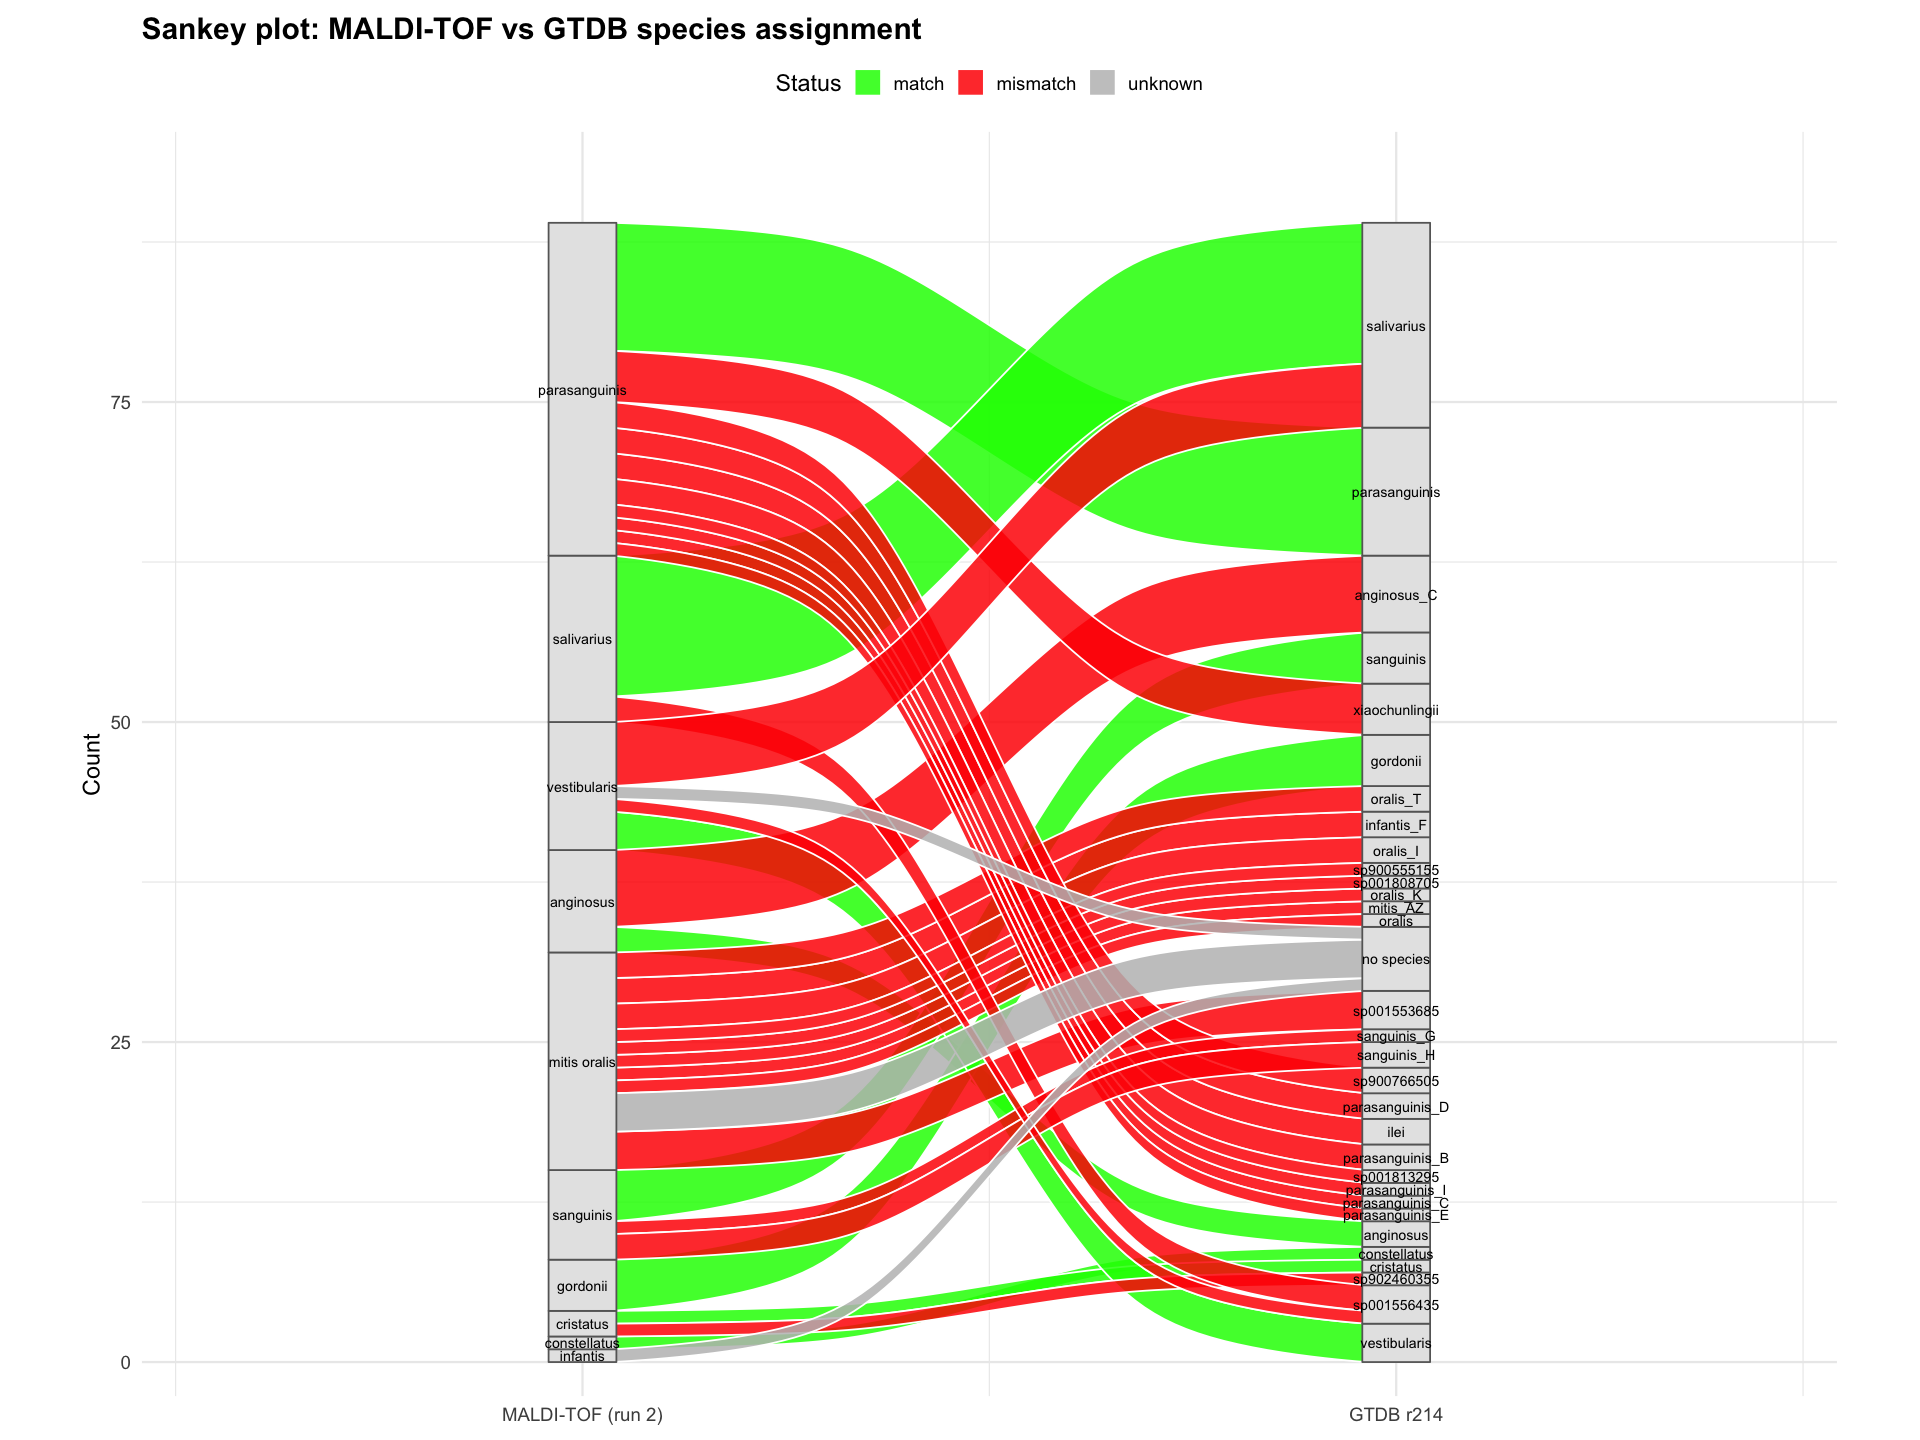

In [15]:
# larger canvas
options(repr.plot.width = 16, repr.plot.height = 12) #repr.plot.res = 140)
theme_set(theme_minimal(base_size = 16))

sankey_df <- species_df |>
  count(Maldi_2, GTDB_214, match_status, name = "n") |>
  filter(!is.na(Maldi_2), !is.na(GTDB_214))

# old alphabetical ordering kept here for reference
# maldi_levels <- sankey_df |>
#   distinct(Maldi_2) |>
#   arrange(Maldi_2) |>
#   pull(Maldi_2)
#
# gtdb_levels <- sankey_df |>
#   distinct(GTDB_214) |>
#   arrange(GTDB_214) |>
#   pull(GTDB_214)

# order by clustering to reduce crossings
flow_mat <- sankey_df |>
  select(Maldi_2, GTDB_214, n) |>
  tidyr::pivot_wider(
    names_from = GTDB_214,
    values_from = n,
    values_fill = 0
  ) |>
  tibble::column_to_rownames("Maldi_2") |>
  as.matrix()

maldi_levels <- if (nrow(flow_mat) > 1) {
  rownames(flow_mat)[hclust(dist(flow_mat))$order]
} else {
  rownames(flow_mat)
}

gtdb_levels <- if (ncol(flow_mat) > 1) {
  colnames(flow_mat)[hclust(dist(t(flow_mat)))$order]
} else {
  colnames(flow_mat)
}

sankey_df <- sankey_df |>
  mutate(
    Maldi_2 = factor(Maldi_2, levels = maldi_levels),
    GTDB_214 = factor(GTDB_214, levels = gtdb_levels),
    Maldi_2_num = as.numeric(Maldi_2),
    GTDB_214_num = as.numeric(GTDB_214)
  )

# Create lookup vectors
maldi_lookup <- setNames(as.character(maldi_levels), seq_along(maldi_levels))
gtdb_lookup <- setNames(as.character(gtdb_levels), seq_along(gtdb_levels))

ggplot(
  sankey_df,
  aes(axis1 = Maldi_2_num, axis2 = GTDB_214_num, y = n)
) +
  geom_alluvium(
    aes(fill = match_status),
    width = 1/14,
    alpha = 0.85,
    knot.pos = 0.35,
    colour = "white",
    linewidth = 0.5
  ) +
  geom_stratum(width = 1/12, fill = "grey90", color = "grey40") +
  geom_text(
    stat = "stratum",
    aes(label = after_stat(
      ifelse(x == 1,
             maldi_lookup[stratum],
             gtdb_lookup[stratum])
    )),
    size = 3,
    check_overlap = FALSE
  ) +
  scale_x_continuous(breaks = c(1, 2), labels = c("MALDI-TOF (run 2)", "GTDB r214"), expand = c(0.24, 0.24)) +
  scale_y_continuous(expand = expansion(mult = c(0.03, 0.08))) +
  scale_fill_manual(values = c("match" = "green", "mismatch" = "red", "unknown" = "gray")) +
  labs(
    title = "Sankey plot: MALDI-TOF vs GTDB species assignment",
    y = "Count",
    fill = "Status"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.title.x = element_blank(),
    legend.position = "top",
    plot.title = element_text(size = 18, face = "bold"),
    plot.margin = margin(10, 50, 10, 50)
  )

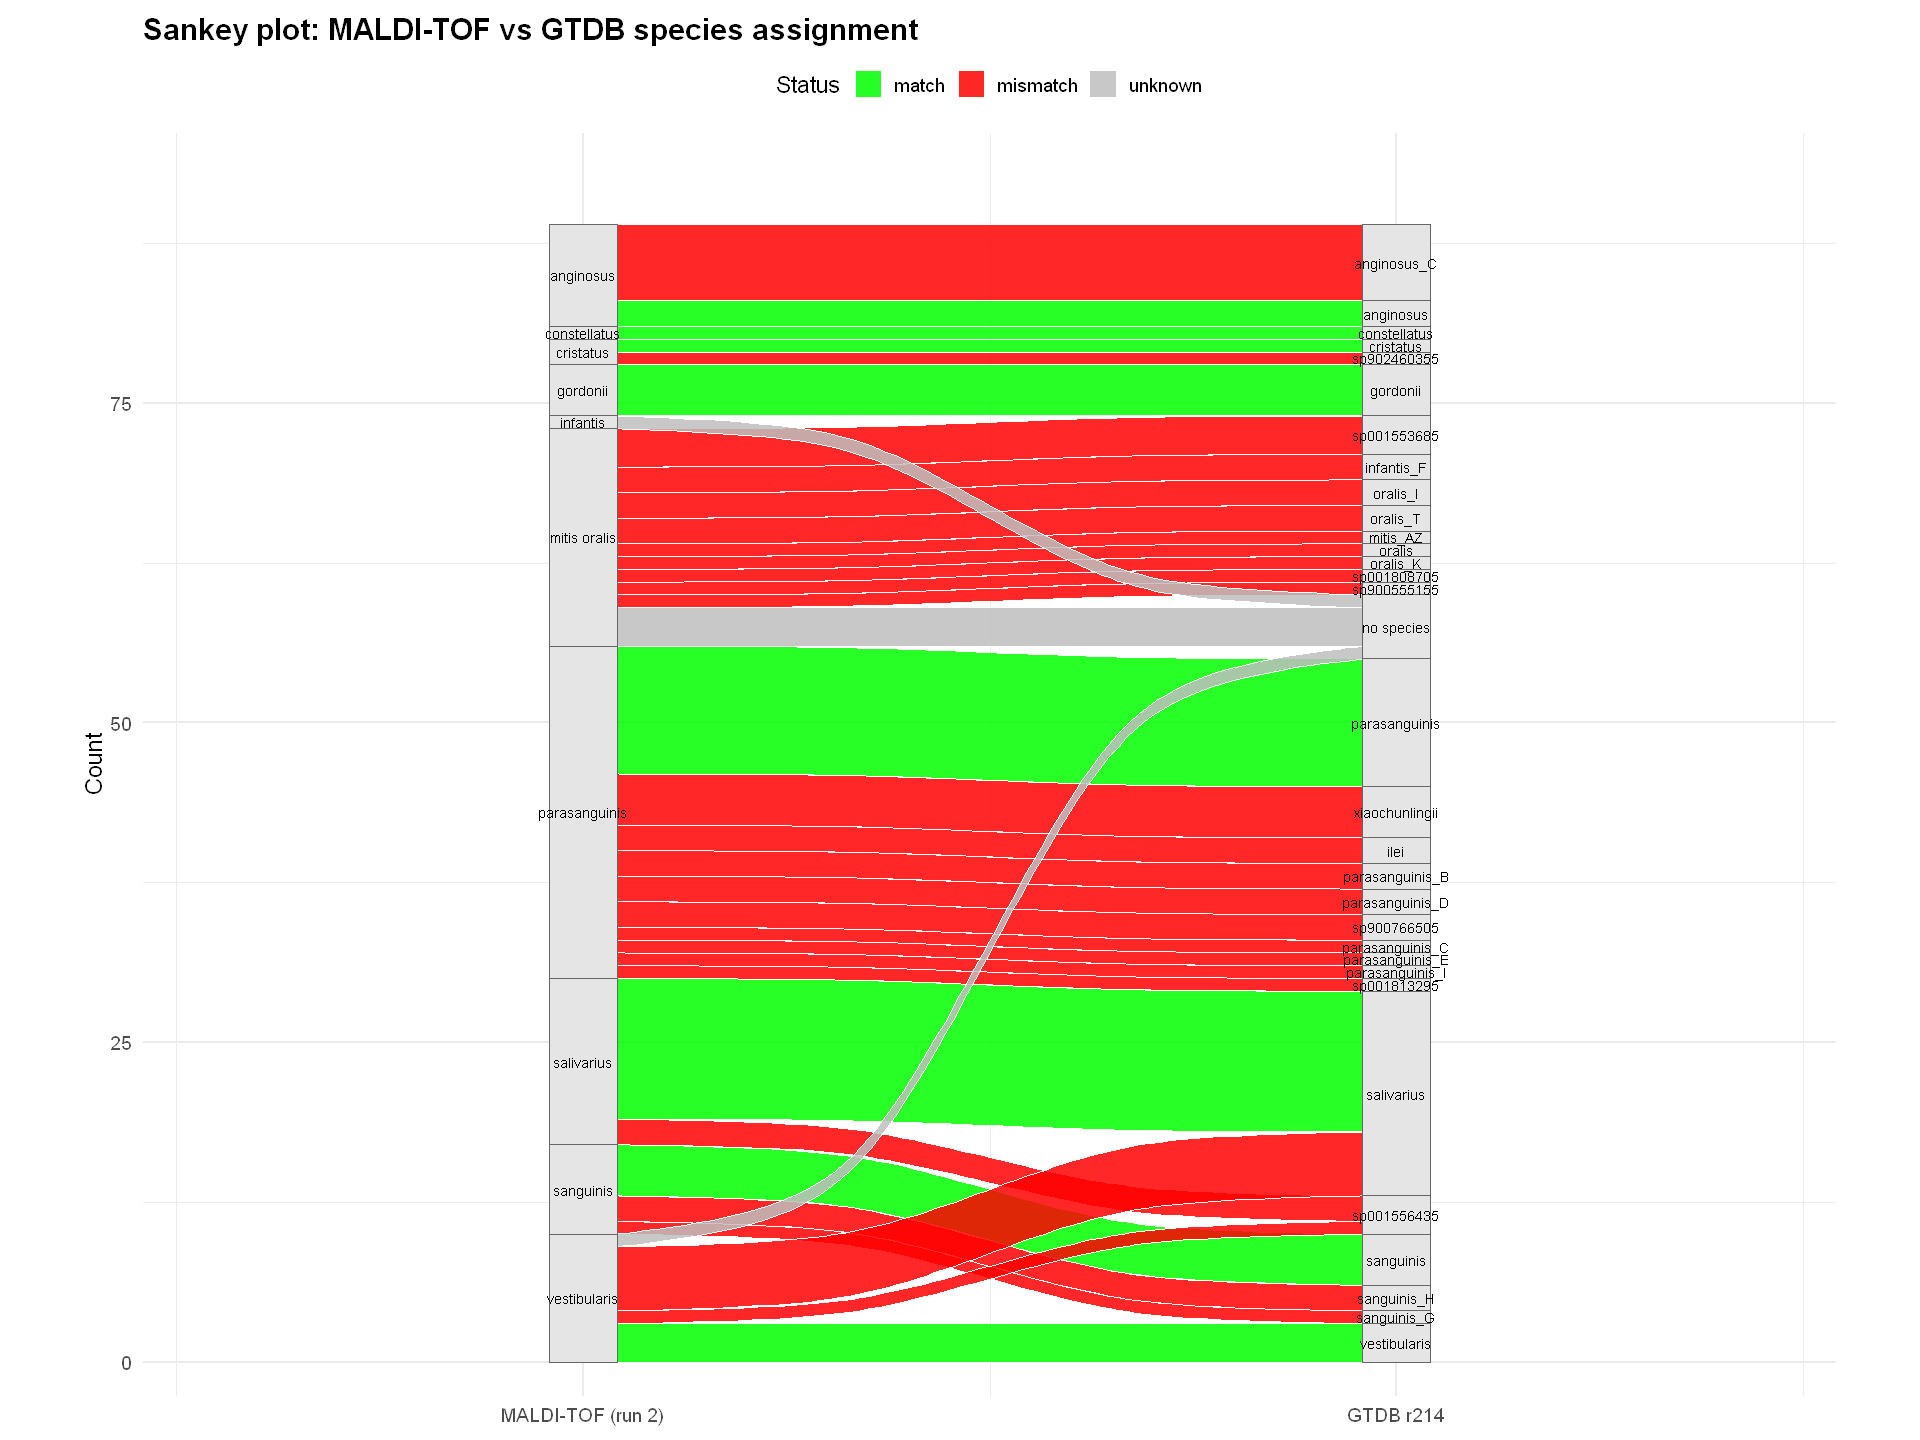
## Antibiotic resistance

AMRFinder is the main tool.

Antimicrobial resistance gene identification will be run using ResFinder and AMRFinderPlus with all 96 genomes.

Detection thresholds are set to minimum 90% (or default of the gene) nucleotide identity and 50% gene coverage, which are the default settings for AMRFinder.

https://github.com/ncbi/amr/wiki/Running-AMRFinderPlus#usage :  
--ident_min <0-1> or -i <0-1> Minimum identity for a blast-based hit hit (Methods BLAST or PARTIAL). -1 means use the curated threshold if it exists and 0.9 otherwise. Setting this value to something other than -1 will override curated similarity cutoffs. We only recommend using this option if you have a specific reason; don't make our curators sad by throwing away some of their hard work.





### ResFinder 4.7.2

**output files** in each of the 96 directories of *resfinder_results* directory:

ResFinder_results_tab.txt	    |    Main tabular results — AMR genes found
ResFinder_results.txt	        |    Detailed alignment results
PointFinder_results.txt	        |    Point mutation results
pheno_table.txt	                |    Predicted phenotypic resistance per antibiotic class

### AMR finder

using amrfinder version 4.2.7: https://github.com/ncbi/amr/wiki

AMRFinder has the option to activate species-specific resistance rules, such as point mutation detection, gene interpretation rules and curated resistance models. The available Streptococcus organisms supported by AMRFinder are:
- Streptococcus_agalactiae
- Streptococcus_pneumoniae
- Streptococcus_pyogenes

None of them have been found among the Streptococcus species in our data.
Therefore I will omit specifying any organism.

### Analysis

##### Load data

NOTE: Quality control filtering was applied above with Genome_sequencing_qc == Pass and Exclude == KEEP.
ResFinder and AMRFinder were both run on all 96 assemblies, but in the analysis below the results are filtered to the 89 kept samples by joining on GM_FILE_ID and automatically dropping excluded samples from further analysis.

2 versions of ResFinder were run. The following analysis uses the results from ResFinder version 4.7.2

In [16]:
# resfinder pheno table
pheno <- read_tsv("../results/amr/combined_pheno_def.tsv", show_col_types = FALSE)

# resfinder raw genes
res <- read_tsv("../results/amr/combined_resfinder_default.tsv", show_col_types = FALSE)

#fix amr file
raw_lines <- read_lines("../results/amr/combined_amrfinder_def.tsv")
fixed_lines <- str_replace(raw_lines, "^combined\t", "")
write_lines(fixed_lines, "../results/amr/combined_amrfinder_def.tsv")

amr <- read_tsv("../results/amr/combined_amrfinder_def.tsv", show_col_types = FALSE) |>
    rename_with(~ str_replace_all(., ' ', '_') |> str_to_lower())



cat('pheno rows:', nrow(pheno), '\n')
cat('res rows:  ', nrow(res), '\n')
cat('amr rows:  ', nrow(amr), 'columns:', ncol(amr), '\n')

n_distinct(amr$sample)
n_distinct(res$Sample)

pheno rows: 8736 
res rows:   249 
amr rows:   241 columns: 23 


[1] 80

[1] 80

##### Filter to QC-passed samples only



In [17]:
valid_ids <- df_filtered |> pull(GM_FILE_ID)


pheno_clean <- pheno |> filter(Sample %in% valid_ids)
res_clean   <- res   |> filter(Sample %in% valid_ids)
amr_clean   <- amr   |> filter(sample %in% valid_ids)

cat('Samples in pheno after QC filter:', n_distinct(pheno_clean$Sample), '\n')
cat('Samples in ResFinder after QC filter:', n_distinct(res_clean$Sample), '\n')
cat('Samples in AMRFinder after QC filter:', n_distinct(amr_clean$sample), '\n')

Samples in pheno after QC filter: 89 
Samples in ResFinder after QC filter: 76 
Samples in AMRFinder after QC filter: 76 


In [18]:
amr_clean |> group_by(element_symbol) |> count()


element_symbol,n
<chr>,<int>
catA,1
erm(B),46
lsa,1
lsa(C),5
mef(A),35
msr(D),35
tet(32),1
tet(M),53
tet(O),2


ResFinder's pheno_table.txt outputs phenotypic predictions for every sample, even if no genes were found; it predicts resistance/susceptibility for each antibiotic class based on gene presence - all 89 QC-passed samples have phenotype predictions.

Both gene resistance finders only output rows if they detect a gene match for the sample. 13 samples had no detectable genes. These are likely susceptible to all antibiotics / just tolerant.

In [19]:
df_filtered |> group_by(Resistance) |> count()

Resistance,n
<chr>,<int>
Ampicillin_resistant,19
Clindamycin_resistant,45
Penicillin_resistant,10
NA,15


#### Phenotypic resistance


In [20]:


pheno_clean |> filter(WGS_phenotype != "No resistance") |> filter(Antimicrobial == "ampicillin")



Sample,Antimicrobial,Class,WGS_phenotype,Match,Genetic_background
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>


In [21]:
pheno_clean |> 
filter(WGS_phenotype != "No resistance") |>
left_join(
    df_filtered |>
    select(GM_FILE_ID, `Zone diameter`, Resistance),
    by = c("Sample" = "GM_FILE_ID")
) |>
  write_tsv("../results/amr/antimicrobial_resistance_output.tsv")


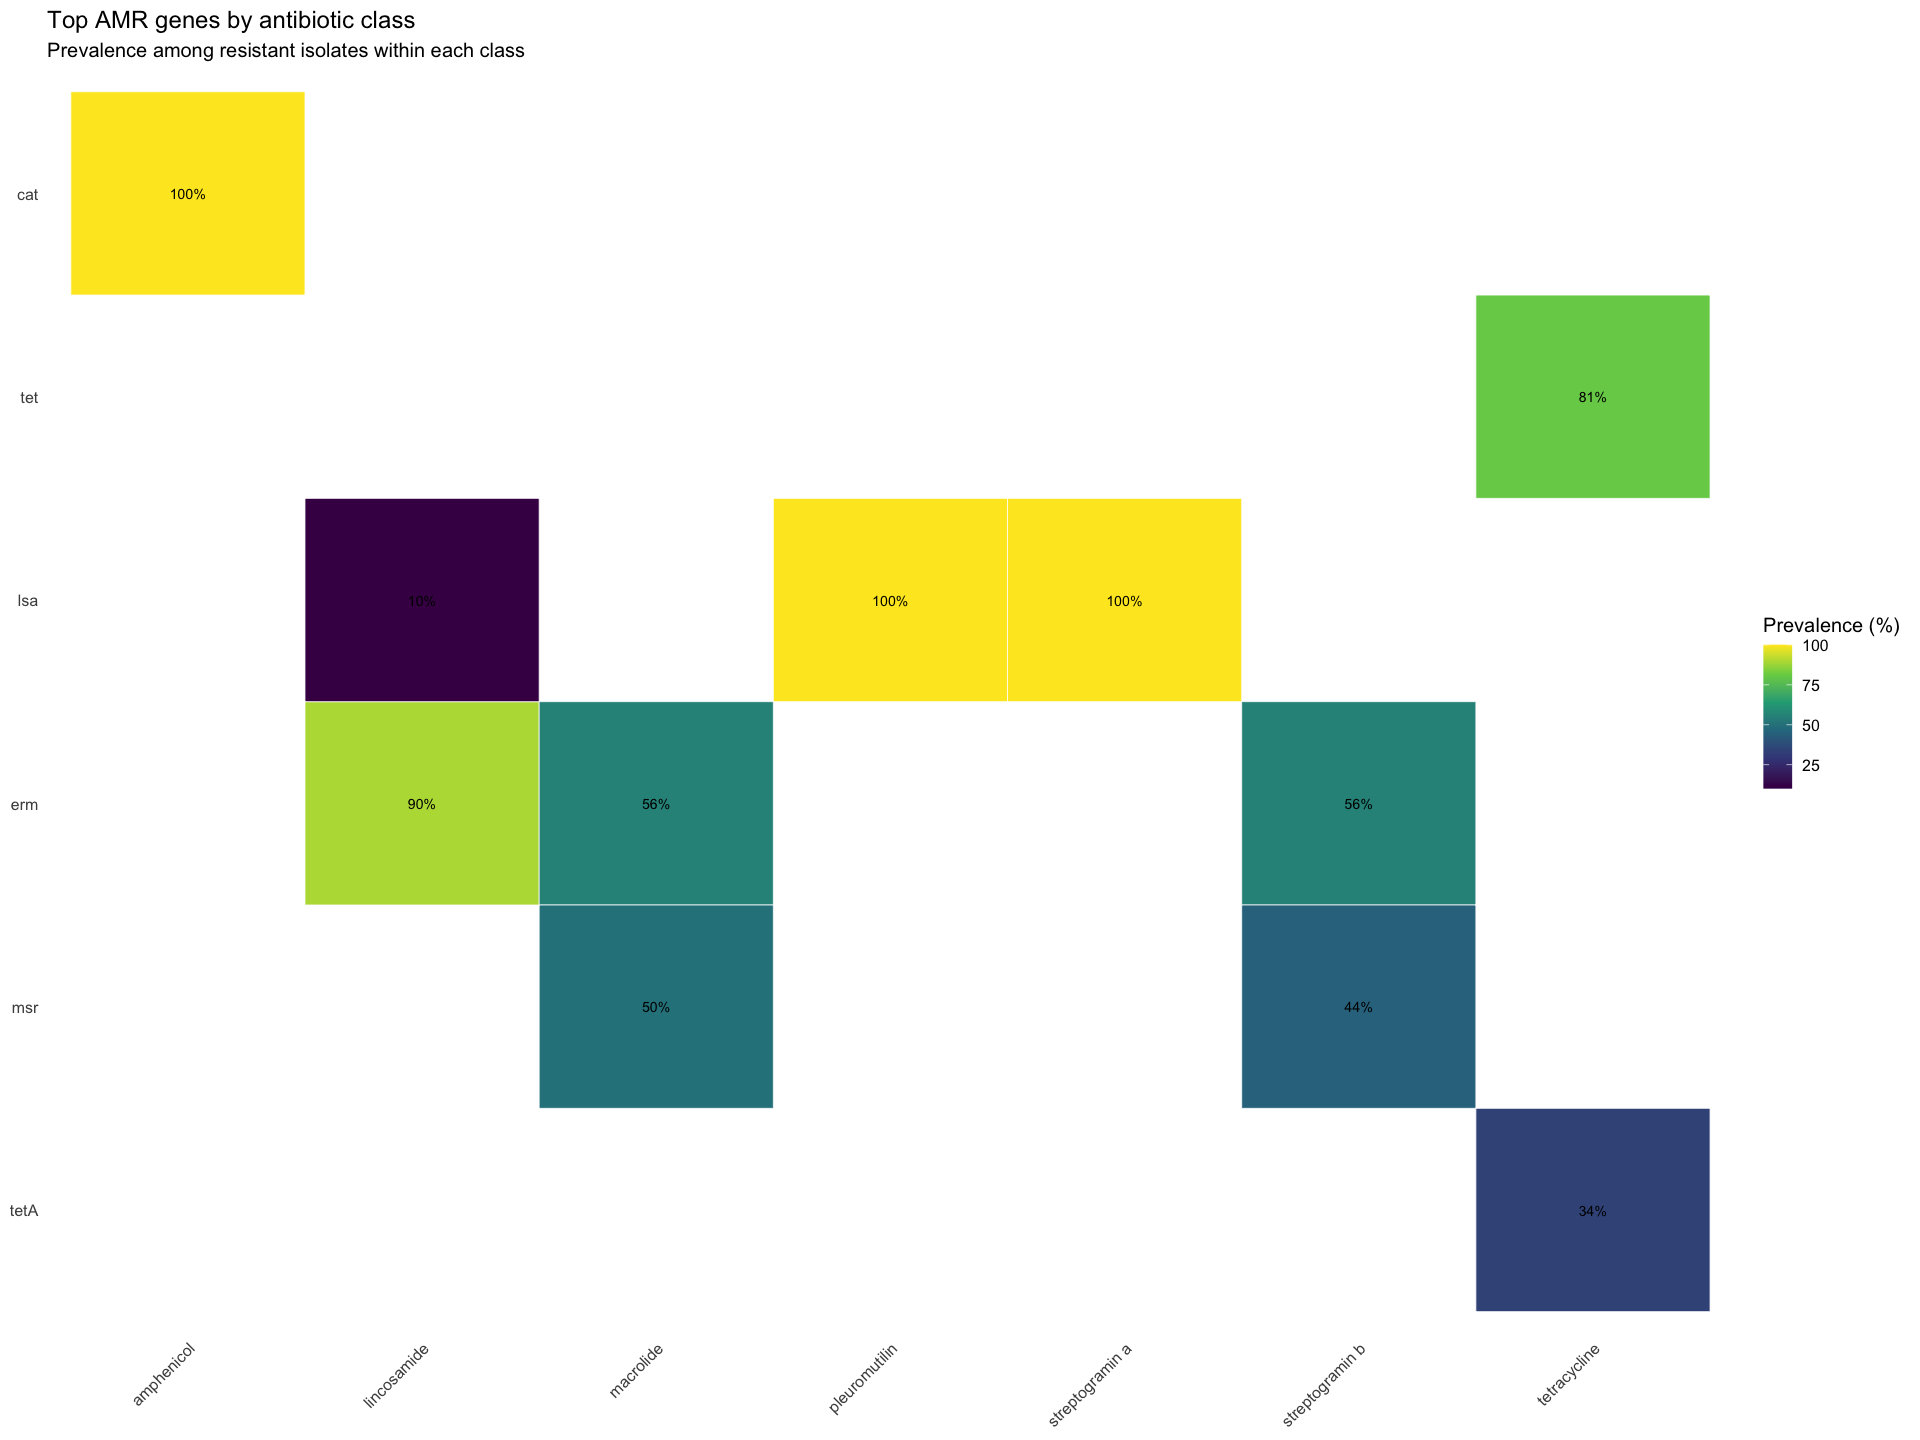

In [22]:
# Top AMR genes by antibiotic class
pheno_resistant <- pheno_clean |>
  filter(WGS_phenotype == "Resistant") |>
  filter(!is.na(Genetic_background), Genetic_background != "")

gene_class <- pheno_resistant |>
  separate_rows(Genetic_background, sep = ",") |>
  mutate(
    gene = str_extract(Genetic_background, "^[^\\s(]+") |>
      str_trim()
  ) |>
  filter(!is.na(gene), gene != "") |>
  distinct(Sample, Class, gene)

class_totals <- pheno_resistant |>
  distinct(Sample, Class) |>
  count(Class, name = "n_resistant_isolates")

gene_class_prevalence <- gene_class |>
  count(Class, gene, name = "n") |>
  left_join(class_totals, by = "Class") |>
  mutate(prevalence = 100 * n / n_resistant_isolates) |>
  group_by(Class) |>
  slice_max(prevalence, n = 8, with_ties = FALSE) |>
  ungroup()

ggplot(gene_class_prevalence, aes(x = Class, y = reorder(gene, prevalence), fill = prevalence)) +
  geom_tile(color = "white") +
  geom_text(aes(label = sprintf("%.0f%%", prevalence)), size = 3) +
  scale_fill_viridis_c(name = "Prevalence (%)") +
  labs(
    title = "Top AMR genes by antibiotic class",
    subtitle = "Prevalence among resistant isolates within each class",
    x = NULL,
    y = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid = element_blank()
  )

options(repr.plot.width = 14, repr.plot.height = 10)


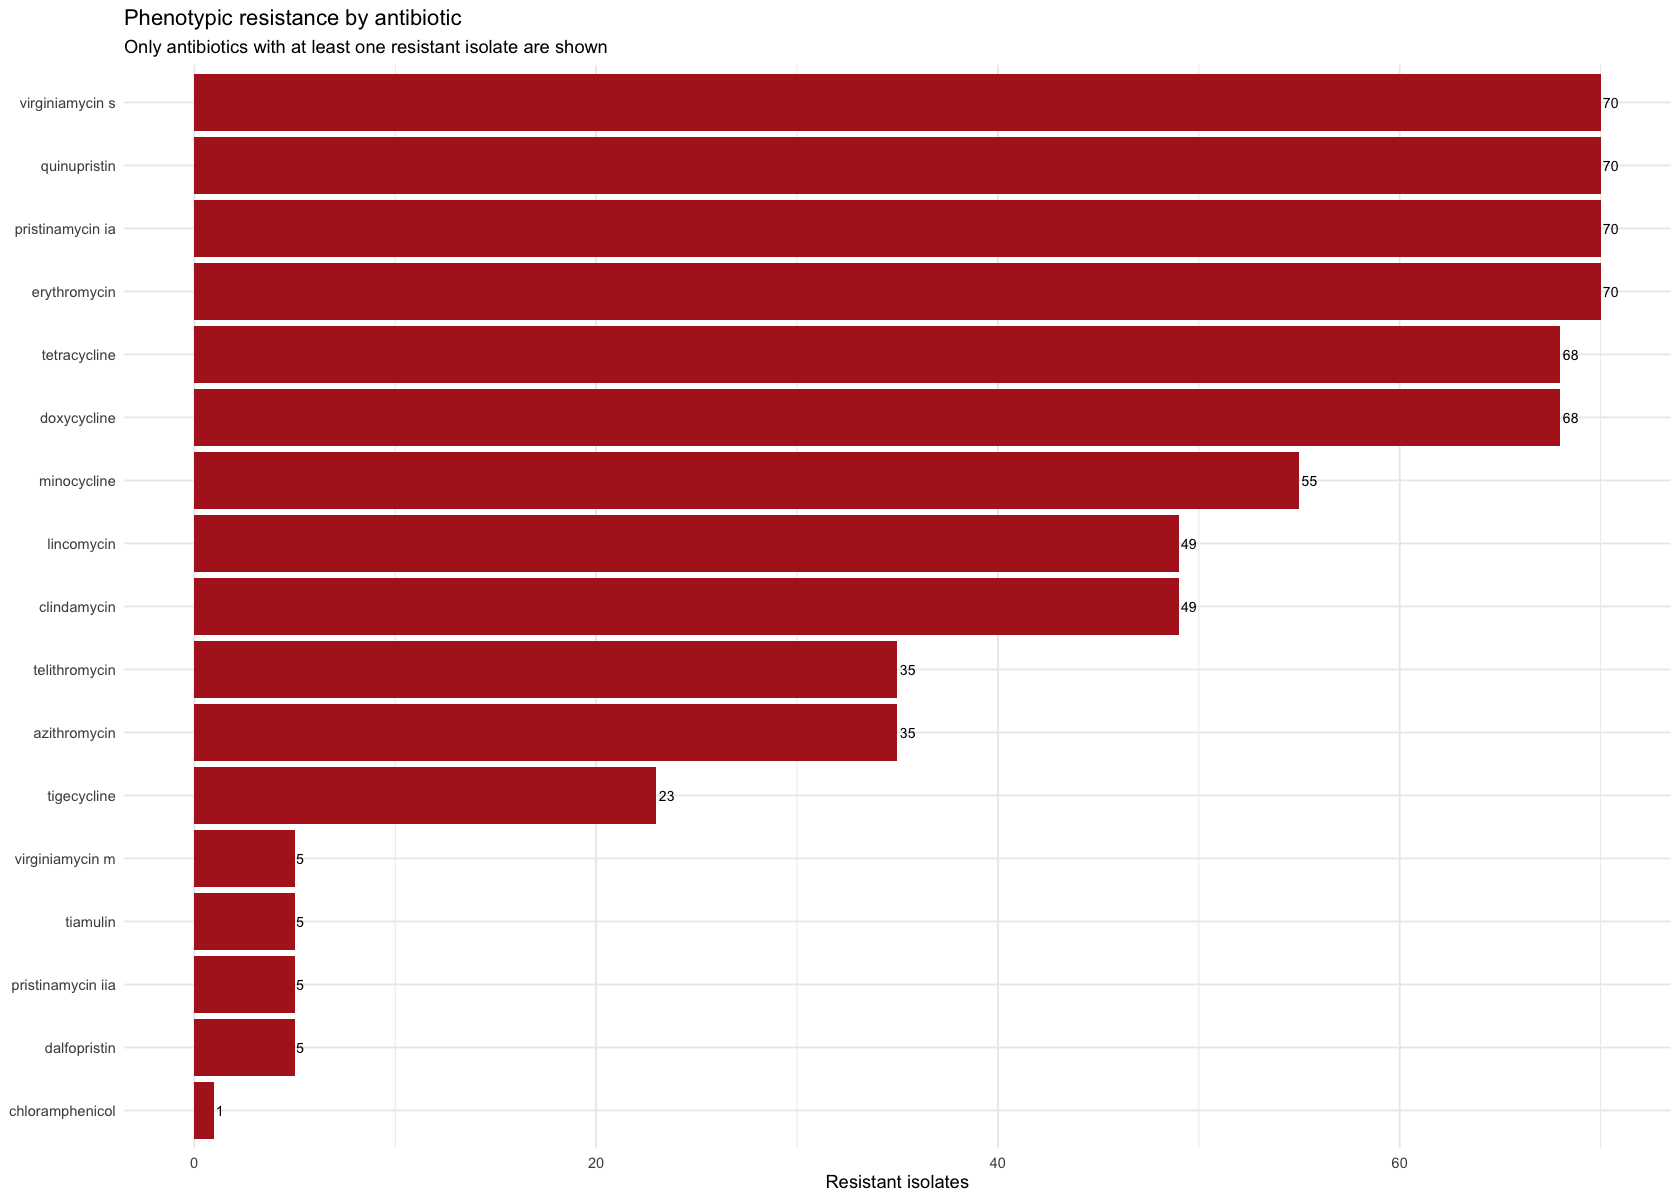

In [23]:

res_counts <- pheno_clean |>
  filter(WGS_phenotype == "Resistant") |>
  count(Antimicrobial) |>
  right_join(tibble(Antimicrobial = sort(unique(pheno_clean$Antimicrobial))),
             by = "Antimicrobial") |>
  mutate(n = replace_na(n, 0))

nonzero <- res_counts |> filter(n > 0)
zeroes  <- res_counts |> filter(n == 0)

ggplot(nonzero, aes(x = reorder(Antimicrobial, n), y = n)) +
  geom_col(fill = "firebrick") +
  geom_text(aes(label = n), hjust = -0.15, size = 3) +
  coord_flip() +
  labs(
    x = NULL,
    y = "Resistant isolates",
    title = "Phenotypic resistance by antibiotic",
    subtitle = "Only antibiotics with at least one resistant isolate are shown"
  ) +
  theme_minimal()



##### Genes vs antibiotics

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `zone_diameter = parse_number(...)`.
Caused by warning:
! 11 parsing failures.
row col expected actual
  1  -- a number       
  2  -- a number       
  3  -- a number       
  4  -- a number       
  5  -- a number       
... ... ........ ......
See problems(...) for more details.”


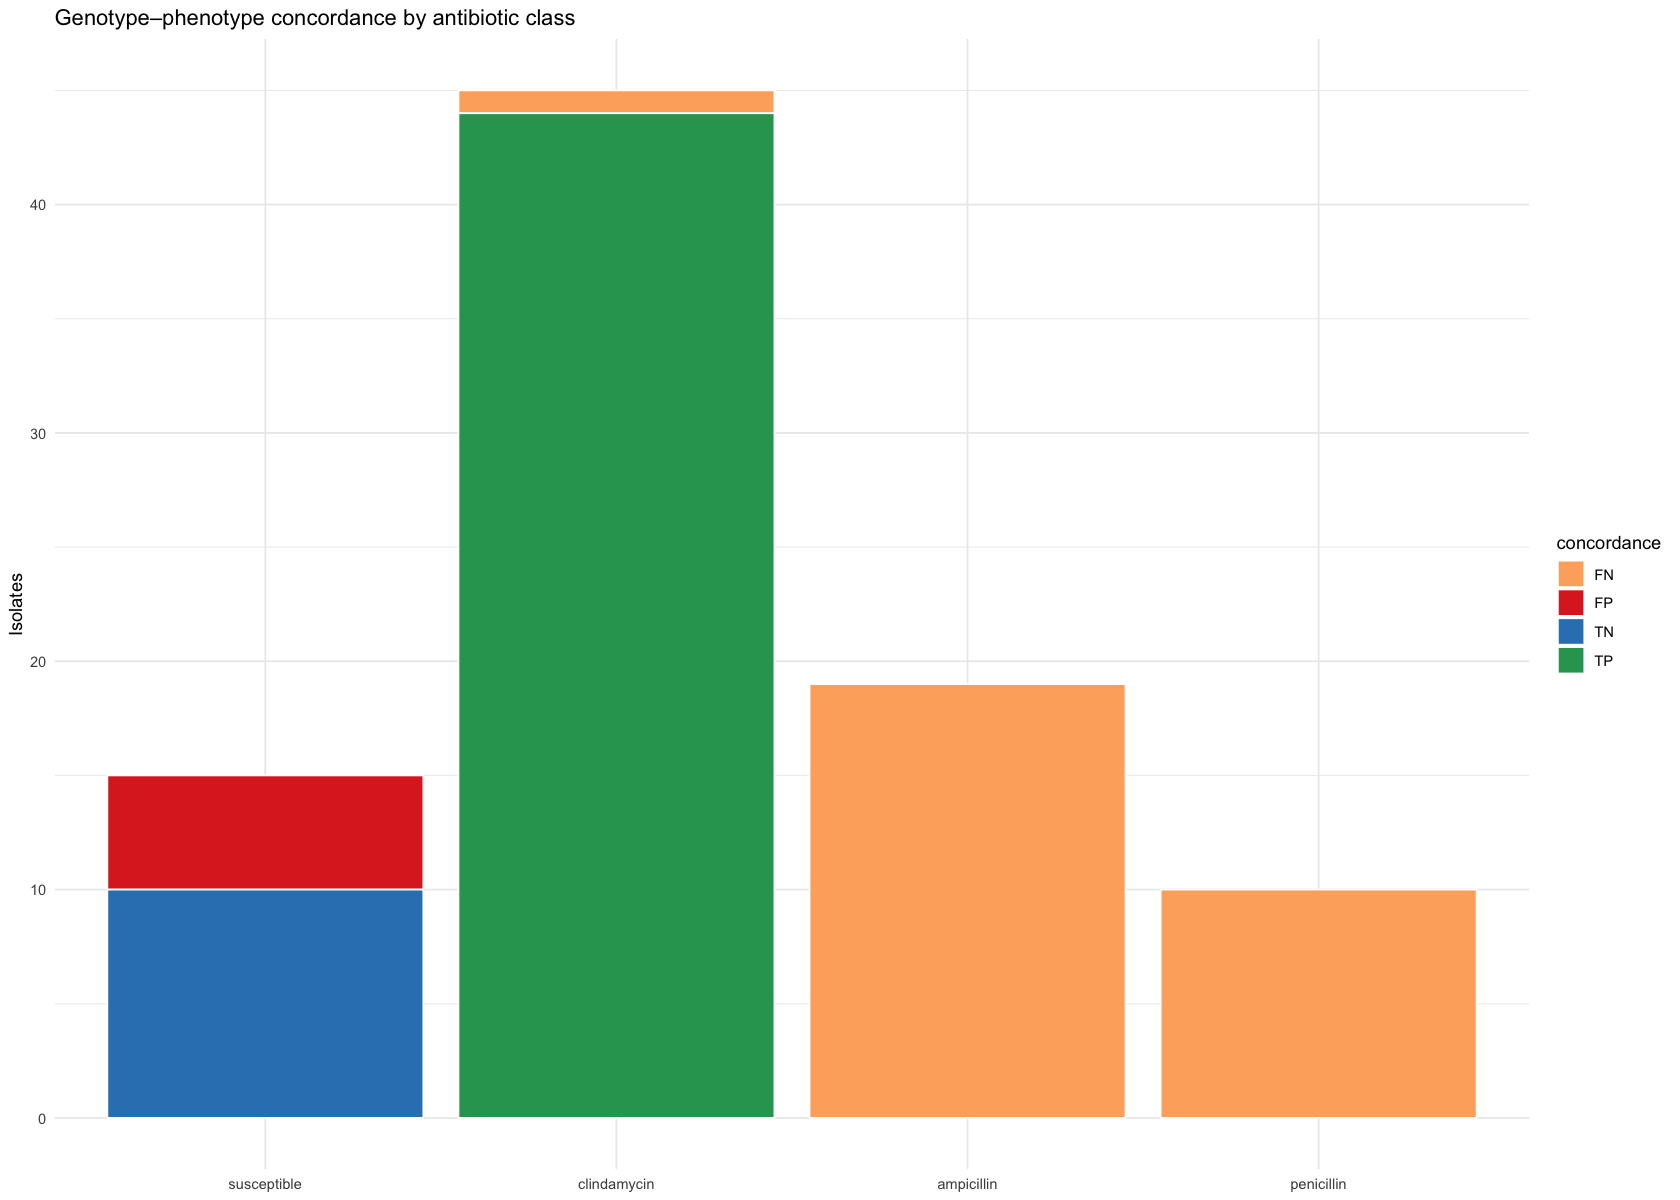

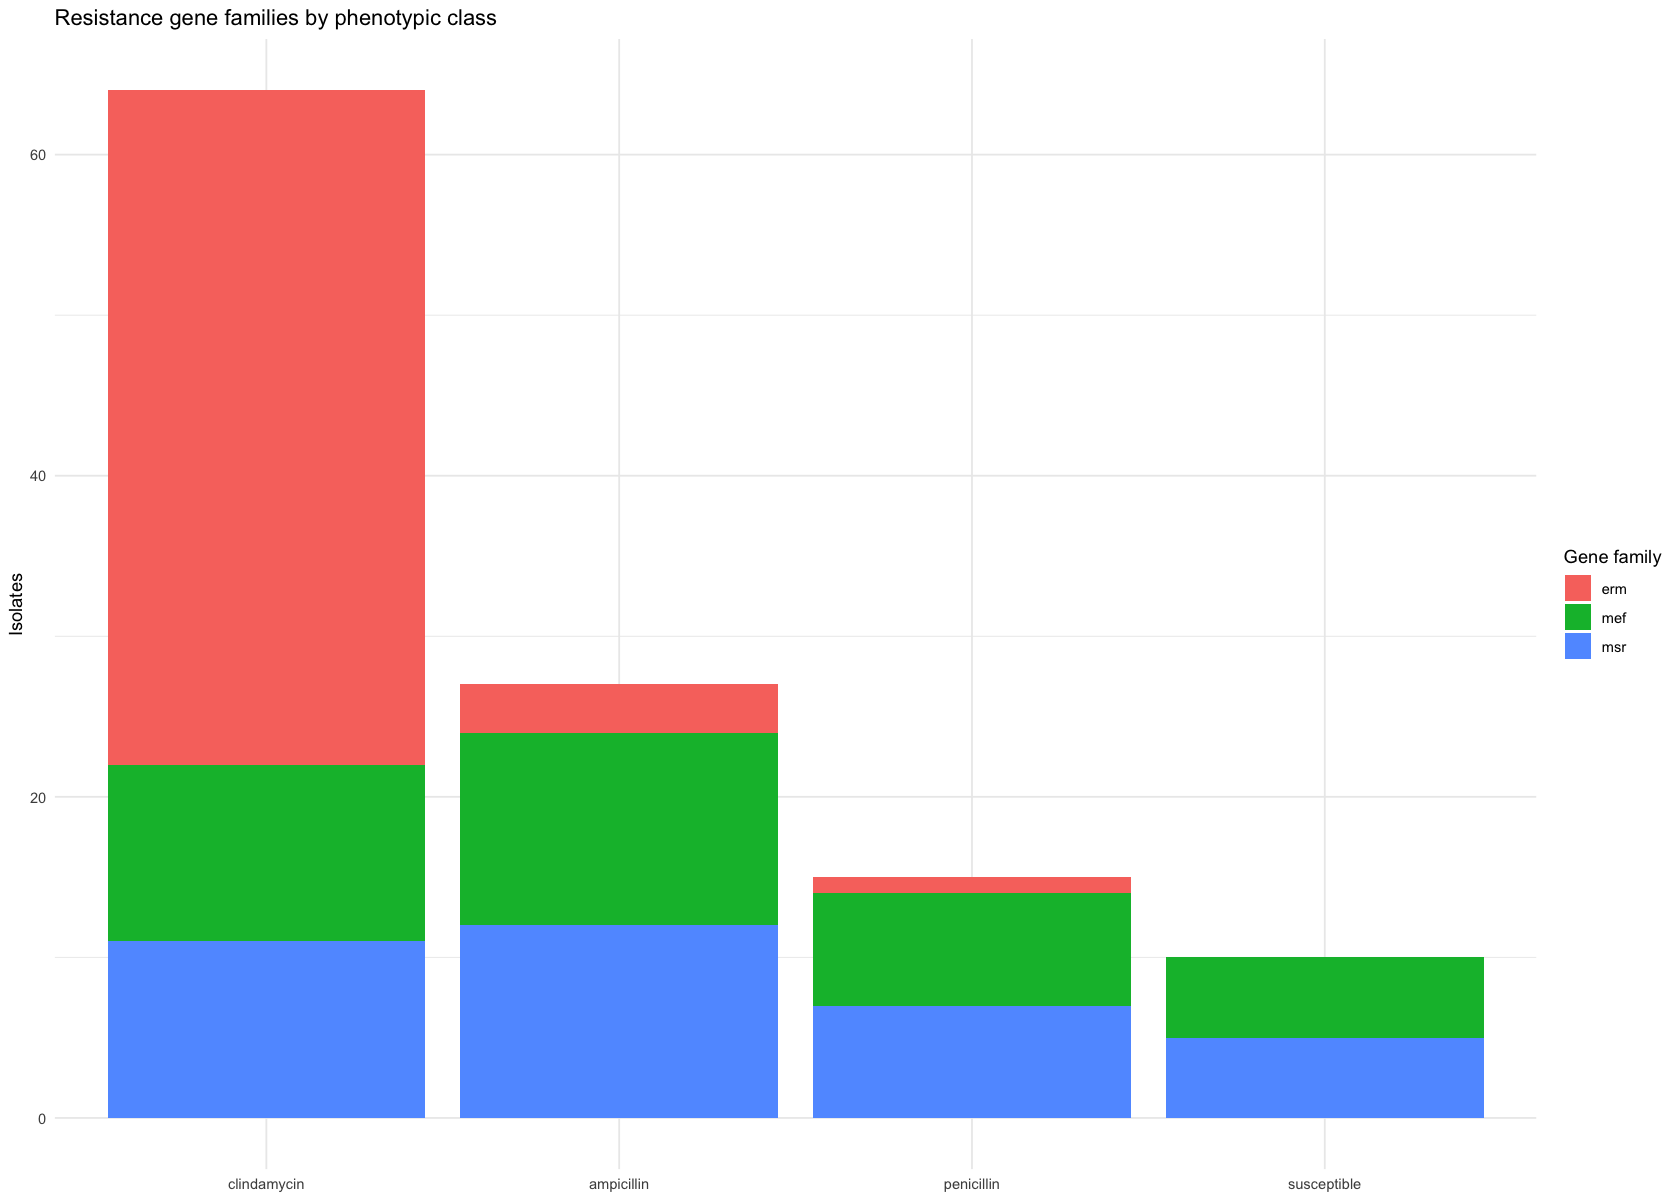

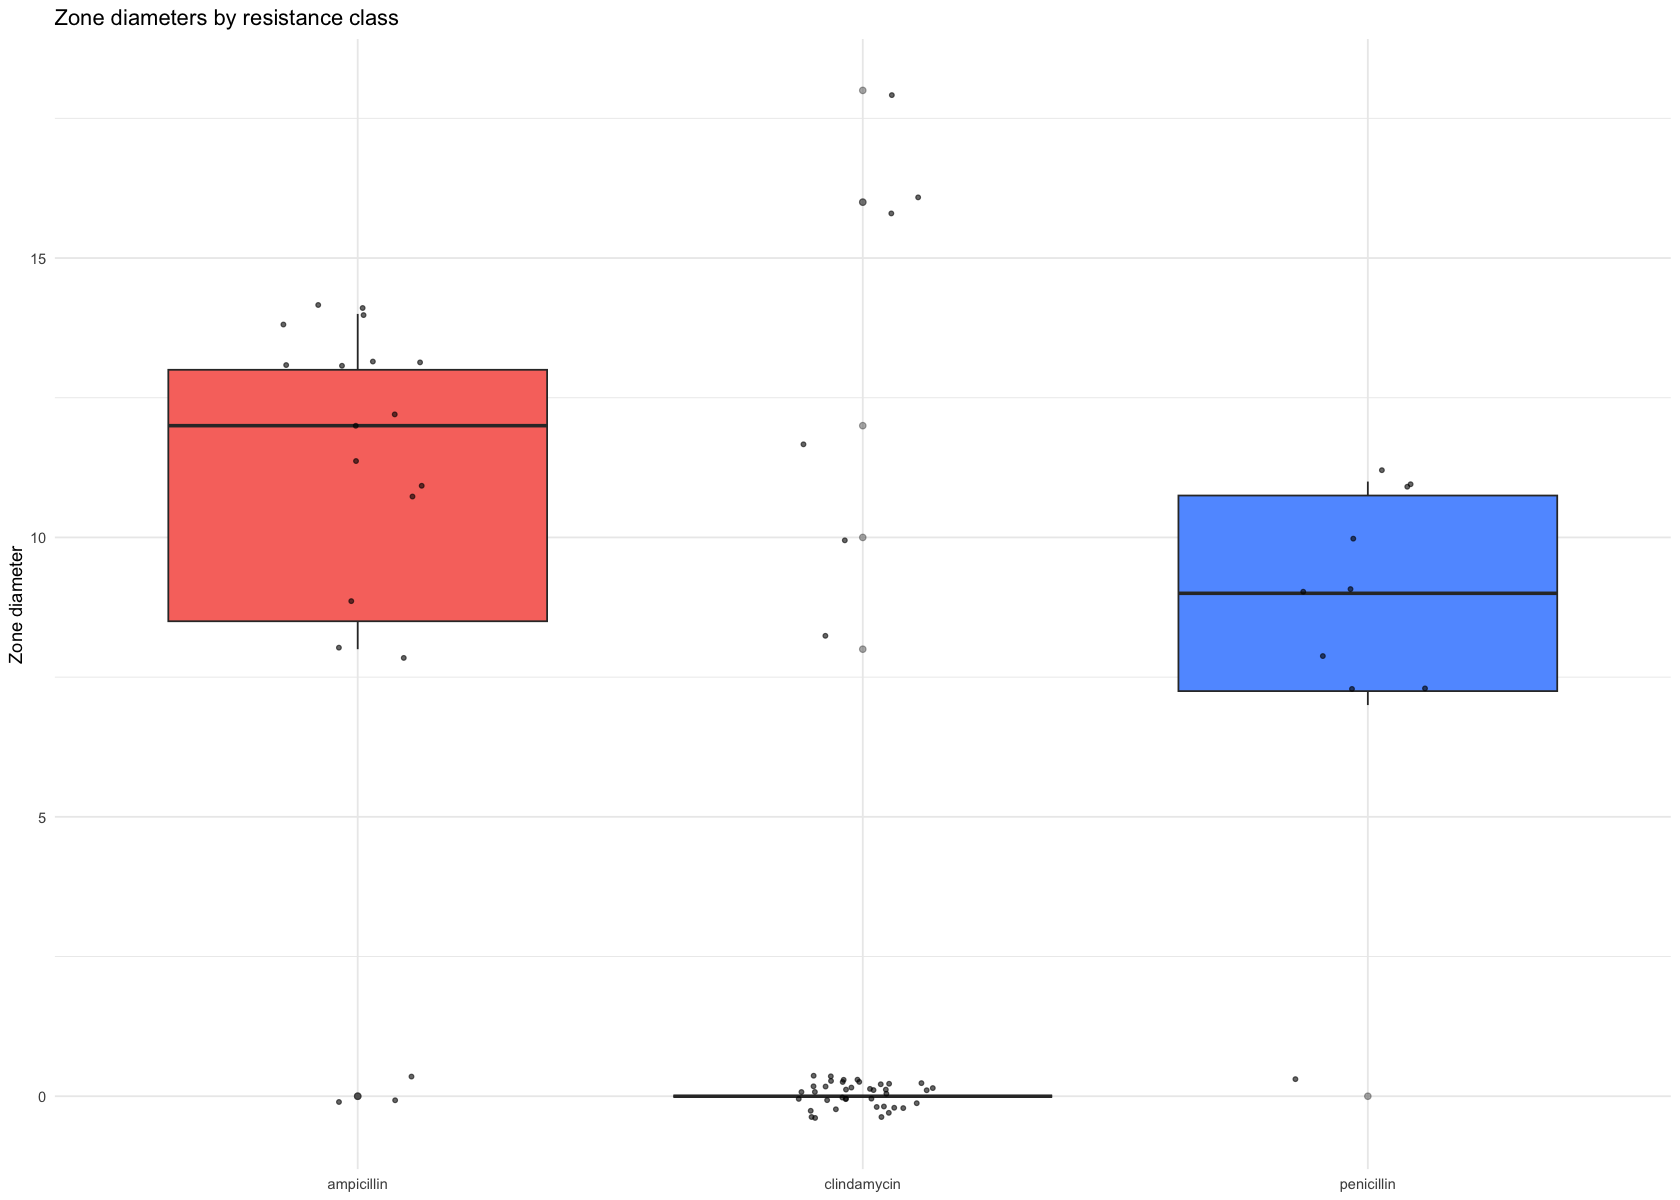

In [24]:
# --- Concordance: phenotype vs genotype ---

clean_id <- function(x) {
  x |>
    as.character() |>
    stringr::str_remove("-.*$") |>
    stringr::str_remove("^0+") |>
    stringr::str_to_lower()
}

phenotype_tbl <- df_filtered |>
  mutate(
    sample_id = clean_id(GM_FILE_ID),
    phenotype_class = case_when(
      str_detect(Resistance, "Clindamycin") ~ "clindamycin",
      str_detect(Resistance, "Ampicillin")  ~ "ampicillin",
      str_detect(Resistance, "Penicillin")   ~ "penicillin",
      TRUE ~ "susceptible"
    ),
    zone_diameter = parse_number(str_replace_all(as.character(`Zone diameter`), ",", "."))
  ) |>
  select(sample_id, SAMPLE_ID, phenotype_class, zone_diameter) |>
  distinct(sample_id, .keep_all = TRUE)

amr_tbl <- amr_clean |>
  mutate(
    sample_id = clean_id(sample),
    gene_family = case_when(
      str_detect(element_symbol, "^erm") ~ "erm",
      str_detect(element_symbol, "^msr") ~ "msr",
      str_detect(element_symbol, "^mef") ~ "mef",
      str_detect(element_symbol, "^bla") ~ "bla",
      str_detect(element_symbol, "^pbp") ~ "pbp",
      TRUE ~ NA_character_
    ),
    gene_class = case_when(
      gene_family %in% c("erm", "msr", "mef") ~ "clindamycin",
      gene_family %in% c("bla", "pbp") ~ "beta-lactam",
      TRUE ~ NA_character_
    )
  ) |>
  filter(!is.na(gene_class)) |>
  distinct(sample_id, gene_family, gene_class)

# one row per isolate with genotype summary
geno_summary <- amr_tbl |>
  group_by(sample_id) |>
  summarise(
    any_gene = TRUE,
    matching_gene = paste(unique(gene_family), collapse = ", "),
    matching_class = paste(unique(gene_class), collapse = ", "),
    .groups = "drop"
  )

concordance_tbl <- phenotype_tbl |>
  left_join(geno_summary, by = "sample_id") |>
  mutate(
    any_gene = coalesce(any_gene, FALSE),
    expected_class = case_when(
      phenotype_class == "clindamycin" ~ "clindamycin",
      phenotype_class %in% c("ampicillin", "penicillin") ~ "beta-lactam",
      TRUE ~ NA_character_
    ),
    has_expected_gene = if_else(
      is.na(expected_class),
      FALSE,
      map2_lgl(sample_id, expected_class, \(id, cls) {
        any(amr_tbl$sample_id == id & amr_tbl$gene_class == cls)
      })
    ),
    concordance = case_when(
      phenotype_class != "susceptible" & has_expected_gene ~ "TP",
      phenotype_class != "susceptible" & !has_expected_gene ~ "FN",
      phenotype_class == "susceptible" & any_gene ~ "FP",
      phenotype_class == "susceptible" & !any_gene ~ "TN"
    )
  )

write_tsv(concordance_tbl, "../results/amr/concordance_table.tsv")

# --- 1) Concordance summary plot ---
concordance_counts <- concordance_tbl |>
  count(phenotype_class, concordance) |>
  mutate(phenotype_class = factor(phenotype_class, levels = c("susceptible", "clindamycin", "ampicillin", "penicillin")))

ggplot(concordance_counts, aes(x = phenotype_class, y = n, fill = concordance)) +
  geom_col(color = "white") +
  labs(
    title = "Genotype–phenotype concordance by antibiotic class",
    x = NULL,
    y = "Isolates"
  ) +
  scale_fill_manual(values = c(TP = "#2ca25f", TN = "#3182bd", FP = "#de2d26", FN = "#fdae6b")) +
  theme_minimal()

# --- 2) Gene-family breakdown by phenotype class ---
gene_family_breakdown <- amr_tbl |>
  distinct(sample_id, gene_family) |>
  inner_join(phenotype_tbl, by = "sample_id") |>
  count(phenotype_class, gene_family) |>
  mutate(phenotype_class = factor(phenotype_class, levels = c("clindamycin", "ampicillin", "penicillin", "susceptible")))

ggplot(gene_family_breakdown, aes(x = phenotype_class, y = n, fill = gene_family)) +
  geom_col(position = "stack") +
  labs(
    title = "Resistance gene families by phenotypic class",
    x = NULL,
    y = "Isolates",
    fill = "Gene family"
  ) +
  theme_minimal()

# --- 3) Zone diameter plot, if useful ---
ggplot(
  phenotype_tbl |>
    filter(phenotype_class != "susceptible", !is.na(zone_diameter)),
  aes(x = phenotype_class, y = zone_diameter, fill = phenotype_class)
) +
  geom_boxplot(outlier.alpha = 0.4) +
  geom_jitter(width = 0.15, alpha = 0.6, size = 1) +
  labs(
    title = "Zone diameters by resistance class",
    x = NULL,
    y = "Zone diameter"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

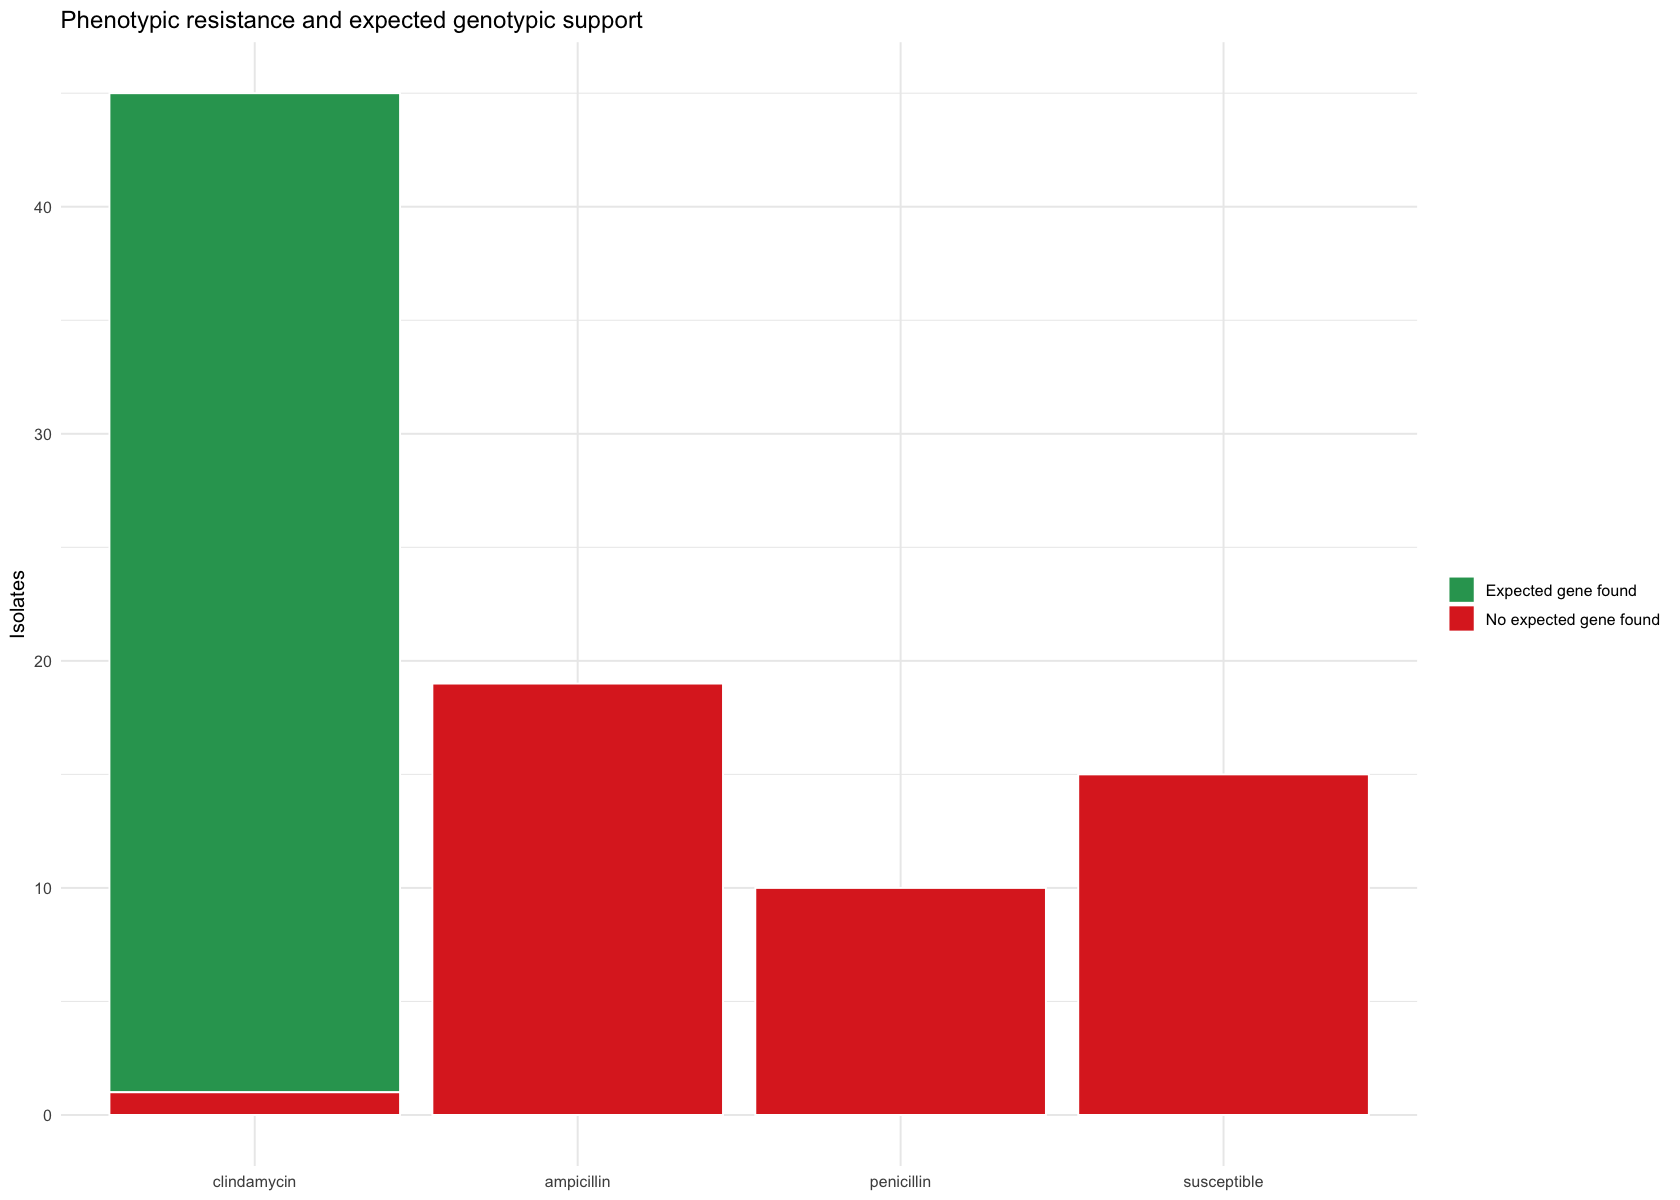

In [25]:
# Plot: resistant phenotype vs expected genotype
beta_concordance <- concordance_tbl |>
  mutate(
    expected_gene_status = if_else(has_expected_gene, "Expected gene found", "No expected gene found"),
    phenotype_class = factor(
      phenotype_class,
      levels = c("clindamycin", "ampicillin", "penicillin", "susceptible")
    )
  ) |>
  count(phenotype_class, expected_gene_status)

ggplot(beta_concordance, aes(x = phenotype_class, y = n, fill = expected_gene_status)) +
  geom_col(color = "white") +
  scale_fill_manual(values = c(
    "Expected gene found" = "#2ca25f",
    "No expected gene found" = "#de2d26"
  )) +
  labs(
    title = "Phenotypic resistance and expected genotypic support",
    x = NULL,
    y = "Isolates",
    fill = NULL
  ) +
  theme_minimal(base_size = 12)

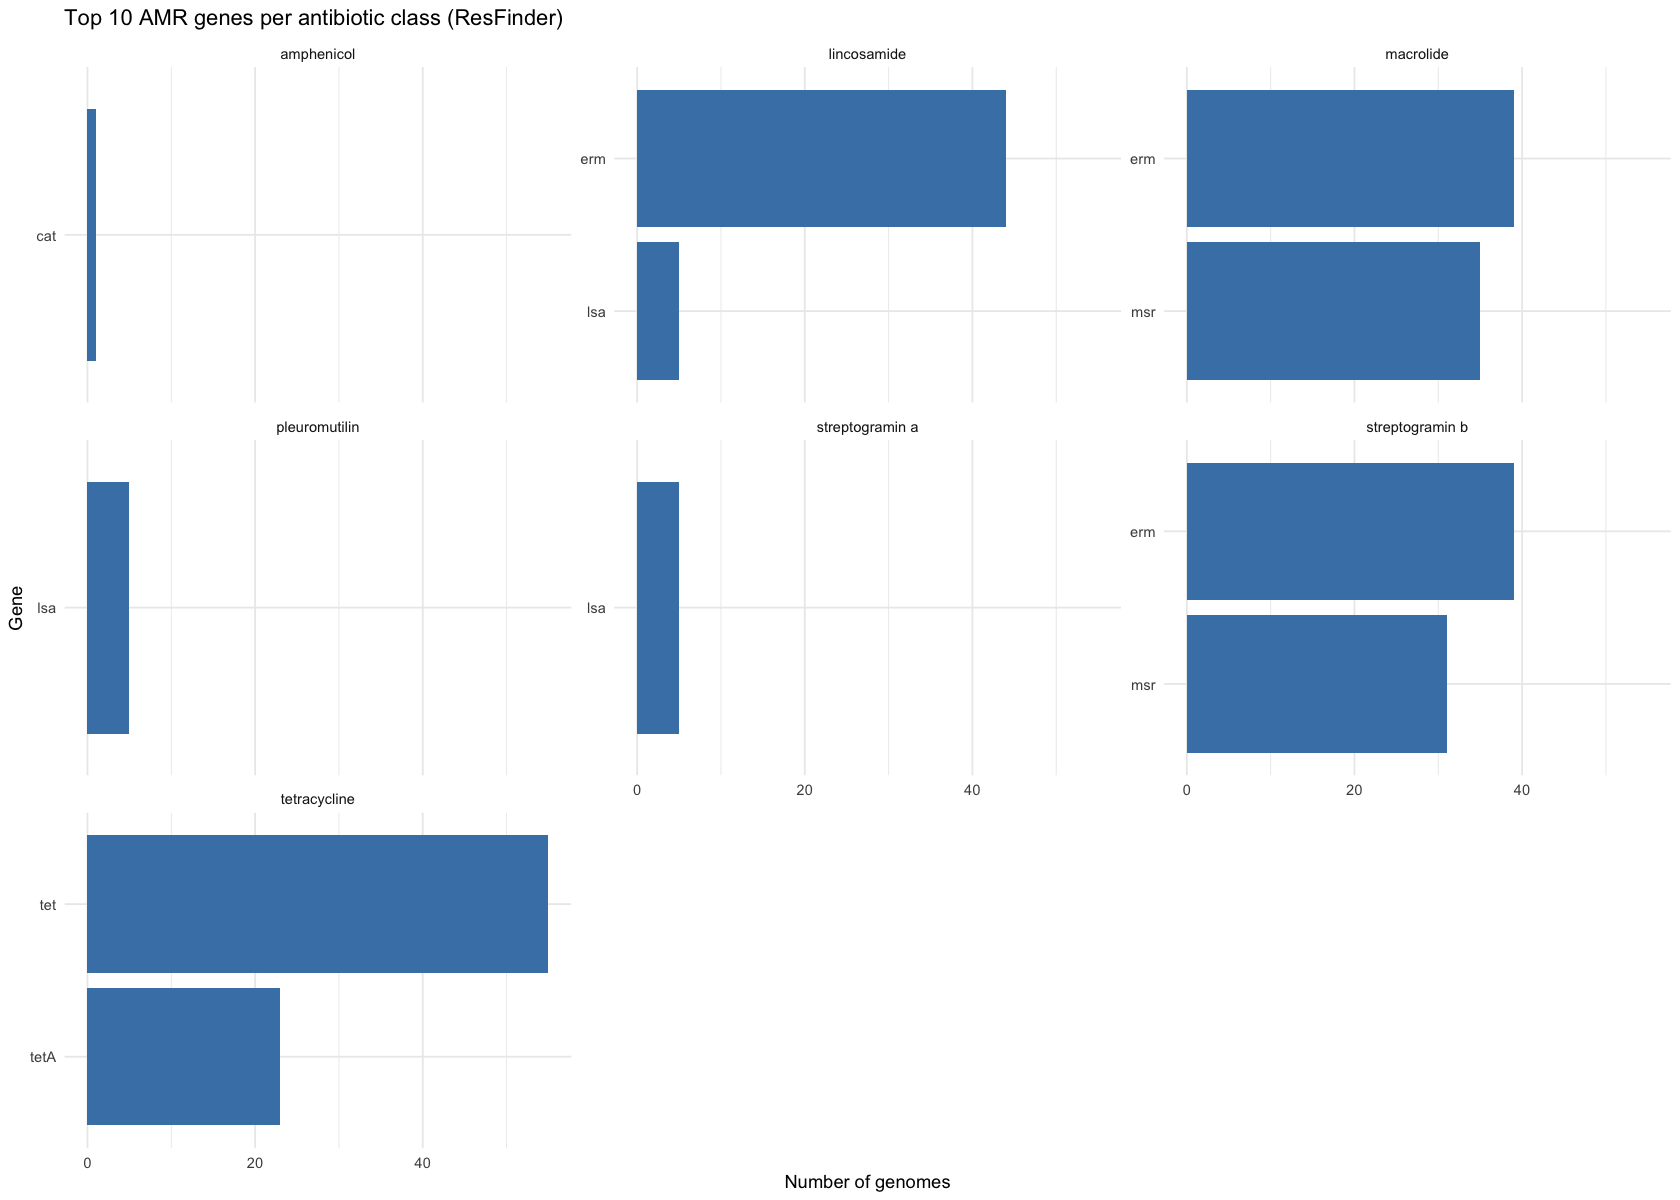

In [26]:
# Top AMR genes by antibiotic class (separate counts)

top_genes_separate <- pheno_resistant |>
  filter(!is.na(Genetic_background), Genetic_background != '') |>
  separate_rows(Genetic_background, sep = ',') |>
  mutate(gene = str_extract(Genetic_background, '^[^\\s(]+') |> str_trim()) |>
  filter(!is.na(gene), gene != '') |>
  distinct(Sample, Class, gene) |>
  count(gene, Class, name = 'n') |>
  group_by(Class) |>
  slice_max(n, n = 10) |>
  ungroup()

ggplot(top_genes_separate, aes(x = reorder(gene, n), y = n)) +
  geom_col(fill = 'steelblue') +
  coord_flip() +
  facet_wrap(~Class, scales = 'free_y') +
  labs(title = 'Top 10 AMR genes per antibiotic class (ResFinder)',
       x = 'Gene', 
       y = 'Number of genomes') +
  theme_minimal()

  #make the x axis fixed

In [27]:
# --- Gene-to-resistance summary table ---
gene_resistance_table <- amr_tbl |>
  mutate(
    gene = gene_family,
    resistance_class = gene_class
  ) |>
  distinct(sample_id, gene, resistance_class) |>
  count(gene, resistance_class, name = "n_isolates") |>
  arrange(resistance_class, desc(n_isolates), gene)

gene_resistance_table

# --- Ampicillin / penicillin only ---
beta_lactam_table <- concordance_tbl |>
  filter(phenotype_class %in% c("ampicillin", "penicillin")) |>
  summarise(
    n_resistant_isolates = n(),
    n_with_expected_gene = sum(has_expected_gene),
    n_without_expected_gene = sum(!has_expected_gene)
  )

beta_lactam_table

gene,resistance_class,n_isolates
<chr>,<chr>,<int>
erm,clindamycin,46
mef,clindamycin,35
msr,clindamycin,35


n_resistant_isolates,n_with_expected_gene,n_without_expected_gene
<int>,<int>,<int>
29,0,29


In [28]:

head(pheno_clean |> filter(WGS_phenotype != "No resistance"))

Sample,Antimicrobial,Class,WGS_phenotype,Match,Genetic_background
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
0043m-CMPN001x78_260114_LH00793_B23GCKKLT3,erythromycin,macrolide,Resistant,3,"msr(D) (msr(D)_AF274302), mef(A) (mef(A)_U83667)"
0043m-CMPN001x78_260114_LH00793_B23GCKKLT3,azithromycin,macrolide,Resistant,3,"msr(D) (msr(D)_AF274302), mef(A) (mef(A)_U83667)"
0043m-CMPN001x78_260114_LH00793_B23GCKKLT3,telithromycin,macrolide,Resistant,3,msr(D) (msr(D)_AF274302)
0043m-CMPN001x78_260114_LH00793_B23GCKKLT3,quinupristin,streptogramin b,Resistant,3,msr(D) (msr(D)_AF274302)
0043m-CMPN001x78_260114_LH00793_B23GCKKLT3,pristinamycin ia,streptogramin b,Resistant,3,msr(D) (msr(D)_AF274302)
0043m-CMPN001x78_260114_LH00793_B23GCKKLT3,virginiamycin s,streptogramin b,Resistant,3,msr(D) (msr(D)_AF274302)


In [29]:
# --- Gene -> antibiotics table ---
gene_antibiotic_table <- pheno_clean |>
  filter(WGS_phenotype == "Resistant") |>
  filter(!is.na(Genetic_background), Genetic_background != "") |>
  separate_rows(Genetic_background, sep = ",") |>
  mutate(
    gene = str_extract(Genetic_background, "^[^\\s]+") |> str_trim()
  ) |>
  filter(!is.na(gene), gene != "") |>
  distinct(Sample, Class, gene) |>
  group_by(gene) |>
  summarise(
    antibiotics = paste(sort(unique(Class)), collapse = ", "),
    n_antibiotics = n_distinct(Class),
    n_isolates = n_distinct(Sample),
    .groups = "drop"
  ) |>
  arrange(desc(n_isolates), gene)

gene_antibiotic_table

write_tsv(gene_antibiotic_table, "../results/amr/gene_antibiotic_table.tsv")

gene,antibiotics,n_antibiotics,n_isolates
<chr>,<chr>,<int>,<int>
tet(M),tetracycline,1,51
erm(B),"lincosamide, macrolide, streptogramin b",3,45
msr(D),"macrolide, streptogramin b",2,35
tetA(46),tetracycline,1,23
lsa(C),"lincosamide, pleuromutilin, streptogramin a",3,5
tet(O),tetracycline,1,2
cat(pC194),amphenicol,1,1
tet(32),tetracycline,1,1
tet(W),tetracycline,1,1


In [30]:
res_clean |> group_by(`Resistance gene`) |> count()

Resistance gene,n
<chr>,<int>
cat(pC194),1
erm(B),55
lsa(C),6
mef(A),35
msr(D),35
tet(32),1
tet(M),53
tet(O),2
tet(W),1


In [31]:
# MALDI-2 name counts per antibiotic, using Resistance 
maldi_antibiotic_counts <- df_filtered |>
  transmute(
    Sample = as.character(SAMPLE_ID),
    Maldi_2 = str_to_lower(str_trim(`Maldi species 2. test`)),
    antibiotic = str_to_lower(str_trim(str_remove(as.character(Resistance), "_resistant$")))
  ) |>
  filter(
    !is.na(Sample), Sample != "",
    !is.na(Maldi_2), Maldi_2 != "",
    !is.na(antibiotic), antibiotic != ""
  ) |>
  distinct(Sample, Maldi_2, antibiotic) |>
  count(antibiotic, Maldi_2, name = "n") |>
  arrange(antibiotic, desc(n), Maldi_2)

maldi_antibiotic_counts


antibiotic,Maldi_2,n
<chr>,<chr>,<int>
ampicillin,parasanguinis,12
ampicillin,salivarius,4
ampicillin,mitis oralis,2
ampicillin,vestibularis,1
clindamycin,mitis oralis,9
clindamycin,salivarius,7
clindamycin,vestibularis,7
clindamycin,anginosus,6
clindamycin,parasanguinis,6


In [32]:
colnames(df_filtered)

[1] "SAMPLE_ID"                                                                 
 [2] "GM_FILE_ID"                                                                
 [3] "Number_contigs_genome"                                                     
 [4] "Genome_size"                                                               
 [5] "Species_GTDB_release207_ANIpercent"                                        
 [6] "Abricate_resfinder-v2019-09-10_genes_coverage_lt_60perc_identity_lt_90perc"
 [7] "Resistance"                                                                
 [8] "Maldi species 2. test"                                                     
 [9] "Zone diameter"                                                             
[10] "species_214"

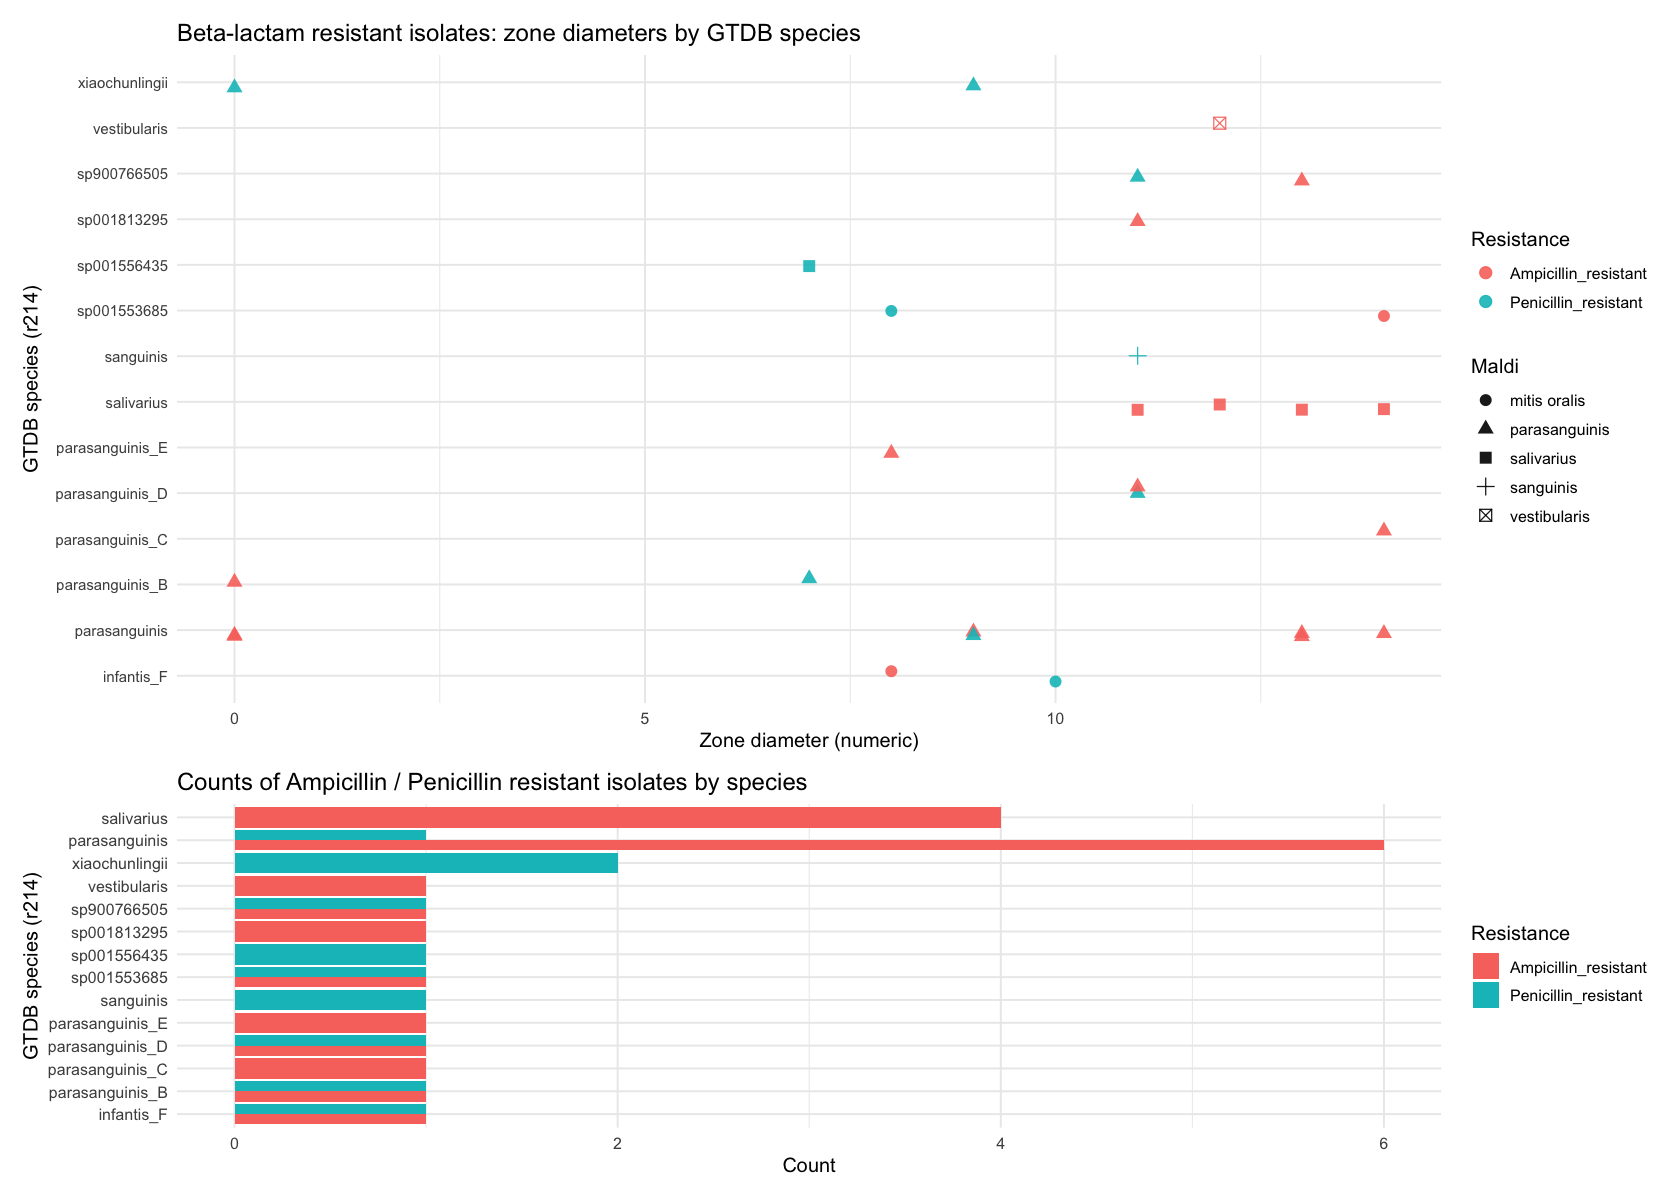

In [33]:
betalactam_resistant <- df_filtered |>
    filter(Resistance == "Ampicillin_resistant" | Resistance == "Penicillin_resistant") |>
    select(SAMPLE_ID, Resistance, `Maldi species 2. test`, species_214, `Zone diameter`)

betalactam_resistant2 <- betalactam_resistant %>%
  transmute(
    SAMPLE_ID = as.character(SAMPLE_ID),
    Resistance = factor(Resistance, levels = c("Ampicillin_resistant", "Penicillin_resistant")),
    Maldi = str_to_lower(str_trim(`Maldi species 2. test`)),
    GTDB = str_trim(species_214),
    zone_num = parse_number(str_replace_all(as.character(`Zone diameter`), "[Rr]", ""))
  )

p_zone <- betalactam_resistant2 %>%
  ggplot(aes(x = GTDB, y = zone_num, colour = Resistance, shape = Maldi)) +
  geom_jitter(width = 0.18, height = 0, size = 3, alpha = 0.9) +
  coord_flip() +
  labs(x = "GTDB species (r214)", y = "Zone diameter (numeric)", title = "Beta-lactam resistant isolates: zone diameters by GTDB species") +
  theme_minimal(base_size = 12) +
  theme(axis.text.y = element_text(size = 9))

p_counts <- betalactam_resistant2 %>%
  count(GTDB, Resistance) %>%
  ggplot(aes(x = reorder(GTDB, n), y = n, fill = Resistance)) +
  geom_col(position = "dodge") +
  coord_flip() +
  labs(x = "GTDB species (r214)", y = "Count", title = "Counts of Ampicillin / Penicillin resistant isolates by species") +
  theme_minimal(base_size = 12)


(p_zone / p_counts) + plot_layout(heights = c(2, 1))

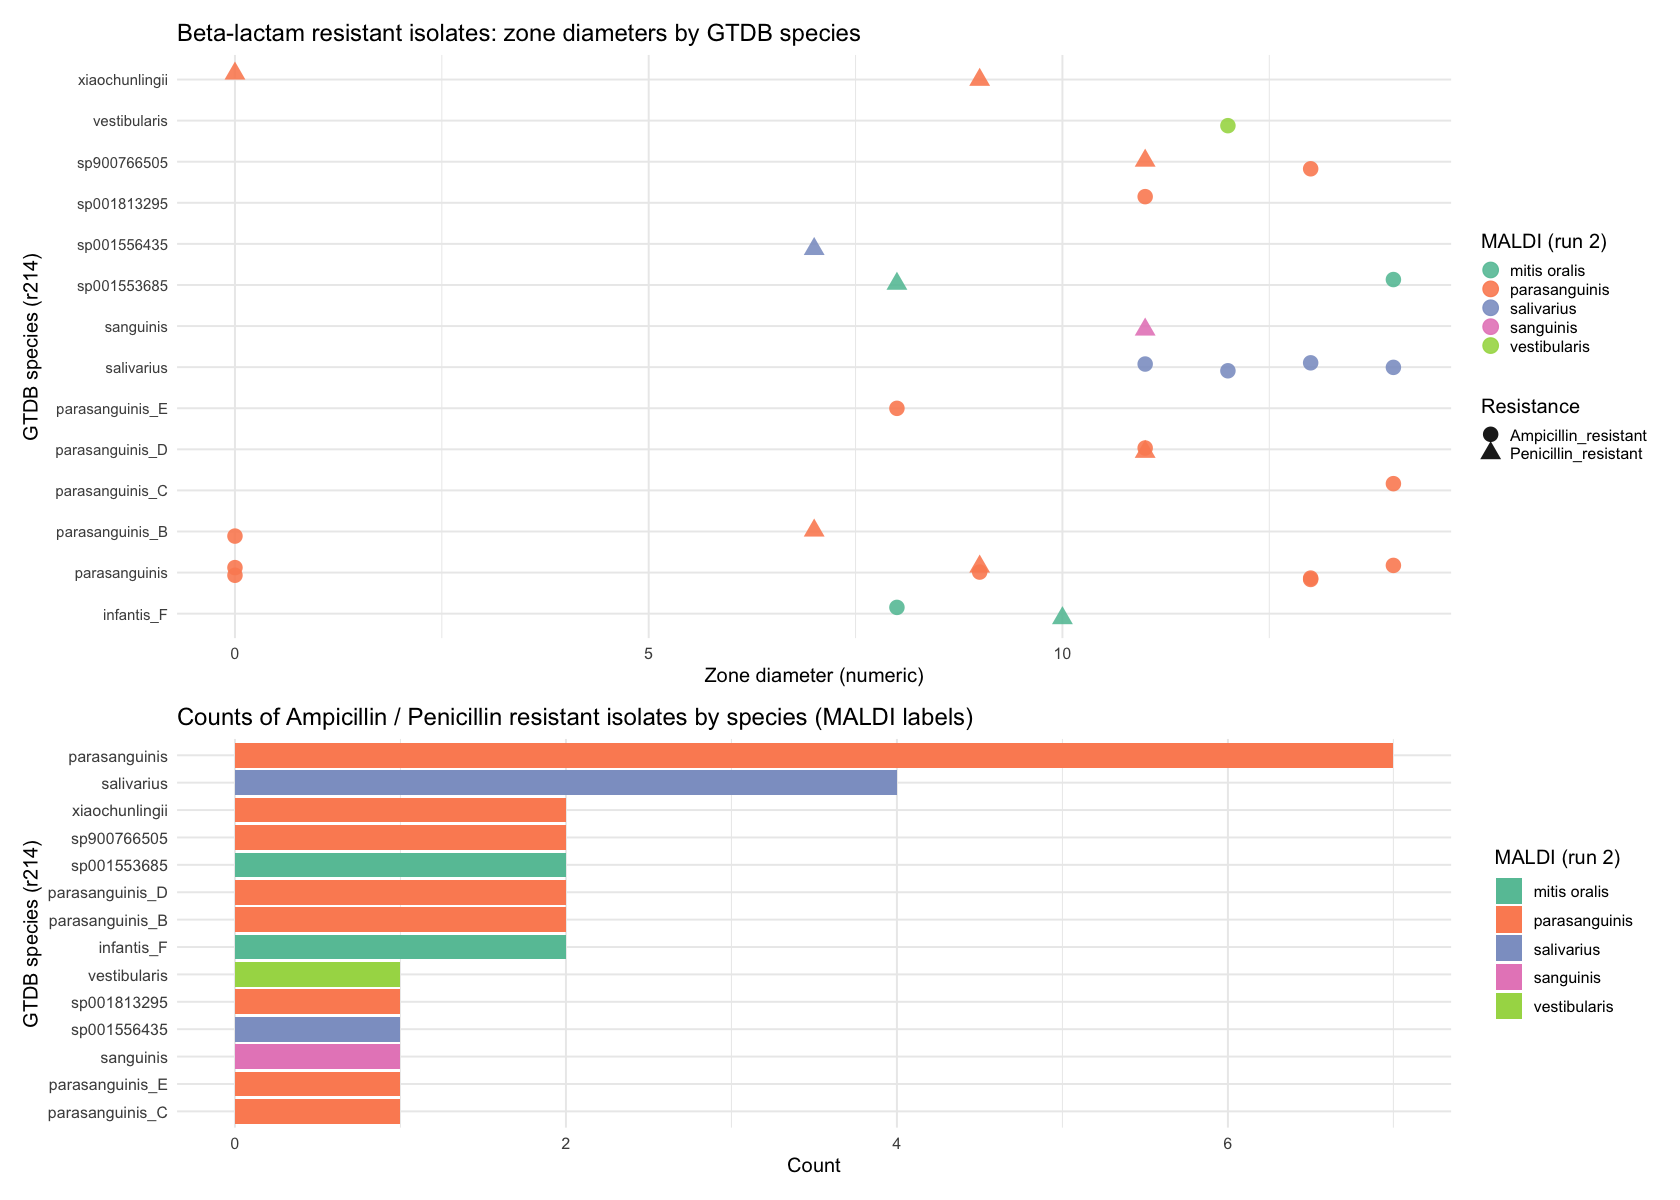

In [34]:
# ...existing code...
betalactam_resistant <- df_filtered |>
    filter(Resistance == "Ampicillin_resistant" | Resistance == "Penicillin_resistant") |>
    select(SAMPLE_ID, Resistance, `Maldi species 2. test`, species_214, `Zone diameter`)

betalactam_resistant2 <- betalactam_resistant %>%
  transmute(
    SAMPLE_ID = as.character(SAMPLE_ID),
    Resistance = factor(Resistance, levels = c("Ampicillin_resistant", "Penicillin_resistant")),
    Maldi = str_to_lower(str_trim(`Maldi species 2. test`)),
    GTDB = str_trim(species_214),
    zone_num = parse_number(str_replace_all(as.character(`Zone diameter`), "[Rr]", ""))
  )

# build a palette for the MALDI labels present in this subset
maldi_levels <- betalactam_resistant2 %>%
  pull(Maldi) %>%
  unique() %>%
  na.omit() %>%
  as.character() %>%
  sort()

n_maldi <- length(maldi_levels)
if (n_maldi == 0) {
  maldi_palette <- character(0)
} else if (n_maldi <= 8) {
  pal_vals <- RColorBrewer::brewer.pal(max(3, n_maldi), "Set2")[1:n_maldi]
  maldi_palette <- setNames(pal_vals, maldi_levels)
} else {
  pal_vals <- colorRampPalette(RColorBrewer::brewer.pal(8, "Set2"))(n_maldi)
  maldi_palette <- setNames(pal_vals, maldi_levels)
}

# treat Maldi as factor with explicit levels
betalactam_resistant2 <- betalactam_resistant2 %>%
  mutate(Maldi = factor(Maldi, levels = maldi_levels))

p_zone <- betalactam_resistant2 %>%
  ggplot(aes(x = GTDB, y = zone_num, colour = Maldi, shape = Resistance)) +
  geom_jitter(width = 0.18, height = 0, size = 4, alpha = 0.9, na.rm = TRUE) +
  coord_flip() +
  scale_colour_manual("MALDI (run 2)", values = maldi_palette, na.value = "grey60") +
  scale_shape_manual("Resistance", values = c("Ampicillin_resistant" = 16, "Penicillin_resistant" = 17)) +
  labs(x = "GTDB species (r214)", y = "Zone diameter (numeric)",
       title = "Beta-lactam resistant isolates: zone diameters by GTDB species") +
  theme_minimal(base_size = 12) +
  theme(axis.text.y = element_text(size = 9),
        legend.position = "right",
        legend.key.size = grid::unit(0.6, "lines"))

p_counts <- betalactam_resistant2 %>%
  count(GTDB, Maldi) %>%
  ggplot(aes(x = reorder(GTDB, n), y = n, fill = Maldi)) +
  geom_col() +
  coord_flip() +
  scale_fill_manual("MALDI (run 2)", values = maldi_palette, na.value = "grey60") +
  labs(x = "GTDB species (r214)", y = "Count", title = "Counts of Ampicillin / Penicillin resistant isolates by species (MALDI labels)") +
  theme_minimal(base_size = 12)
  
(p_zone / p_counts) + plot_layout(heights = c(1.5, 1))
# ...existing code...

In [35]:
df_filtered |>
    filter(Resistance == "Penicillin_resistant" & `Zone diameter` == "R0") 

df_filtered |>
    filter(Resistance == "Ampicillin_resistant" & `Zone diameter` == "R0") 


SAMPLE_ID,GM_FILE_ID,Number_contigs_genome,Genome_size,Species_GTDB_release207_ANIpercent,Abricate_resfinder-v2019-09-10_genes_coverage_lt_60perc_identity_lt_90perc,Resistance,Maldi species 2. test,Zone diameter,species_214
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
146Pp,146Pp-CMPN001x69_260114_LH00793_B23GCKKLT3,22,2005923,Streptococcus xiaochunlingii (96.4%),"mef(A)_2,msr(D)_2,tet(M)_4,tetA(46)_1,tetB(46)_1",Penicillin_resistant,Parasanguinis,R0,xiaochunlingii


SAMPLE_ID,GM_FILE_ID,Number_contigs_genome,Genome_size,Species_GTDB_release207_ANIpercent,Abricate_resfinder-v2019-09-10_genes_coverage_lt_60perc_identity_lt_90perc,Resistance,Maldi species 2. test,Zone diameter,species_214
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
111Ap,111Ap-CMPN001x58_260114_LH00793_B23GCKKLT3,62,2137179,Streptococcus parasanguinis (96.9%),"mef(A)_2,msr(D)_2,tetA(46)_1,tetB(46)_1",Ampicillin_resistant,Parasanguinis,R0,parasanguinis
113Ap,113Ap-CMPN001x59_260114_LH00793_B23GCKKLT3,39,2158545,Streptococcus parasanguinisxB (95.6%),"mef(A)_2,msr(D)_2,tetA(46)_1,tetB(46)_1",Ampicillin_resistant,Parasanguinis,R0,parasanguinis_B
124Ap,124Ap-CMPN001x61_260114_LH00793_B23GCKKLT3,109,2151668,Streptococcus parasanguinis (96.7%),"mef(A)_2,msr(D)_2,tetA(46)_1,tetB(46)_1",Ampicillin_resistant,Parasanguinis,R0,parasanguinis


### Zoom-in on the susceptible isolates

43m
48m
52a
59s
68g
68m
71v
76m
84v
93s
106g
106s
116p
116s
129a
129p



##### MDR

mdr_category,n,percent,percent_label
<chr>,<int>,<dbl>,<chr>
MDR (≥3 classes),65,73.033708,73.0%
Susceptible,13,14.606742,14.6%
Two classes,6,6.741573,6.7%
Single class,5,5.617978,5.6%


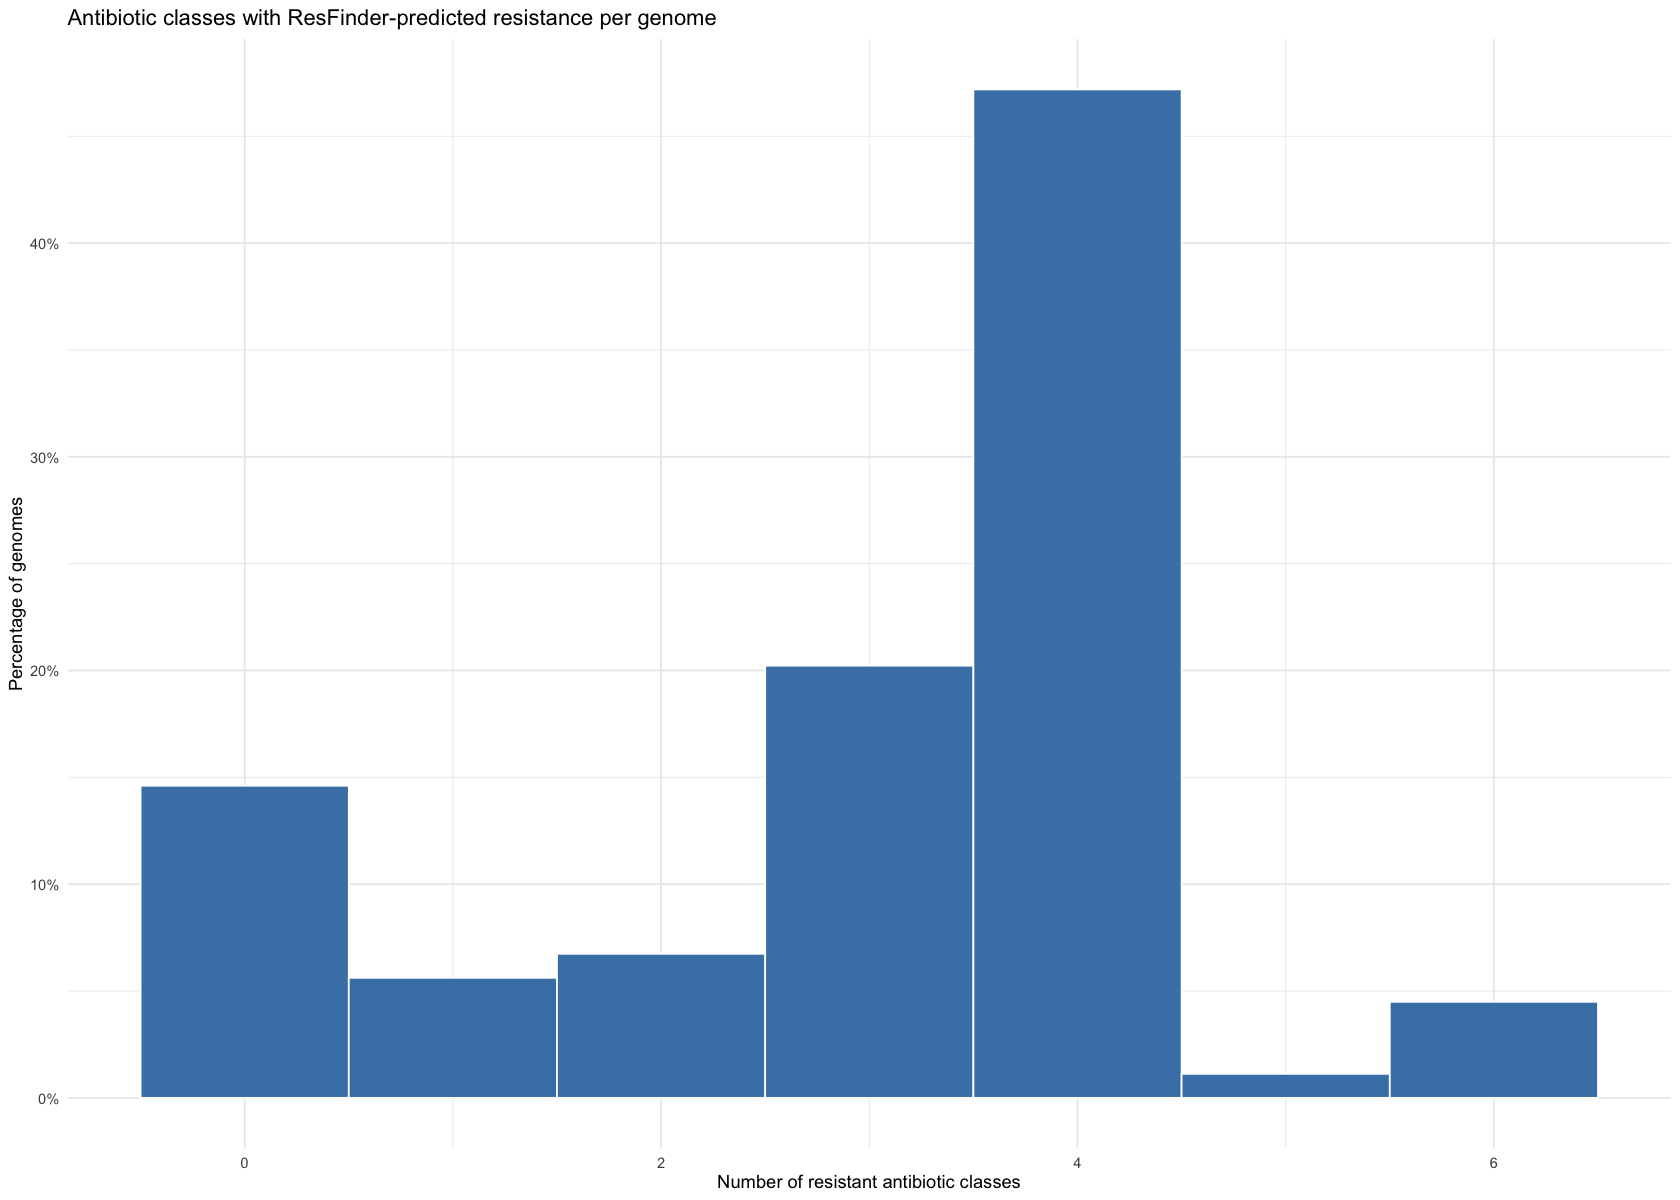

In [36]:
mdr <- pheno_clean |>
  filter(WGS_phenotype == 'Resistant') |>
  distinct(Sample, Class) |>
  count(Sample, name = 'n_resistant_classes') |>
  mutate(mdr_category = case_when(
    n_resistant_classes == 1 ~ 'Single class',
    n_resistant_classes == 2 ~ 'Two classes',
    n_resistant_classes >= 3 ~ 'MDR (≥3 classes)'
  ))

no_res <- tibble(Sample = setdiff(valid_ids, mdr$Sample),
                 n_resistant_classes = 0, mdr_category = 'Susceptible')
mdr_full <- bind_rows(mdr, no_res)

# counts + percentages by MDR category
mdr_summary <- mdr_full |>
  count(mdr_category) |>
  mutate(
    percent = 100 * n / sum(n),
    percent_label = sprintf("%.1f%%", percent)
  ) |>
  arrange(desc(n))

mdr_summary

# histogram shown as percentages of all genomes
mdr_full |>
  ggplot(aes(x = n_resistant_classes, y = after_stat(count / sum(count)))) +
  geom_histogram(binwidth = 1, fill = "steelblue", color = "white") +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  labs(
    title = "Antibiotic classes with ResFinder-predicted resistance per genome",
    x = "Number of resistant antibiotic classes",
    y = "Percentage of genomes"
  ) +
  theme_minimal()

In [37]:


class_counts_exact <- mdr_full |>
  count(n_resistant_classes) |>
  arrange(n_resistant_classes) |>
  rename(n_samples = n_resistant_classes)

class_counts_exact

n_samples,n
<dbl>,<int>
0,13
1,5
2,6
3,18
4,42
5,1
6,4


In [38]:
susceptible_ids <- df_filtered |> filter(is.na(Resistance)) |> pull(GM_FILE_ID)
pheno_res_ids <- df_filtered |> filter(!is.na(Resistance)) |> pull(GM_FILE_ID)
length(pheno_res_ids)

[1] 74

In [39]:
susceptible_ids

[1] "0043m-CMPN001x78_260114_LH00793_B23GCKKLT3"
 [2] "0048m-CMPN001x79_260114_LH00793_B23GCKKLT3"
 [3] "0052a-CMPN001x80_260114_LH00793_B23GCKKLT3"
 [4] "0059s-CMPN001x81_260114_LH00793_B23GCKKLT3"
 [5] "0068g-CMPN001x82_260114_LH00793_B23GCKKLT3"
 [6] "0068m-CMPN001x83_260114_LH00793_B23GCKKLT3"
 [7] "0071v-CMPN001x84_260114_LH00793_B23GCKKLT3"
 [8] "0076m-CMPN001x85_260114_LH00793_B23GCKKLT3"
 [9] "0084v-CMPN001x87_260114_LH00793_B23GCKKLT3"
[10] "0093s-CMPN001x88_260114_LH00793_B23GCKKLT3"
[11] "0106g-CMPN001x89_260114_LH00793_B23GCKKLT3"
[12] "0116p-CMPN001x93_260114_LH00793_B23GCKKLT3"
[13] "0129a-CMPN001x94_260114_LH00793_B23GCKKLT3"
[14] "0129p-CMPN001x95_260114_LH00793_B23GCKKLT3"
[15] "116mi-CMPN001x92_260114_LH00793_B23GCKKLT3"

In [40]:
amr_clean |> filter(sample %in% susceptible_ids) |> select(sample, element_symbol, element_name) 
# 7 out of 15 were found to have resistance genes

length(sus_with_amr)

res_ids <- amr_clean |> select(sample) |> unique() |> pull()

# Exact ID comparison
amr_ids <- amr_clean |> distinct(sample) |> pull(sample)

missing_in_amr <- setdiff(pheno_res_ids, amr_ids)
missing_in_amr
length(missing_in_amr)


sample,element_symbol,element_name
<chr>,<chr>,<chr>
0043m-CMPN001x78_260114_LH00793_B23GCKKLT3,msr(D),ABC-F type ribosomal protection protein Msr(D)
0043m-CMPN001x78_260114_LH00793_B23GCKKLT3,mef(A),macrolide efflux MFS transporter Mef(A)
0048m-CMPN001x79_260114_LH00793_B23GCKKLT3,mef(A),macrolide efflux MFS transporter Mef(A)
0048m-CMPN001x79_260114_LH00793_B23GCKKLT3,msr(D),ABC-F type ribosomal protection protein Msr(D)
0068m-CMPN001x83_260114_LH00793_B23GCKKLT3,tet(M),tetracycline resistance ribosomal protection protein Tet(M)
0068m-CMPN001x83_260114_LH00793_B23GCKKLT3,msr(D),ABC-F type ribosomal protection protein Msr(D)
0068m-CMPN001x83_260114_LH00793_B23GCKKLT3,mef(A),macrolide efflux MFS transporter Mef(A)
0076m-CMPN001x85_260114_LH00793_B23GCKKLT3,msr(D),ABC-F type ribosomal protection protein Msr(D)
0076m-CMPN001x85_260114_LH00793_B23GCKKLT3,mef(A),macrolide efflux MFS transporter Mef(A)


ERROR: Error: object 'sus_with_amr' not found


12 were found not to have resistance genes - 5 had pheno resistance towards ampicilin or penicilin and 7 were actually susceptible

In [ ]:
# --- Gene grouping among MDR isolates: simpler version ---

mdr_samples <- mdr_full |>
  filter(mdr_category == "MDR (≥3 classes)") |>
  pull(Sample) |>
  as.character()

mdr_genes <- amr_clean |>
  filter(sample %in% mdr_samples, !is.na(element_symbol), element_symbol != "") |>
  transmute(
    sample_id = as.character(sample),
    gene = str_trim(element_symbol)
  ) |>
  distinct(sample_id, gene)

gene_mat <- mdr_genes |>
  mutate(present = 1L) |>
  pivot_wider(names_from = gene, values_from = present, values_fill = 0L) |>
  column_to_rownames("sample_id") |>
  as.matrix()

# keep genes seen in at least 2 MDR isolates
gene_mat <- gene_mat[, colSums(gene_mat) >= 2, drop = FALSE]

# cluster genes by co-occurrence pattern
gene_dist <- dist(t(gene_mat), method = "binary")  # Jaccard-like distance
gene_hc <- hclust(gene_dist, method = "average")

# assign groups
gene_groups <- cutree(gene_hc, k = 4)

gene_group_table <- tibble(
  gene = names(gene_groups),
  cluster = gene_groups
) |>
  arrange(cluster, gene)


# compact summary table
gene_group_summary <- gene_group_table |>
  group_by(cluster) |>
  summarise(
    n_genes = n(),
    genes = paste(gene, collapse = ", "),
    .groups = "drop"
  )

gene_group_table
gene_group_summary



gene,cluster
<chr>,<int>
erm(B),1
tet(M),1
mef(A),2
msr(D),2
tetA(46),2
tetB(46),2
tet(O),3
lsa(C),4


cluster,n_genes,genes
<int>,<int>,<chr>
1,2,"erm(B), tet(M)"
2,4,"mef(A), msr(D), tetA(46), tetB(46)"
3,1,tet(O)
4,1,lsa(C)


##### AMR finder & ResFinder: presence / absence heatmap

NOTE: GDTB sometimes assigns a alphabetical suffix -xA (ex. parasanguinisxC) or similar, which represent a genomic cluster, for which the formal species assignment is not yet resolved, but is best represented by the given species assignment, which may change in the future releases. source: https://gtdb.ecogenomic.org/faq



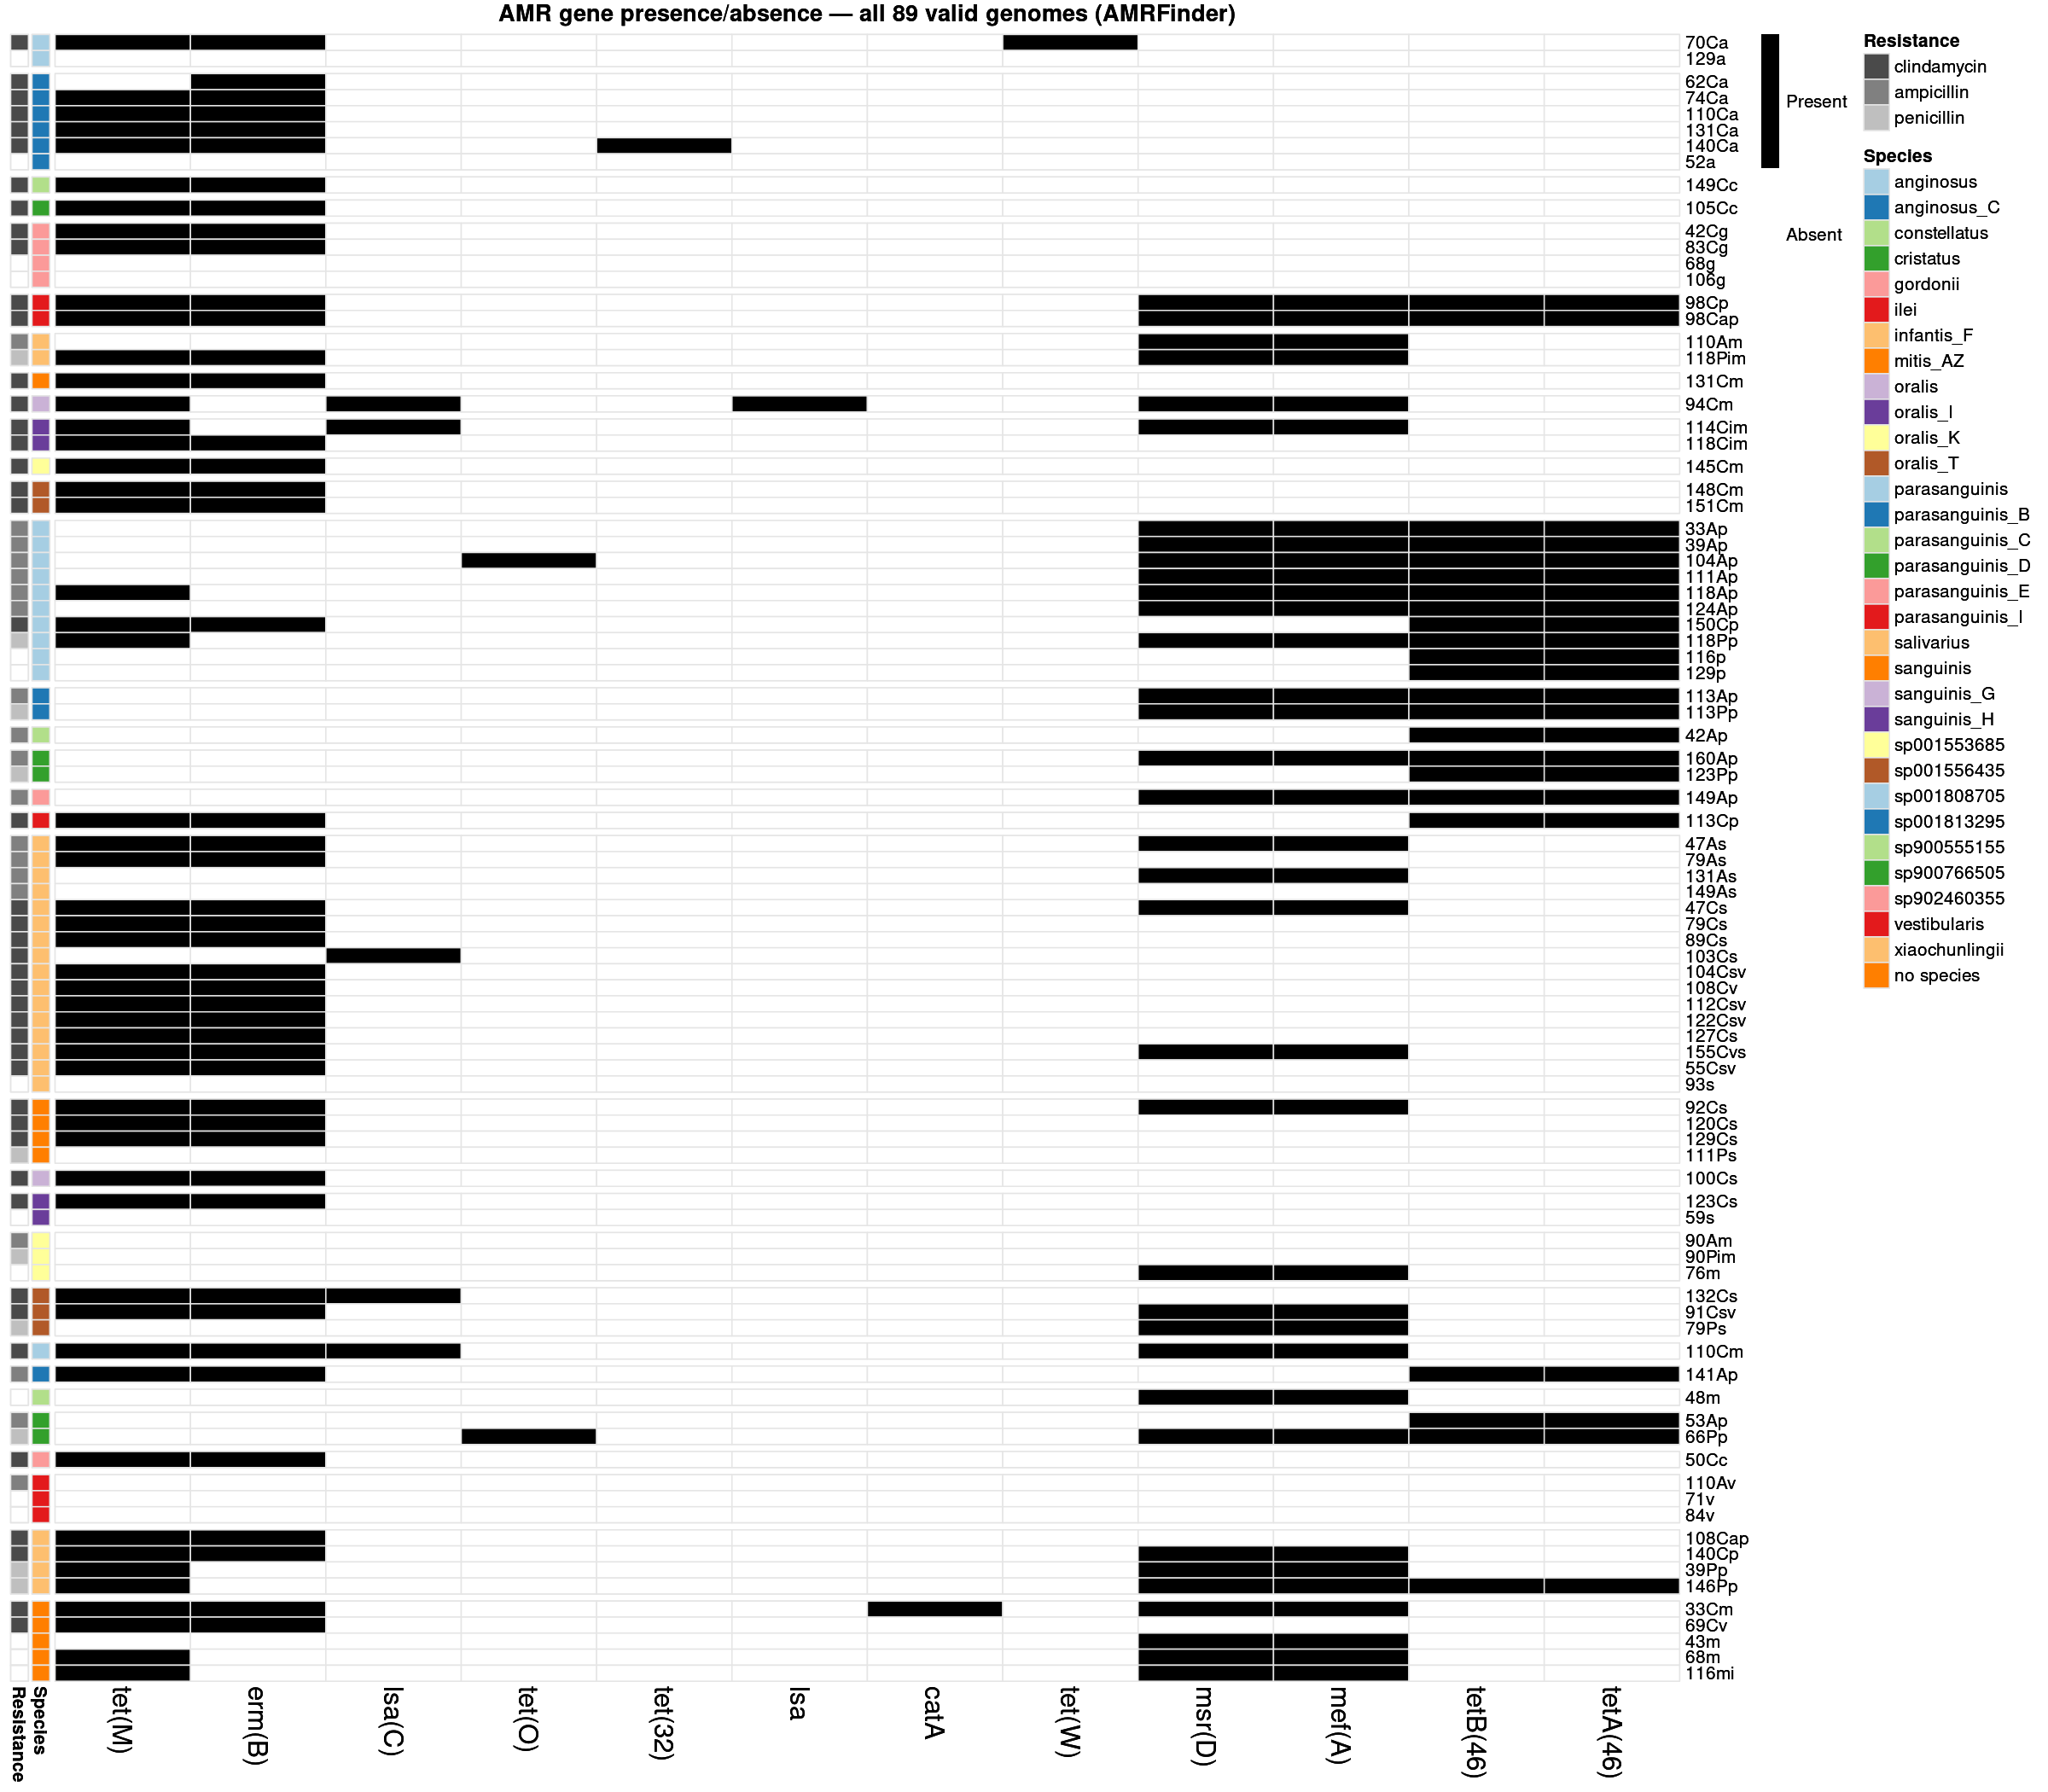

In [ ]:
options(repr.plot.width = 14, repr.plot.height = 10)

# annotation: SAMPLE_ID, Species, Resistance
annot <- species_df |>
  select(SAMPLE_ID, GTDB_214) |>
  left_join(df_filtered |> select(SAMPLE_ID, Resistance), by = "SAMPLE_ID") |>
  rename(Species = GTDB_214) |>
  distinct(SAMPLE_ID, .keep_all = TRUE)

all_sample_ids <- annot$SAMPLE_ID

# presence/absence matrix (AMRFinder) - keep all 89 samples
pa_data_amr <- amr_clean |>
  filter(!is.na(element_symbol)) |>
  mutate(sample_short = sub("-.*", "", sample) |> sub("^0+", "", x = _)) |>
  distinct(sample_short, element_symbol) |>
  mutate(present = 1L) |>
  pivot_wider(names_from = element_symbol, values_from = present, values_fill = 0L)

pa_data_amr <- tibble(sample_short = all_sample_ids) |>
  left_join(pa_data_amr, by = "sample_short") |>
  mutate(across(-sample_short, ~replace_na(as.integer(.x), 0L)))

pa_mat_amr <- pa_data_amr |>
  column_to_rownames("sample_short") |>
  as.matrix()


# sort annotation 
annot_sorted_amr <- annot |>
  filter(SAMPLE_ID %in% rownames(pa_mat_amr)) |>
  arrange(
    Species == "no species",  # no species last
    Species,
    Resistance
  ) |>
  column_to_rownames("SAMPLE_ID")

sorted_order_amr <- rownames(annot_sorted_amr)          # character vector 
pa_mat_amr <- pa_mat_amr[sorted_order_amr, , drop = FALSE]  # reorder matrix to match

# gaps between species groups 
gaps <- which(diff(as.numeric(factor(annot_sorted_amr$Species, 
                                     levels = unique(annot_sorted_amr$Species)))) != 0)

# clean resistance labels
annot_sorted_clean_amr <- annot_sorted_amr |>
  mutate(Resistance = str_remove(Resistance, "_resistant") |> str_to_lower())
 
species_names <- unique(annot_sorted_clean_amr$Species)

paired_cols <- RColorBrewer::brewer.pal(12, "Paired")
all_cols <- rep(paired_cols, length.out = length(species_names))
species_cols <- setNames(all_cols, species_names)

resist_cols <- c(
  "clindamycin" = "#4A4A4A",
  "ampicillin"  = "#808080",
  "penicillin"  = "#BFBFBF"
)

ann_colors <- list(
  Species    = species_cols,
  Resistance = resist_cols
)

options(repr.plot.width = 16, repr.plot.height = 14, repr.plot.res = 150)

amr_plot <- pheatmap(pa_mat_amr,
  annotation_row    = annot_sorted_clean_amr,
  annotation_colors = ann_colors,
  color             = c('white', 'black'),
  breaks            = c(-0.5, 0.5, 1.5),
  border_color      = 'grey90',
  fontsize_row      = 10,
  fontsize_col      = 15,
  cluster_rows      = FALSE,
  cluster_cols      = TRUE,
  treeheight_col    = 0,
  gaps_row          = gaps,
  legend_breaks     = c(0, 1),
  legend_labels     = c('Absent', 'Present'),
  main              = 'AMR gene presence/absence — all 89 valid genomes (AMRFinder)')

amr_plot

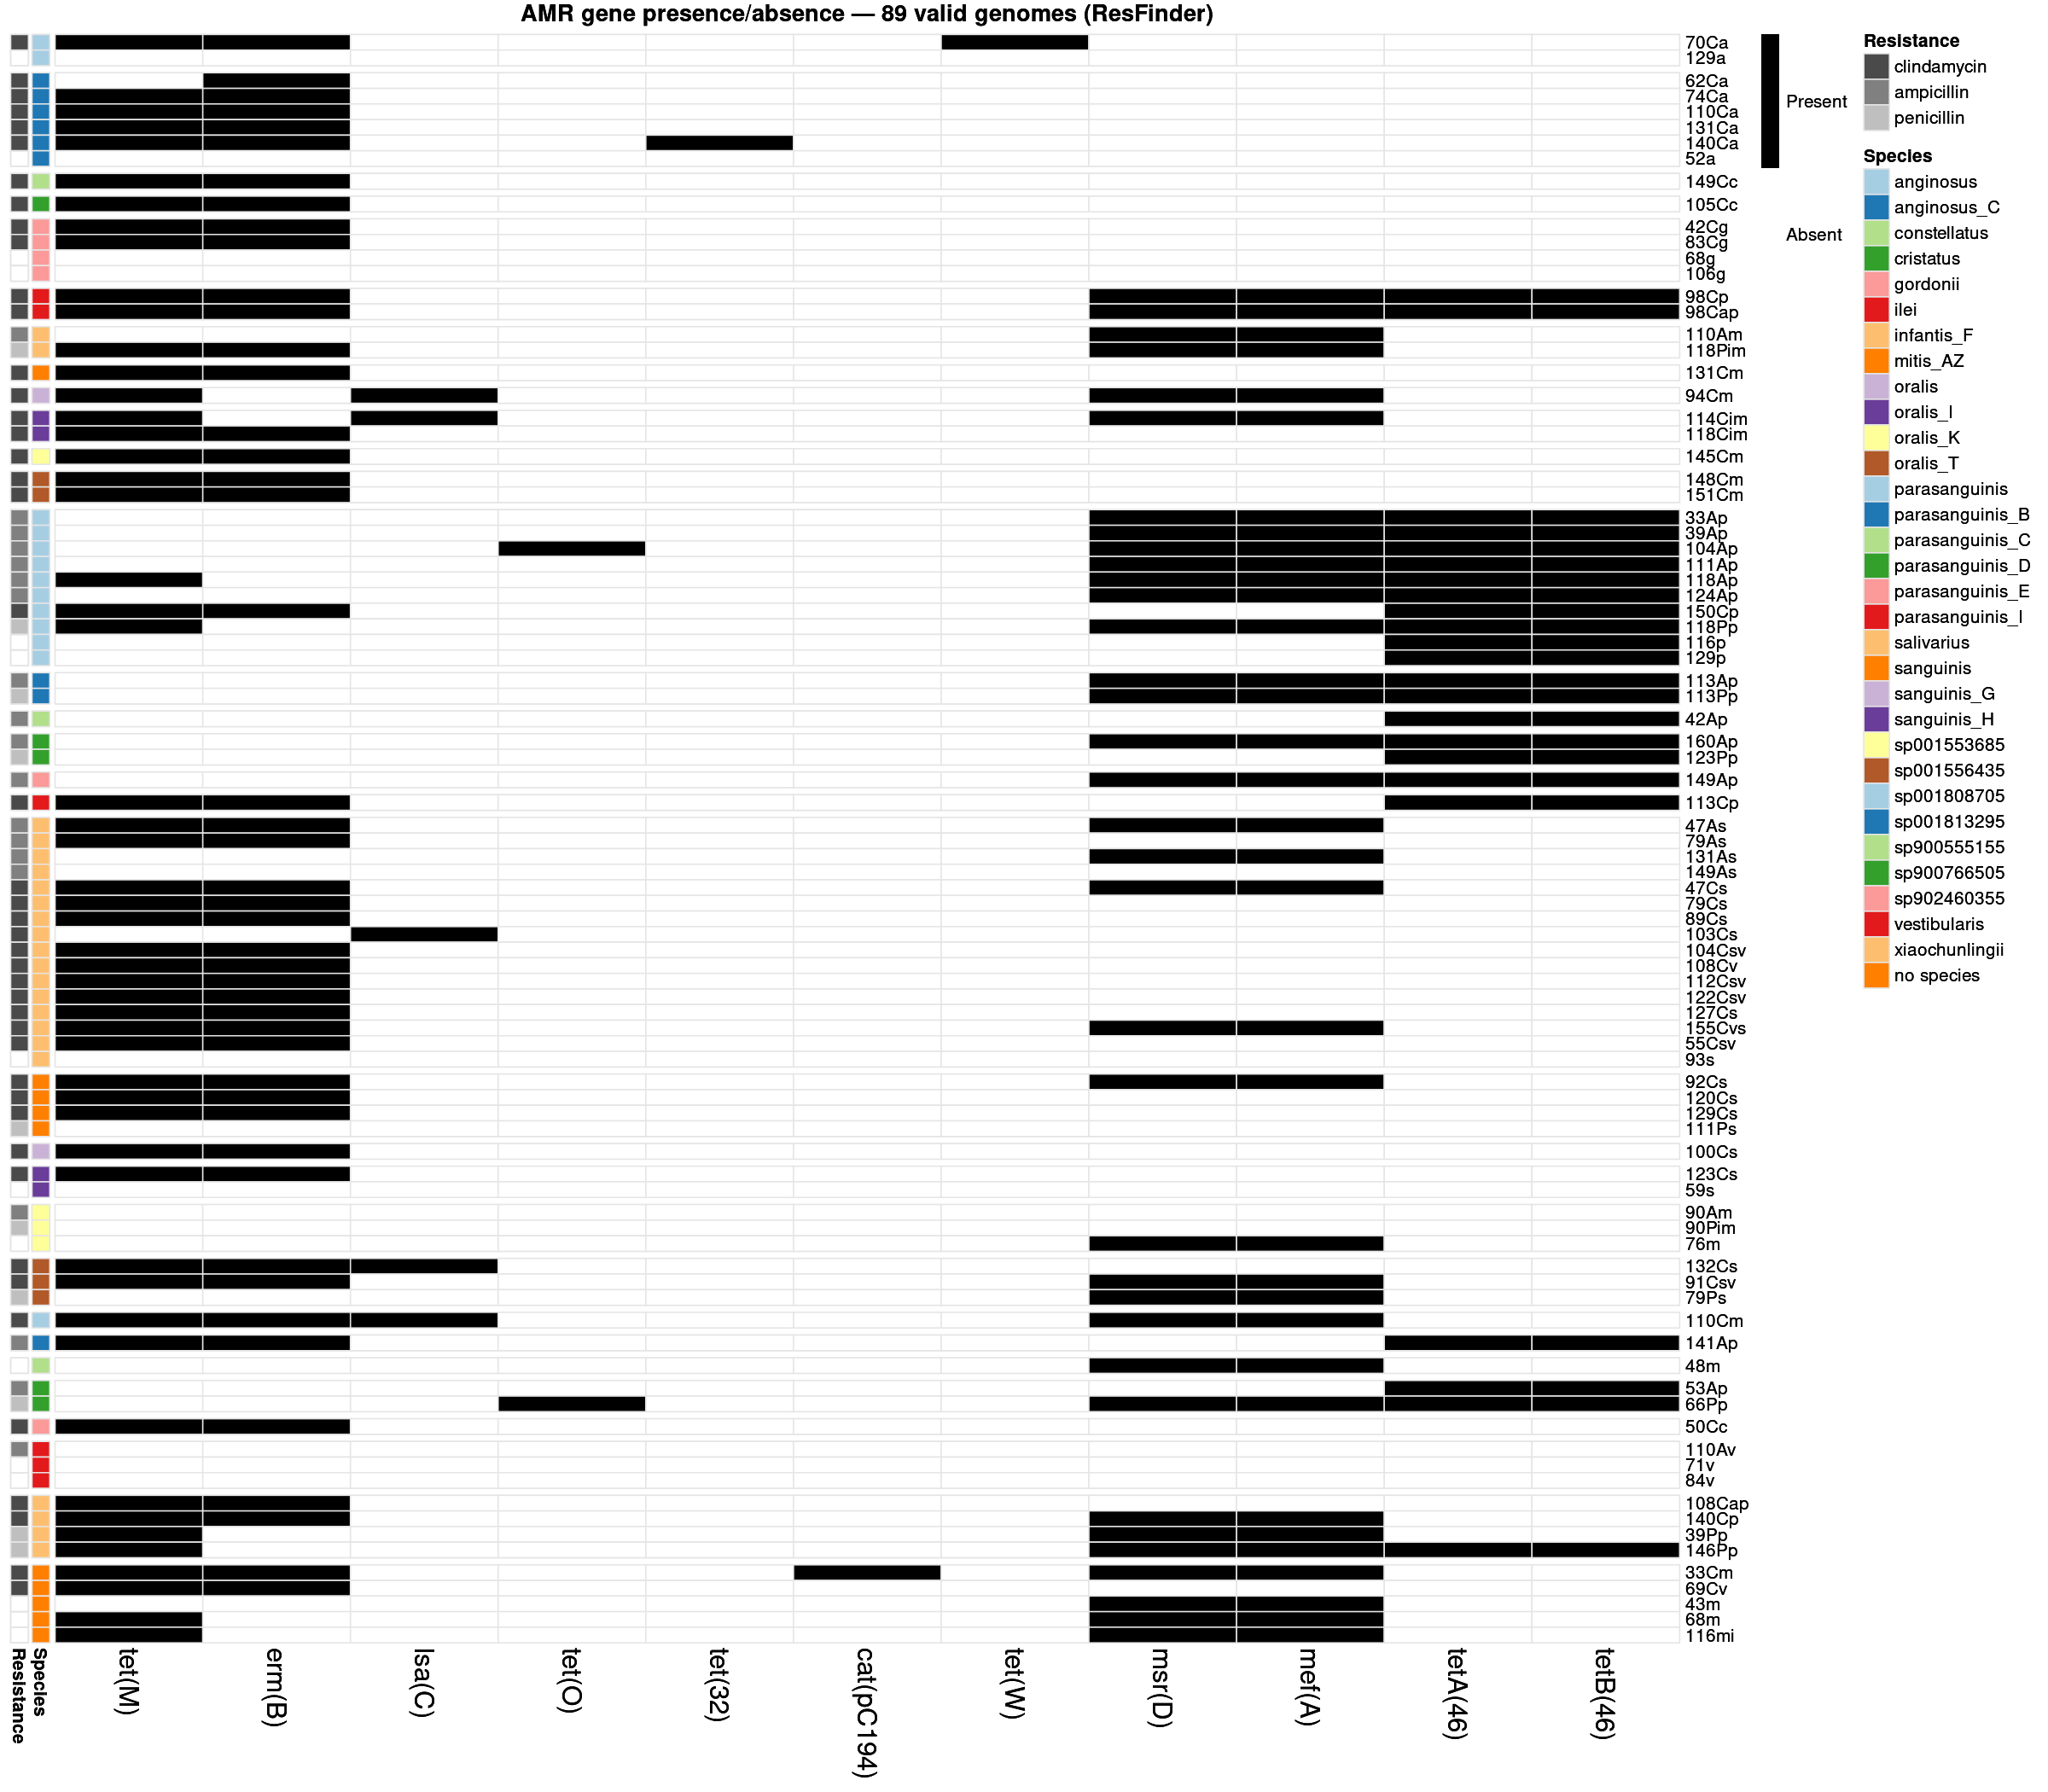

In [ ]:


# presence/absence matrix
pa_data_res <- res_clean |>
  filter(!is.na(`Resistance gene`)) |>
  mutate(sample_short = sub("-.*", "", Sample) |> sub("^0+", "", x = _)) |>
  distinct(sample_short, `Resistance gene`) |>
  mutate(present = 1L) |>
  pivot_wider(names_from = `Resistance gene`, values_from = present, values_fill = 0L)

pa_data_res <- tibble(sample_short = all_sample_ids) |>
  left_join(pa_data_res, by = "sample_short") |>
  mutate(across(-sample_short, ~replace_na(as.integer(.x), 0L)))

pa_mat_res <- pa_data_res |>
  column_to_rownames("sample_short") |>
  as.matrix()
pa_mat_res <- pa_mat_res[sorted_order_amr, , drop = FALSE]  #sort like amr

res_plot <- pheatmap(pa_mat_res,
  annotation_row    = annot_sorted_clean_amr,
  annotation_colors = ann_colors,
  color             = c('white', 'black'),
  breaks            = c(-0.5, 0.5, 1.5),
  border_color      = 'grey90',
  fontsize_row      = 10,
  fontsize_col      = 15,
  cluster_rows      = FALSE,
  cluster_cols      = TRUE,
  treeheight_col    = 0,
  gaps_row          = gaps,
  legend_breaks     = c(0, 1),
  legend_labels     = c('Absent', 'Present'),
  main              = 'AMR gene presence/absence — 89 valid genomes (ResFinder)')

res_plot

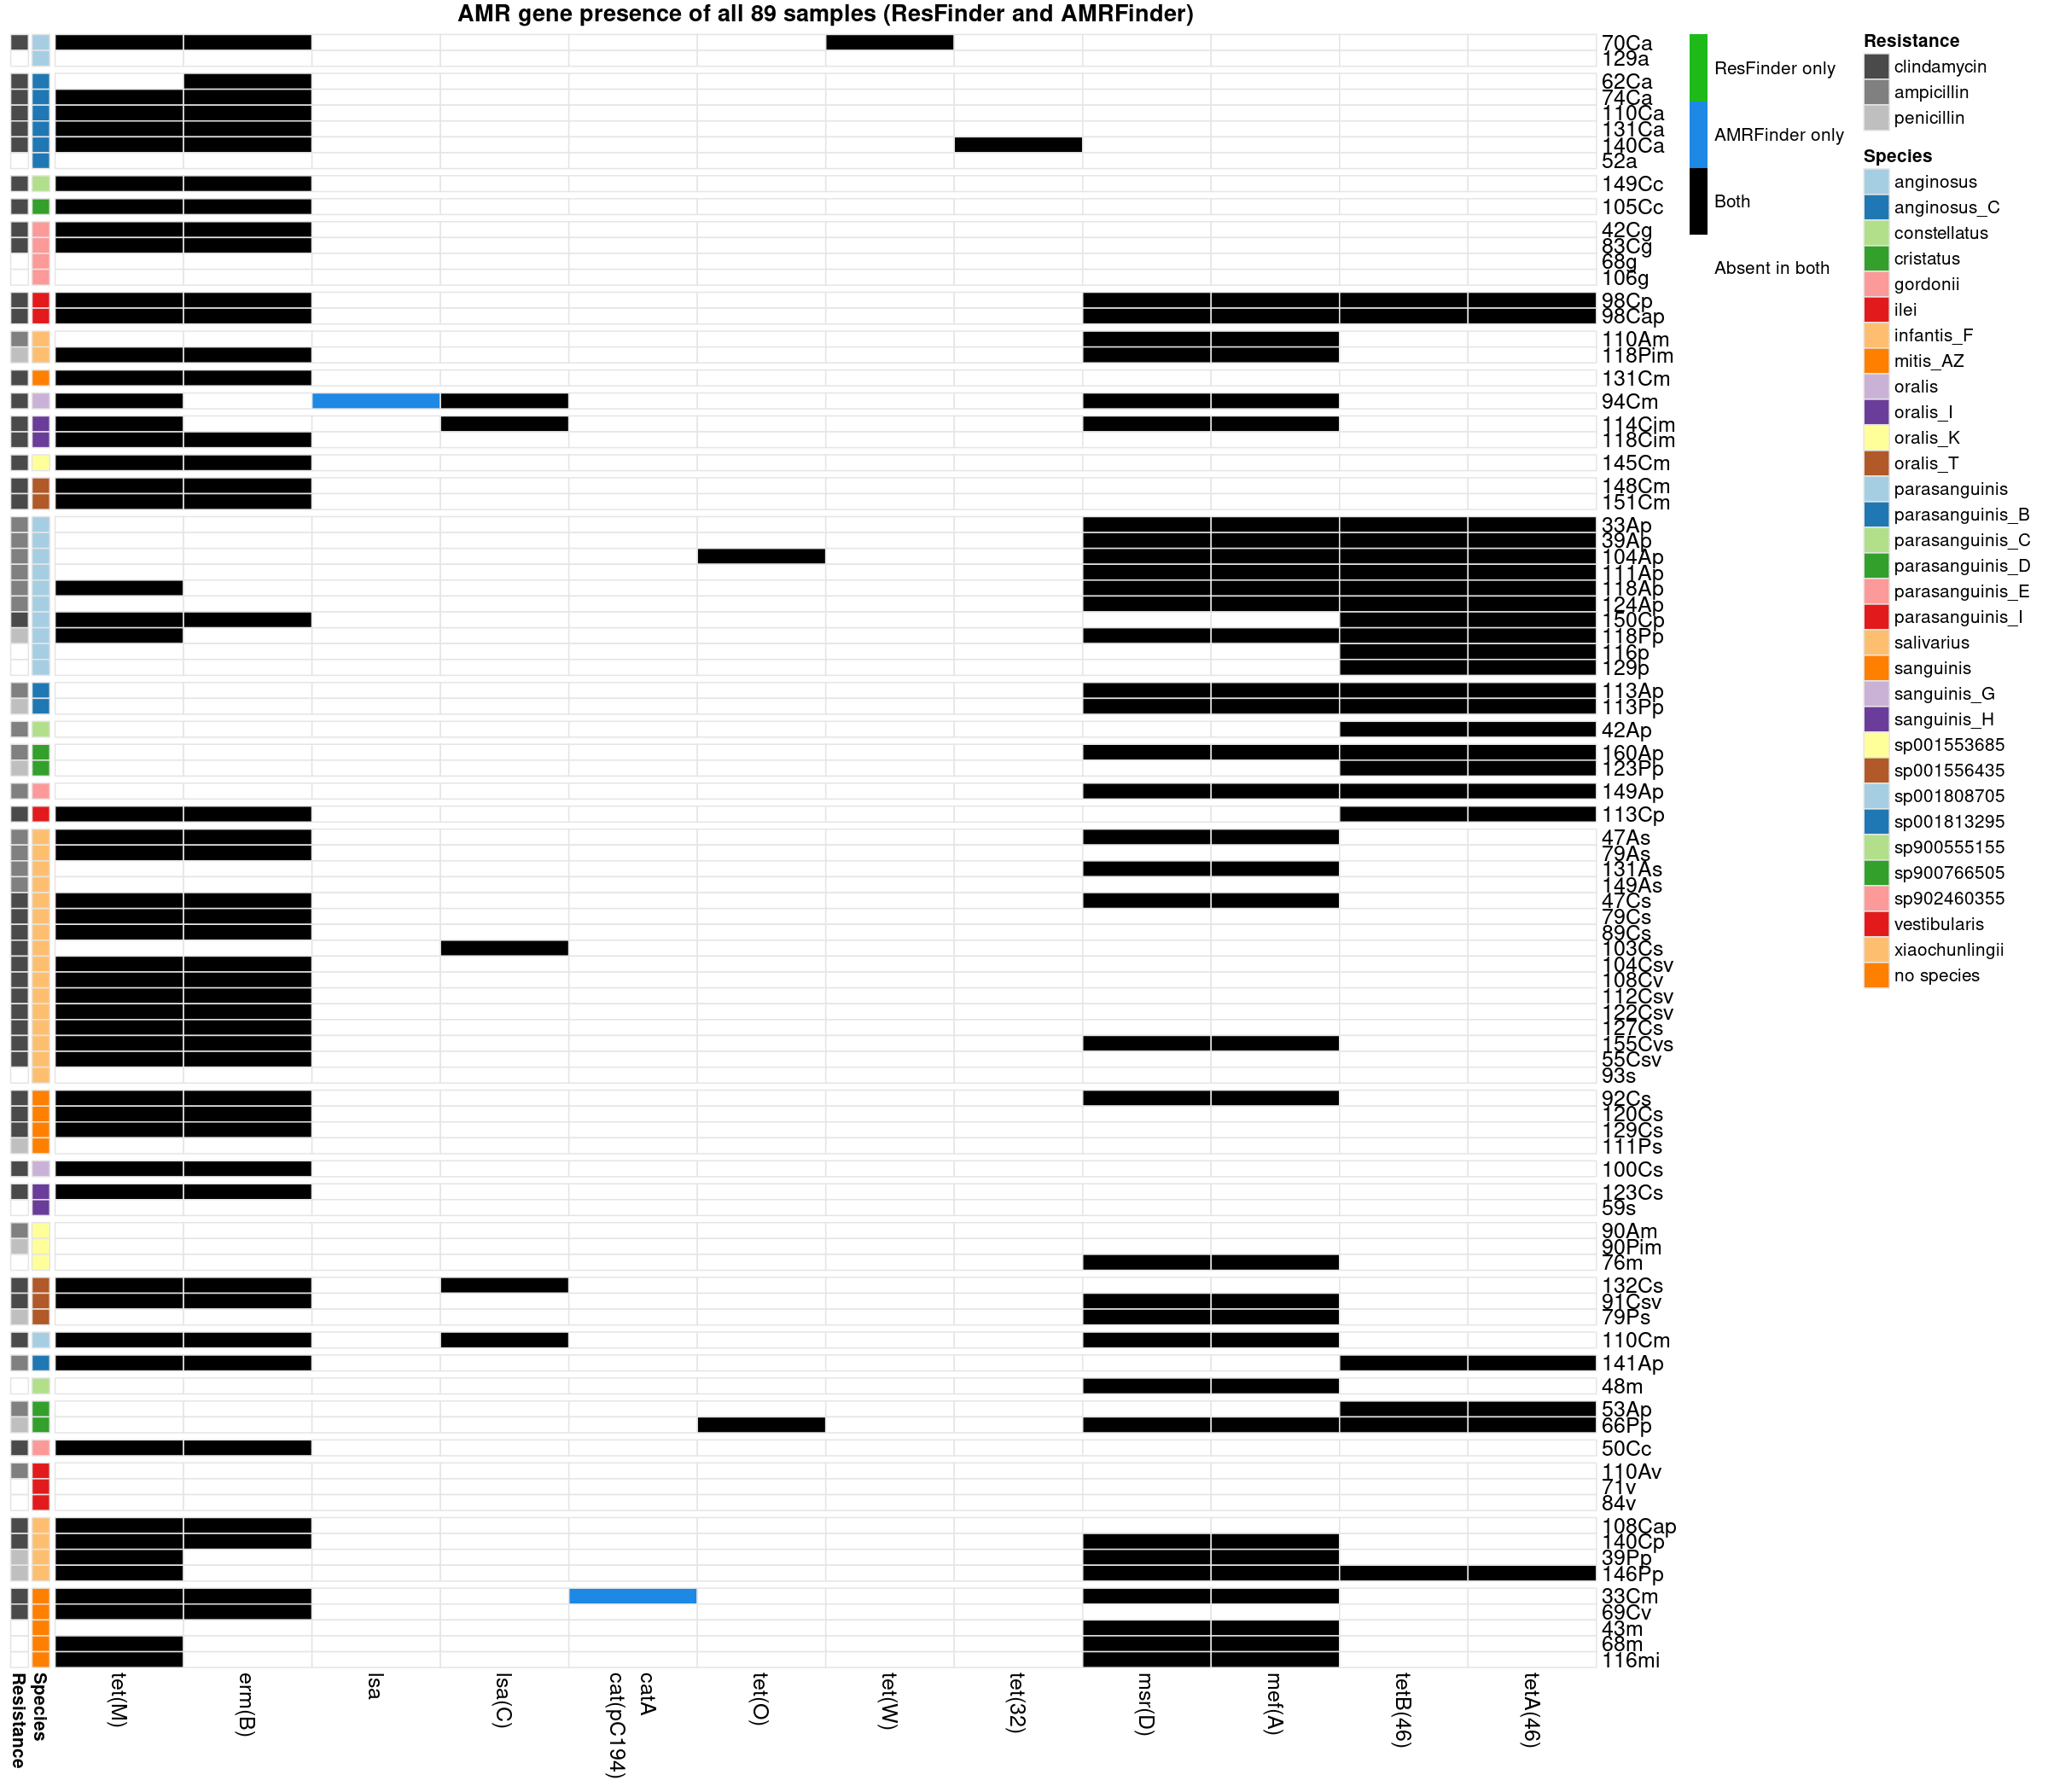

In [ ]:



# align ResFinder matrix to AMRFinder matrix (AMRFinder = reference)
amr_cols <- colnames(pa_mat_amr)

# add missing ResFinder column lsaas 0
missing_in_res <- setdiff(amr_cols, colnames(pa_mat_res))
if (length(missing_in_res) > 0) {
  add_mat <- matrix(
    0L,
    nrow = nrow(pa_mat_res),
    ncol = length(missing_in_res),
    dimnames = list(rownames(pa_mat_res), missing_in_res)
  )
  pa_mat_res <- cbind(pa_mat_res, add_mat)
}

# keep AMRFinder row/column order
pa_mat_res <- pa_mat_res[rownames(pa_mat_amr), amr_cols, drop = FALSE]


# binary presence by position
amr_bin <- (pa_mat_amr > 0) * 1L
res_bin <- (pa_mat_res > 0) * 1L

# state matrix: 0 both absent, 1 both present, 2 AMR only, 3 ResFinder only
state_mat <- ifelse(amr_bin == 1 & res_bin == 1, 1L,
             ifelse(amr_bin == 1 & res_bin == 0, 2L,
             ifelse(amr_bin == 0 & res_bin == 1, 3L, 0L)))
state_mat <- matrix(as.integer(state_mat), nrow = nrow(amr_bin), dimnames = dimnames(amr_bin))

# column labels: keep same if equal, else "AMR / ResFinder"
amr_names <- colnames(pa_mat_amr)
res_names <- colnames(pa_mat_res)

colnames(state_mat) <- ifelse(
  amr_names != "catA",
  amr_names,
  paste0(amr_names, "\n", "cat(pC194)")
)

# colors for states
state_cols <- c(
  "0" = "white",
  "1" = 'black',  # both
  "2" = "#1E88E5",  # AMRFinder only
  "3" = "#1dba1a"   # ResFinder only
)

pheatmap(
  state_mat,
  annotation_row    = annot_sorted_clean_amr,
  annotation_colors = ann_colors,
  color             = unname(state_cols[c("0","1","2","3")]),
  breaks            = c(-0.5, 0.5, 1.5, 2.5, 3.5),
  cluster_rows      = FALSE,
  cluster_cols      = TRUE,
  treeheight_col    = 0,
  gaps_row          = gaps,
  border_color      = "grey90",
  fontsize_row      = 12,
  fontsize_col      = 12,
  angle_col         = 270,
  legend_breaks     = 0:3,
  legend_labels     = c("Absent in both", "Both", "AMRFinder only", "ResFinder only"),
  main              = "AMR gene presence of all 89 samples (ResFinder and AMRFinder)"
)


In [ ]:


subset_amr <- amr_clean |>
select(sample, element_symbol) 

subset_res <- res_clean |>
select(Sample, `Resistance gene`) |> 
rename(sample = Sample, element_symbol = `Resistance gene`)

# Differences: in AMR but not in ResFinder
dplyr::setdiff(subset_amr, subset_res)

# Differences: in ResFinder but not in AMR
dplyr::setdiff(subset_res, subset_amr)


sample,element_symbol
<chr>,<chr>
033Cm-CMPN001x01_260114_LH00793_B23GCKKLT3,catA
094Cm-CMPN001x16_260114_LH00793_B23GCKKLT3,lsa


sample,element_symbol
<chr>,<chr>
033Cm-CMPN001x01_260114_LH00793_B23GCKKLT3,cat(pC194)


Note: catA and cat(pC194) appear to be the same gene with a different annotation in AMRFinder and Resfinder. On the plot they have both names. All other genes had the same annotation

##### Comparison with 2019 Abricate results

In [ ]:
abricate <- df_filtered |>
  select(GM_FILE_ID, `Abricate_resfinder-v2019-09-10_genes_coverage_lt_60perc_identity_lt_90perc`) |>
  rename(abricate_raw = 2) |>
  filter(!is.na(abricate_raw)) |>
  separate_rows(abricate_raw, sep = ',') |>
  mutate(gene = str_extract(abricate_raw, '^.+(?=_\\d+$)') |> str_trim()) |>
  distinct(GM_FILE_ID, gene) |>
  mutate(in_abricate = TRUE)

amr_simple <- amr_clean |>
  filter(!is.na(element_symbol)) |>
  distinct(sample, gene = element_symbol) |>
  mutate(in_amrfinder = TRUE)

comparison_3way <- full_join(abricate, amr_simple,
                             by = c('GM_FILE_ID' = 'sample', 'gene')) |>
  mutate(across(starts_with('in_'), \(x) coalesce(x, FALSE))) |>
  mutate(source = case_when(
    in_abricate & in_amrfinder  ~ 'Both (2019 + current)',
    in_abricate & !in_amrfinder ~ 'Abricate 2019 only',
    !in_abricate & in_amrfinder ~ 'AMRFinder only (new)'
  ))

comparison_3way |> count(source)
comparison_3way |> filter(source == "Abricate 2019 only")
comparison_3way |> filter(source == 'AMRFinder only (new)')

source,n
<chr>,<int>
AMRFinder only (new),2
Abricate 2019 only,1
Both (2019 + current),224


GM_FILE_ID,gene,in_abricate,in_amrfinder,source
<chr>,<chr>,<lgl>,<lgl>,<chr>
033Cm-CMPN001x01_260114_LH00793_B23GCKKLT3,cat(pC194),TRUE,FALSE,Abricate 2019 only


GM_FILE_ID,gene,in_abricate,in_amrfinder,source
<chr>,<chr>,<lgl>,<lgl>,<chr>
033Cm-CMPN001x01_260114_LH00793_B23GCKKLT3,catA,FALSE,TRUE,AMRFinder only (new)
094Cm-CMPN001x16_260114_LH00793_B23GCKKLT3,lsa,FALSE,TRUE,AMRFinder only (new)


## AllTheBacteria comparison

AllTheBacteria database already contains a file with all results from AMRfinder, available for the last verson of AMRfinder as well. But since it is not specified which thresholds they used, I can assume they used default settings, which is 0.5 coverage and 0.9 identity. That is not the same as in our research, where 0.6 coverage was used. So I decided to rerun the analysis, which also allows me to run them through ResFinder as well.

#### Data preparation

final dataset:


| Species | Genomes |
|---|---|
| anginosus | 173 |
| anginosus_C | 65 |
| constellatus | 46 |
| cristatus | 25 |
| gordonii | 93 |
| ilei | 6 |
| infantis_F | 16 |
| mitis_AZ | 5 |
| oralis | 106 |
| oralis_I | 6 |
| oralis_K | 1 |
| oralis_T | 13 |
| parasanguinis | 52 |
| parasanguinis_B | 3 |
| parasanguinis_C | 5 |
| parasanguinis_D | 12 |
| parasanguinis_E | 24 |
| parasanguinis_I | 11 |
| salivarius | 179 |
| sanguinis | 48 |
| sanguinis_G | 1 |
| sanguinis_H | 30 |
| sp001553685 | 5 |
| sp001556435 | 55 |
| sp001808705 | 7 |
| sp001813295 | 1 |
| sp900555155 | 1 |
| sp900766505 | 11 |
| vestibularis | 14 |
| xiaochunlingii | 20 |

### Dataframes by species preparation

Since the analysis here is by species, I need to group the genomic data from my own samples by species, to be able to make the comparison.
Each species has to have two of it's own dataframes, one with it's ResFinder results, and the other with it's AMRFinder results.

The final result I hope to be the same heatmap as before for all our samples, but for every species separately.

Samples data:

In [ ]:


# helper
clean_id <- function(x) {
  x |>
    as.character() |>
    stringr::str_remove("-.*$") |>
    stringr::str_remove("^0+") |>
    stringr::str_to_lower()
}

# all QC-passed samples + species 
sample_species_base <- species_df |>
  mutate(sample_key = clean_id(SAMPLE_ID)) |>
  filter(!is.na(GTDB_214), GTDB_214 != "no species") |>
  distinct(sample_key, GTDB_214)

# gene hits only
res_hits <- res_clean |>
  select(Sample, `Resistance gene`, Phenotype) |>
  mutate(sample_key = clean_id(Sample))

amr_hits <- amr_clean |>
  select(sample, element_symbol, element_name) |>
  mutate(sample_key = clean_id(sample))

# expand 
res_species <- sample_species_base |>
  left_join(res_hits, by = "sample_key") |>
  mutate(
    Sample = coalesce(Sample, sample_key)   # keep no-hit genomes
  )

amr_species <- sample_species_base |>
  left_join(amr_hits, by = "sample_key") |>
  mutate(
    sample = coalesce(sample, sample_key)   # keep no-hit genomes
  )

# split into one dataframe per species
res_by_species <- split(res_species, res_species$GTDB_214)
amr_by_species <- split(amr_species, amr_species$GTDB_214)

# optional: drop NA species
res_by_species <- res_by_species[names(res_by_species) != "no species"]
amr_by_species <- amr_by_species[names(amr_by_species) != "no species"]



In [ ]:
#CHECK

# list species names
names(res_by_species)
names(amr_by_species)

# see one species dataframe (example)
res_by_species[["oralis"]] |> head()
amr_by_species[["oralis"]] |> head()


[1] "anginosus"       "anginosus_C"     "constellatus"    "cristatus"      
 [5] "gordonii"        "ilei"            "infantis_F"      "mitis_AZ"       
 [9] "oralis"          "oralis_I"        "oralis_K"        "oralis_T"       
[13] "parasanguinis"   "parasanguinis_B" "parasanguinis_C" "parasanguinis_D"
[17] "parasanguinis_E" "parasanguinis_I" "salivarius"      "sanguinis"      
[21] "sanguinis_G"     "sanguinis_H"     "sp001553685"     "sp001556435"    
[25] "sp001808705"     "sp001813295"     "sp900555155"     "sp900766505"    
[29] "sp902460355"     "vestibularis"    "xiaochunlingii"

[1] "anginosus"       "anginosus_C"     "constellatus"    "cristatus"      
 [5] "gordonii"        "ilei"            "infantis_F"      "mitis_AZ"       
 [9] "oralis"          "oralis_I"        "oralis_K"        "oralis_T"       
[13] "parasanguinis"   "parasanguinis_B" "parasanguinis_C" "parasanguinis_D"
[17] "parasanguinis_E" "parasanguinis_I" "salivarius"      "sanguinis"      
[21] "sanguinis_G"     "sanguinis_H"     "sp001553685"     "sp001556435"    
[25] "sp001808705"     "sp001813295"     "sp900555155"     "sp900766505"    
[29] "sp902460355"     "vestibularis"    "xiaochunlingii"

sample_key,GTDB_214,Sample,Resistance gene,Phenotype
<chr>,<chr>,<chr>,<chr>,<chr>
94cm,oralis,094Cm-CMPN001x16_260114_LH00793_B23GCKKLT3,msr(D),"Erythromycin, Azithromycin, Telithromycin, Quinupristin, Pristinamycin IA, Virginiamycin S"
94cm,oralis,094Cm-CMPN001x16_260114_LH00793_B23GCKKLT3,mef(A),"Erythromycin, Azithromycin"
94cm,oralis,094Cm-CMPN001x16_260114_LH00793_B23GCKKLT3,lsa(C),"Lincomycin, Clindamycin, Dalfopristin, Pristinamycin IIA, Virginiamycin M, Tiamulin"
94cm,oralis,094Cm-CMPN001x16_260114_LH00793_B23GCKKLT3,lsa(C),"Lincomycin, Clindamycin, Dalfopristin, Pristinamycin IIA, Virginiamycin M, Tiamulin"
94cm,oralis,094Cm-CMPN001x16_260114_LH00793_B23GCKKLT3,tet(M),"Doxycycline, Tetracycline, Minocycline"


sample_key,GTDB_214,sample,element_symbol,element_name
<chr>,<chr>,<chr>,<chr>,<chr>
94cm,oralis,094Cm-CMPN001x16_260114_LH00793_B23GCKKLT3,mef(A),macrolide efflux MFS transporter Mef(A)
94cm,oralis,094Cm-CMPN001x16_260114_LH00793_B23GCKKLT3,msr(D),ABC-F type ribosomal protection protein Msr(D)
94cm,oralis,094Cm-CMPN001x16_260114_LH00793_B23GCKKLT3,tet(M),tetracycline resistance ribosomal protection protein Tet(M)
94cm,oralis,094Cm-CMPN001x16_260114_LH00793_B23GCKKLT3,lsa,Lsa family ABC-F type ribosomal protection protein
94cm,oralis,094Cm-CMPN001x16_260114_LH00793_B23GCKKLT3,lsa(C),ABC-F type ribosomal protection protein Lsa(C)


In [ ]:
# save to files 

dir.create("../results/species_tables/resfinder", recursive = TRUE, showWarnings = FALSE)
dir.create("../results/species_tables/amrfinder", recursive = TRUE, showWarnings = FALSE)


# save ResFinder species dfs
purrr::iwalk(res_by_species, \(df, sp) {
  readr::write_tsv(df, file.path("../results/species_tables/resfinder", paste0(sp, ".tsv")))
})

# save AMRFinder species dfs
purrr::iwalk(amr_by_species, \(df, sp) {
  readr::write_tsv(df, file.path("../results/species_tables/amrfinder", paste0(sp, ".tsv")))
})

# check saved files
#list.files("results/species_tables/resfinder", full.names = TRUE)
#list.files("results/species_tables/amrfinder", full.names = TRUE)

All genomes from ATB:

In [ ]:
all_genomes_atb <- read_tsv("../results/atb/atb_genome_list.tsv")
head(all_genomes_atb)

Rows: 1034 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): genome_id, species

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


genome_id,species
<chr>,<chr>
SAMEA104042167,anginosus
SAMEA104042168,anginosus
SAMEA104042169,anginosus
SAMEA104042172,anginosus
SAMEA104042173,anginosus
SAMEA104055225,anginosus


Combine

In [ ]:
#example of data

df <- read_tsv("../results/atb/resfinder_atb/resfinder_vestibularis.tsv")
head(df)

Rows: 2 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (9): Genome, Species, Resistance gene, Alignment Length/Gene Length, Pos...
dbl (2): Identity, Coverage



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Genome,Species,Resistance gene,Identity,Alignment Length/Gene Length,Coverage,Position in reference,Contig,Position in contig,Phenotype,Accession no.
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
SAMEA104138627,vestibularis,lsa(C),91.62,1479/1479,100,1..1479,SAMEA104138627.contig00024 len=35876 cov=32.0 corr=0 origname=NODE_24_length_35876_cov_31.965332_pilon sw=shovill-spades/1.0.4 date=20181220,14451..15929,"Lincomycin, Clindamycin, Dalfopristin, Pristinamycin IIA, Virginiamycin M, Tiamulin",HM990671
SAMEA13883080,vestibularis,tet(M),99.84,1920/1920,100,1..1920,SAMEA13883080.contig00009 len=81017 cov=40.9 corr=0 origname=NODE_9_length_81017_cov_40.855005_pilon sw=shovill-spades/1.1.0 date=20230624,29531..31450,"Doxycycline, Tetracycline, Minocycline",X75073


In [ ]:

df <- read_tsv("../results/atb/amrfinder_atb/amrfinder_vestibularis.tsv")
head(df)

Rows: 1 Columns: 24
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (14): Genome, Species, Contig id, Strand, Element symbol, Element name, ...
dbl  (7): Start, Stop, Target length, Reference sequence length, % Coverage ...
lgl  (3): Protein id, HMM accession, HMM description

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Genome,Species,Protein id,Contig id,Start,Stop,Strand,Element symbol,Element name,Scope,⋯,Method,Target length,Reference sequence length,% Coverage of reference,% Identity to reference,Alignment length,Closest reference accession,Closest reference name,HMM accession,HMM description
<chr>,<chr>,<lgl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,<lgl>
SAMEA13883080,vestibularis,NA,SAMEA13883080.contig00009,29534,31450,-,tet(M),tetracycline resistance ribosomal protection protein Tet(M),core,⋯,BLASTX,639,639,100,99.84,639,WP_000691727.1,tetracycline resistance ribosomal protection protein Tet(M),NA,NA


In [ ]:


# all genomes per species
atb_manifest <- all_genomes_atb |>
  transmute(species, sample = as.character(genome_id)) |>
  distinct()


# fill ATB ResFinder per species
atb_res_dir <- "../results/atb/resfinder_atb"
atb_res_files <- list.files(atb_res_dir, pattern = "^resfinder_.*\\.tsv$", full.names = TRUE)

atb_res_list <- purrr::map(atb_res_files, \(f) {
  sp <- basename(f) |> str_remove("^resfinder_") |> str_remove("\\.tsv$")

  df <- read_tsv(f, show_col_types = FALSE) |>
    rename(Sample = Genome) |>
    transmute(Sample = as.character(Sample), `Resistance gene`, Phenotype, source = "atb") |>
    distinct()

  missing <- atb_manifest |>
    filter(species == sp, !sample %in% df$Sample) |>
    transmute(Sample = sample, `Resistance gene` = NA_character_, Phenotype = NA_character_, source = "atb")

  list(species = sp, data = bind_rows(df, missing) |> distinct())
})
names(atb_res_list) <- purrr::map_chr(atb_res_list, "species")

# fill ATB AMRFinder per species
atb_amr_dir <- "../results/atb/amrfinder_atb"
atb_amr_files <- list.files(atb_amr_dir, pattern = "^amrfinder_.*\\.tsv$", full.names = TRUE)

atb_amr_list <- purrr::map(atb_amr_files, \(f) {
  sp <- basename(f) |> str_remove("^amrfinder_") |> str_remove("\\.tsv$")

  df <- read_tsv(f, show_col_types = FALSE) |>
    rename(sample = Genome, element_symbol = `Element symbol`, element_name = `Element name`) |>
    transmute(sample = as.character(sample), element_symbol, element_name, source = "atb") |>
    distinct()

  missing <- atb_manifest |>
    filter(species == sp, !sample %in% df$sample) |>
    transmute(sample = sample, element_symbol = NA_character_, element_name = NA_character_, source = "atb")

  list(species = sp, data = bind_rows(df, missing) |> distinct())
})
names(atb_amr_list) <- purrr::map_chr(atb_amr_list, "species")

# source to species tables
res_by_species <- purrr::map(res_by_species, ~mutate(.x, source = "rmarvig"))
amr_by_species <- purrr::map(amr_by_species, ~mutate(.x, source = "rmarvig"))

# combine
combined_res <- purrr::map2(res_by_species, names(res_by_species), ~{
  my_data <- .x
  atb_data <- if (.y %in% names(atb_res_list)) atb_res_list[[.y]]$data else tibble()
  bind_rows(my_data, atb_data)
})

combined_amr <- purrr::map2(amr_by_species, names(amr_by_species), ~{
  my_data <- .x
  atb_data <- if (.y %in% names(atb_amr_list)) atb_amr_list[[.y]]$data else tibble()
  bind_rows(my_data, atb_data)
})



In [ ]:
# save combined per-species tables
dir.create("../results/species_tables/combined/resfinder", recursive = TRUE, showWarnings = FALSE)
dir.create("../results/species_tables/combined/amrfinder", recursive = TRUE, showWarnings = FALSE)

iwalk(combined_res, \(df, sp) {
  write_tsv(df, file.path("../results/species_tables/combined/resfinder", paste0("combined_", sp, ".tsv")))
})

iwalk(combined_amr, \(df, sp) {
  write_tsv(df, file.path("../results/species_tables/combined/amrfinder", paste0("combined_", sp, ".tsv")))
})

# save one master table per tool
combined_res_all <- bind_rows(combined_res, .id = "species")
combined_amr_all <- bind_rows(combined_amr, .id = "species")

write_tsv(combined_res_all, "../results/species_tables/combined/combined_res_all.tsv")
write_tsv(combined_amr_all, "../results/species_tables/combined/combined_amr_all.tsv")

### Per-species analysis

In [ ]:
bind_rows(combined_amr, .id = "species") |>
  filter(stringr::str_trim(element_symbol) == "blaTEM") |>
  distinct()

species,sample_key,GTDB_214,sample,element_symbol,element_name,source
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
oralis,NA,NA,SAMN02923991,blaTEM,TEM family class A beta-lactamase,atb


In [ ]:
bind_rows(combined_amr, .id = "species") |>
  filter(element_symbol %in% c("blaTEM-116", "blaTEM", "ant(6)-Ia", "catA"))

species,sample_key,GTDB_214,sample,element_symbol,element_name,source
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
anginosus,NA,NA,SAMN47264449,blaTEM-116,broad-spectrum class A beta-lactamase TEM-116,atb
gordonii,NA,NA,SAMN20399913,catA,type A-9 chloramphenicol O-acetyltransferase,atb
oralis,NA,NA,SAMEA116302120,ant(6)-Ia,aminoglycoside nucleotidyltransferase ANT(6)-Ia,atb
oralis,NA,NA,SAMN02923991,blaTEM,TEM family class A beta-lactamase,atb
oralis,NA,NA,SAMN02923992,blaTEM-116,broad-spectrum class A beta-lactamase TEM-116,atb
salivarius,NA,NA,SAMN05421814,blaTEM-116,broad-spectrum class A beta-lactamase TEM-116,atb


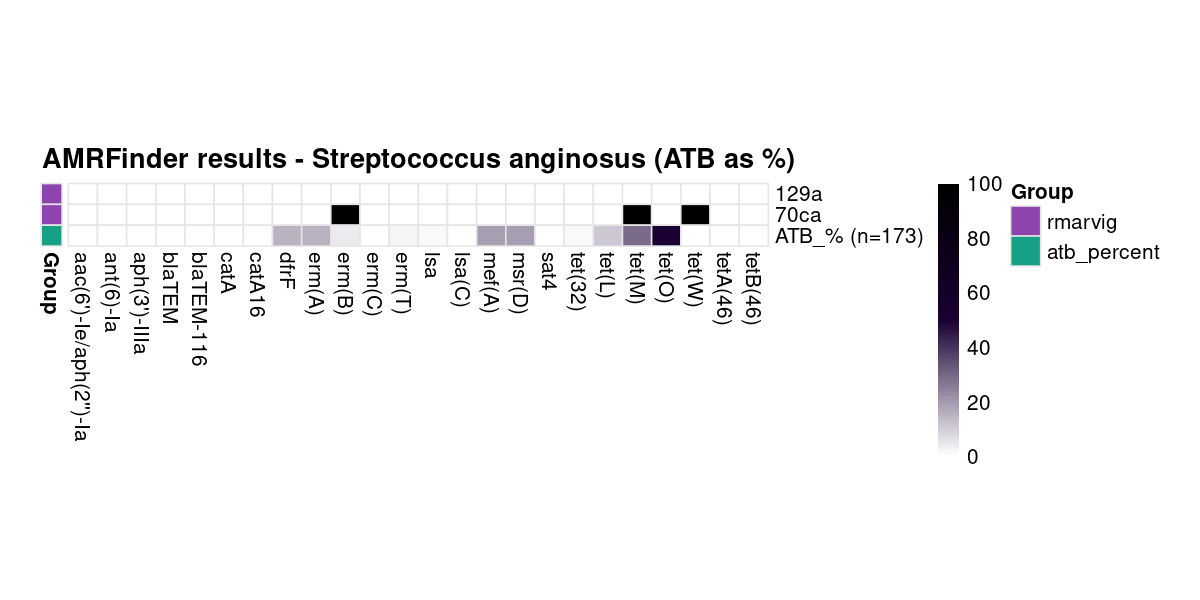

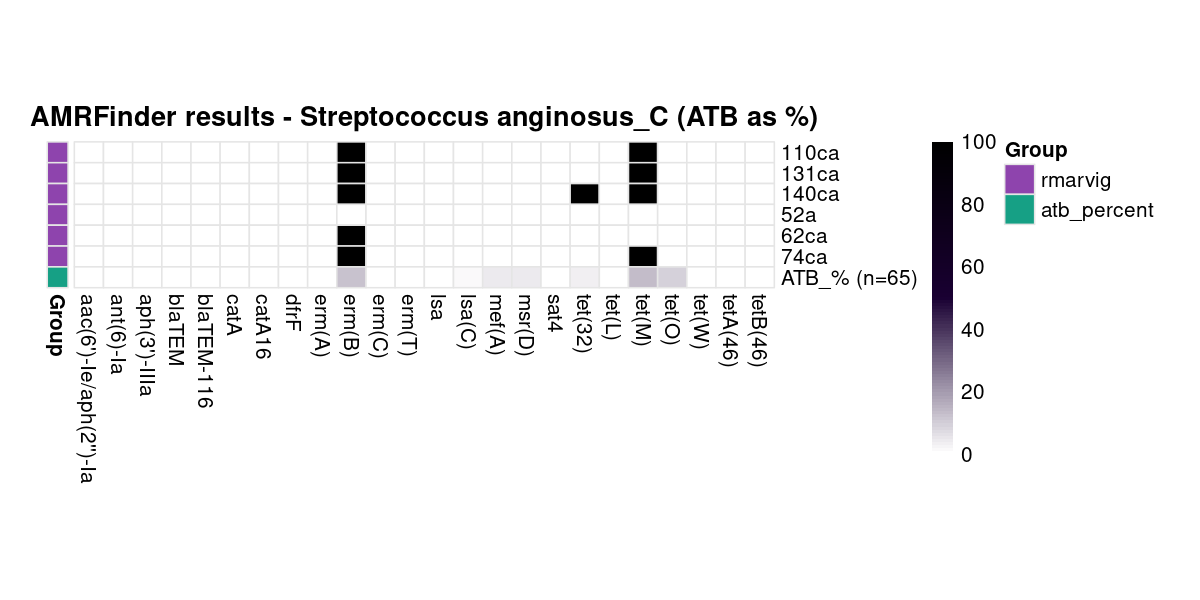

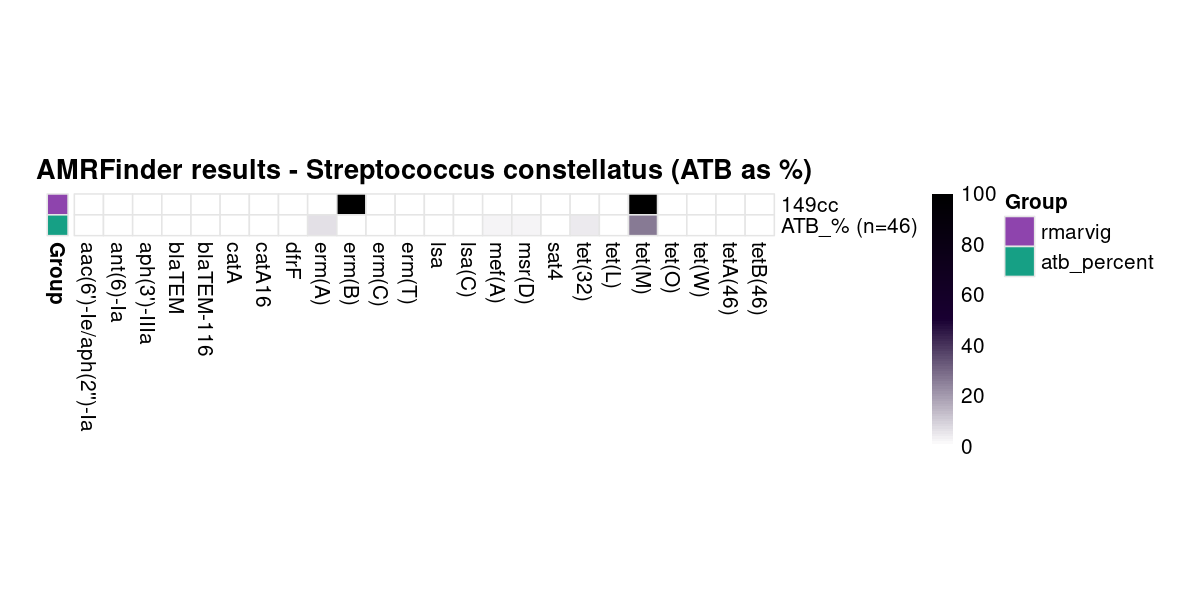

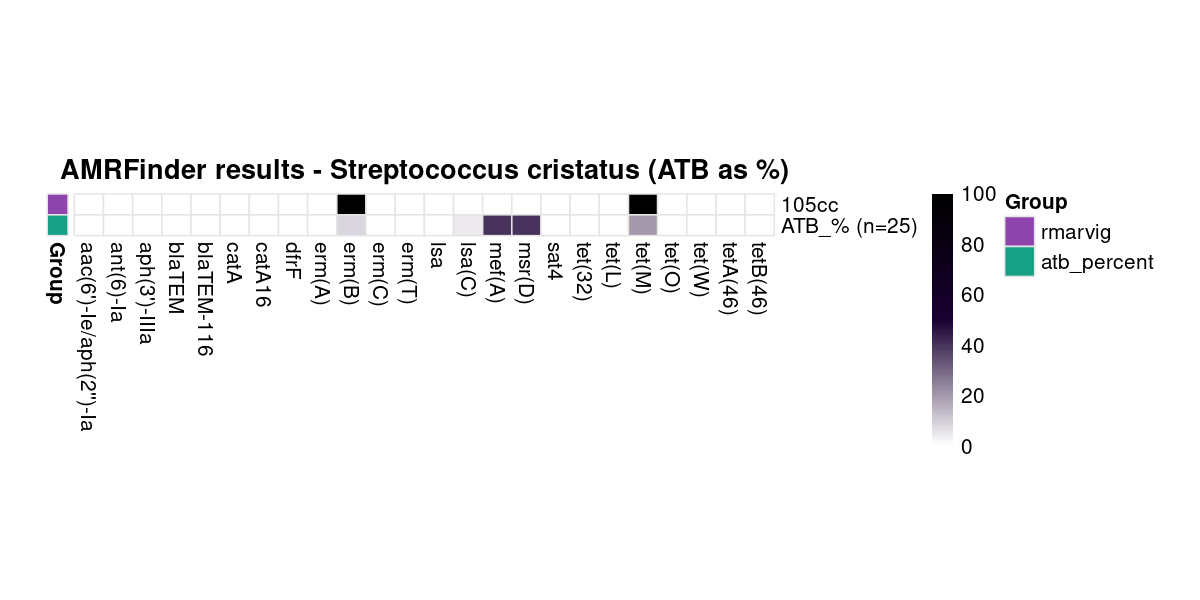

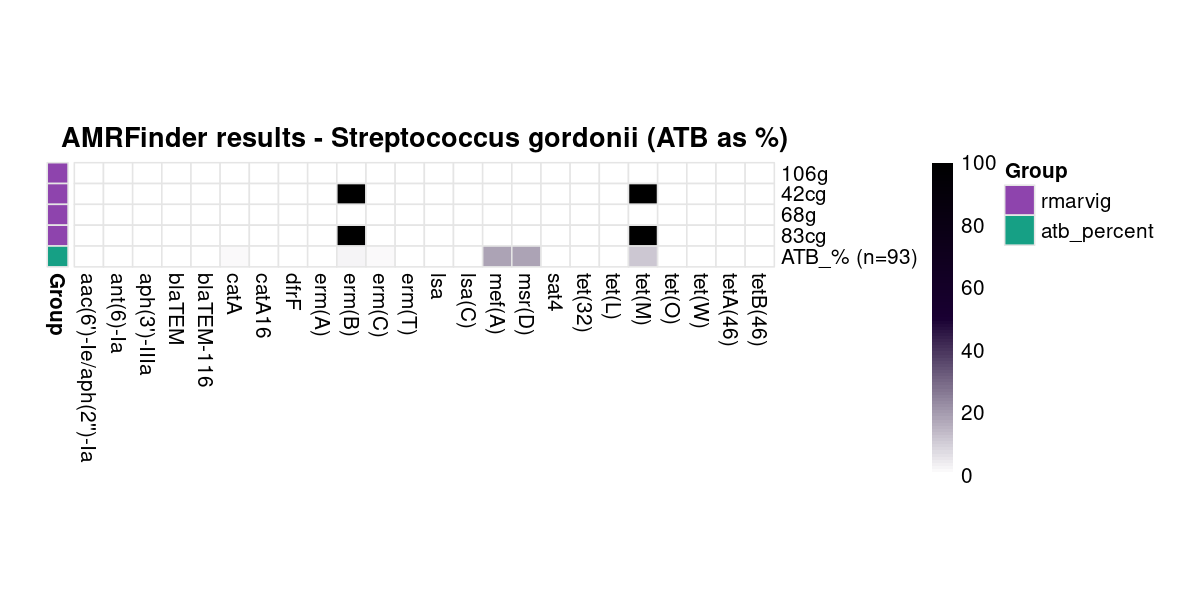

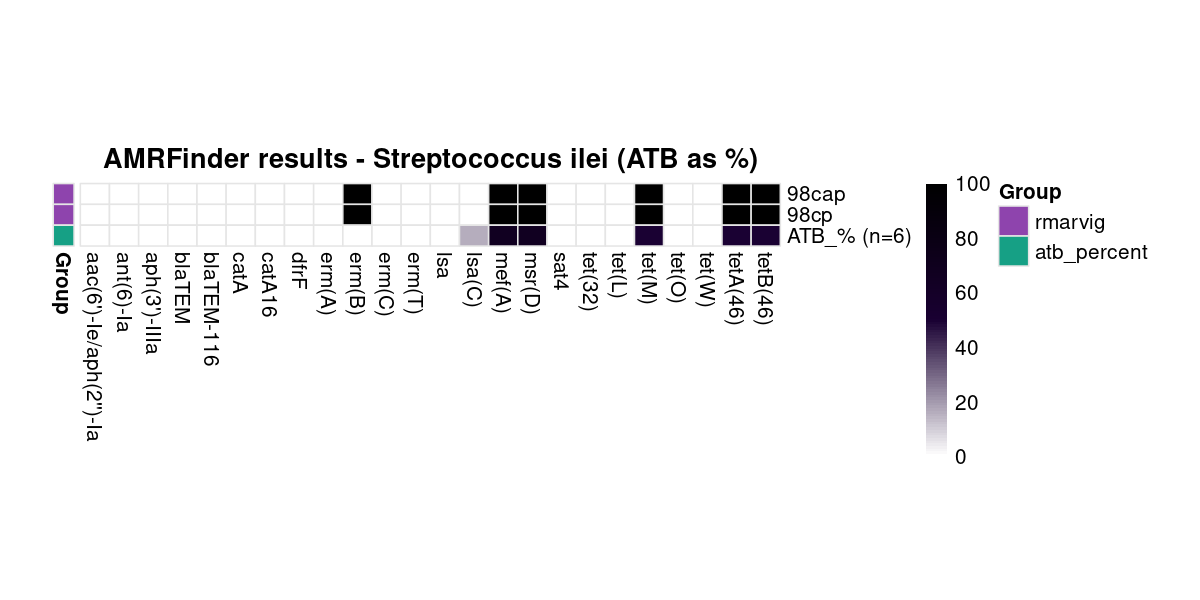

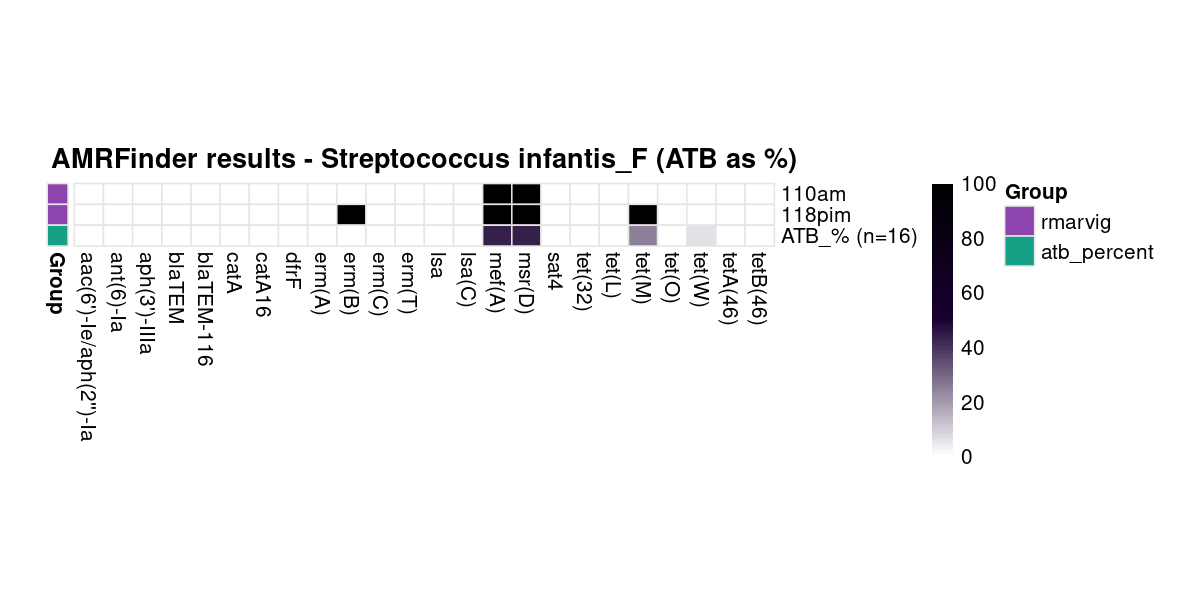

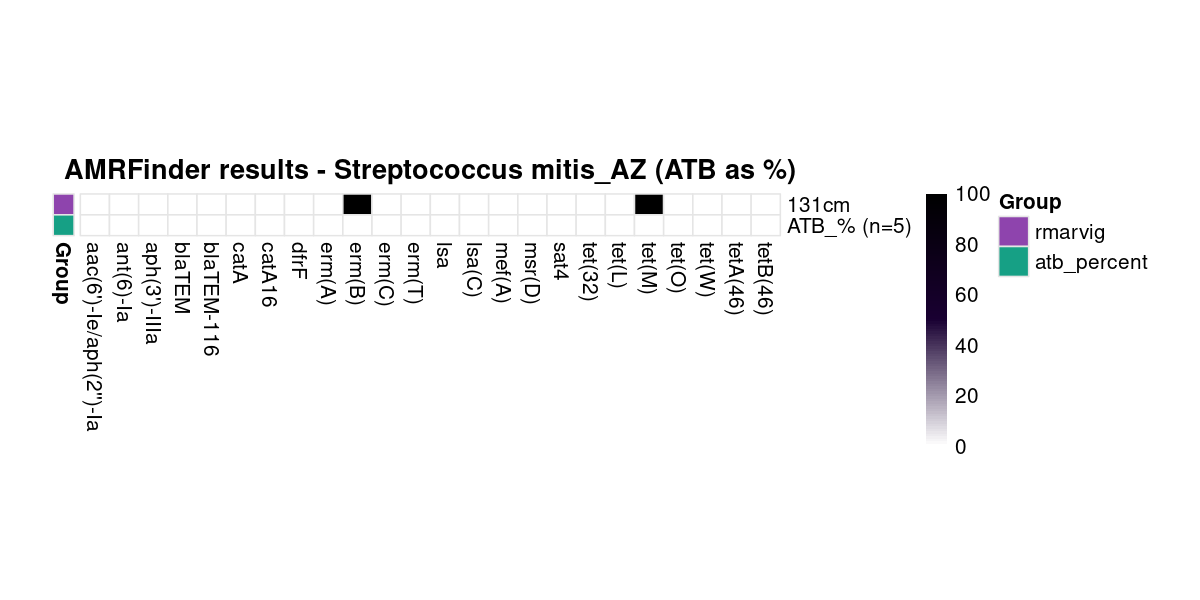

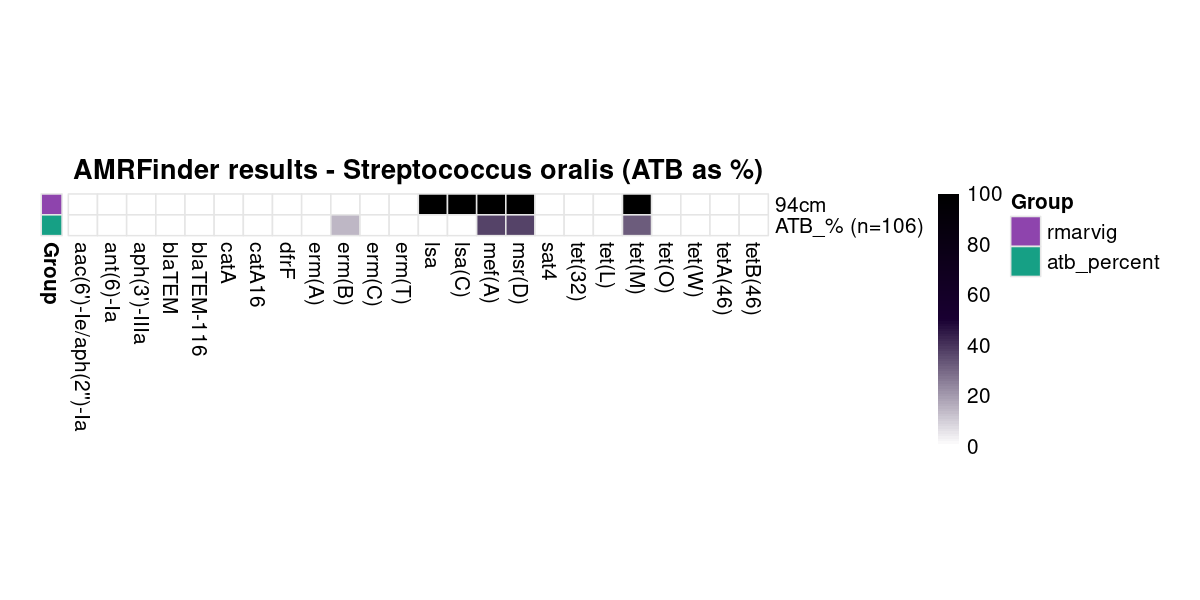

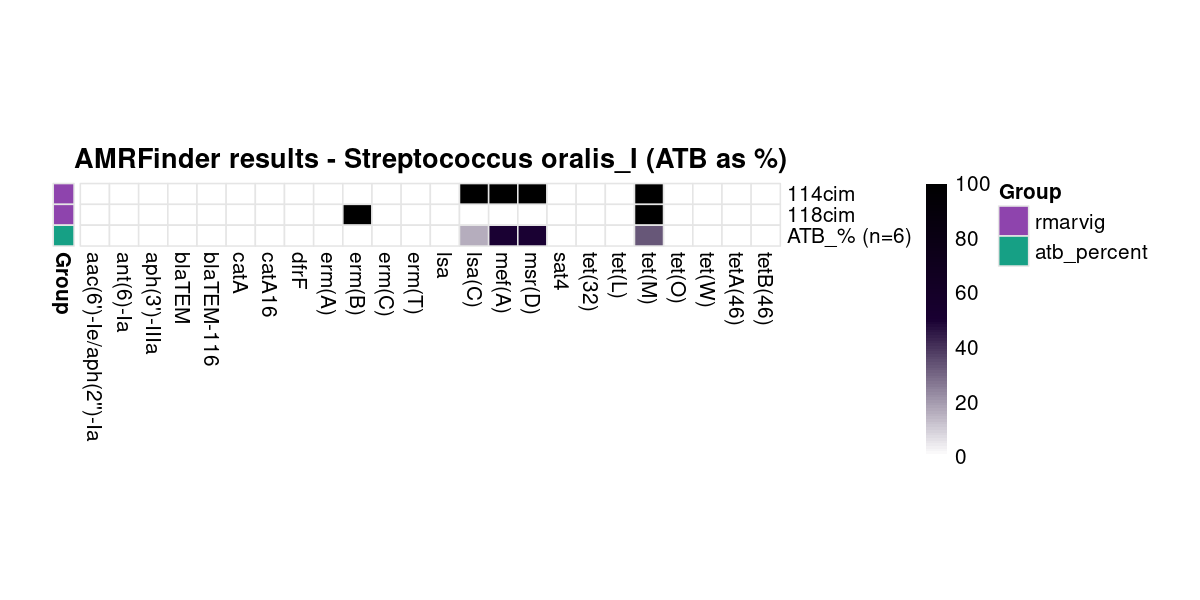

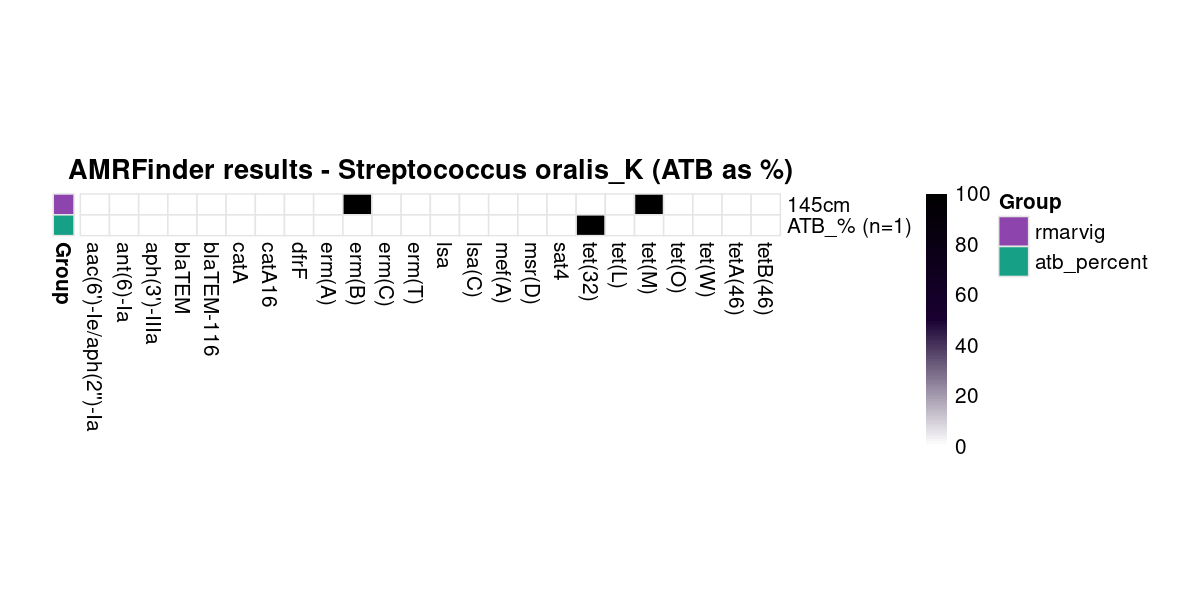

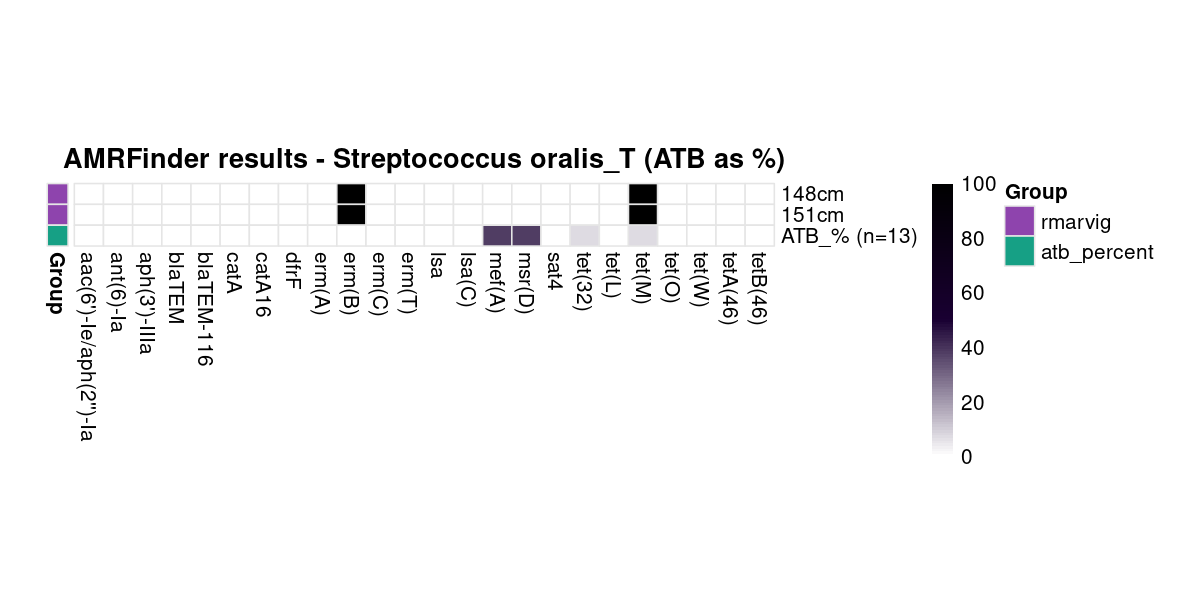

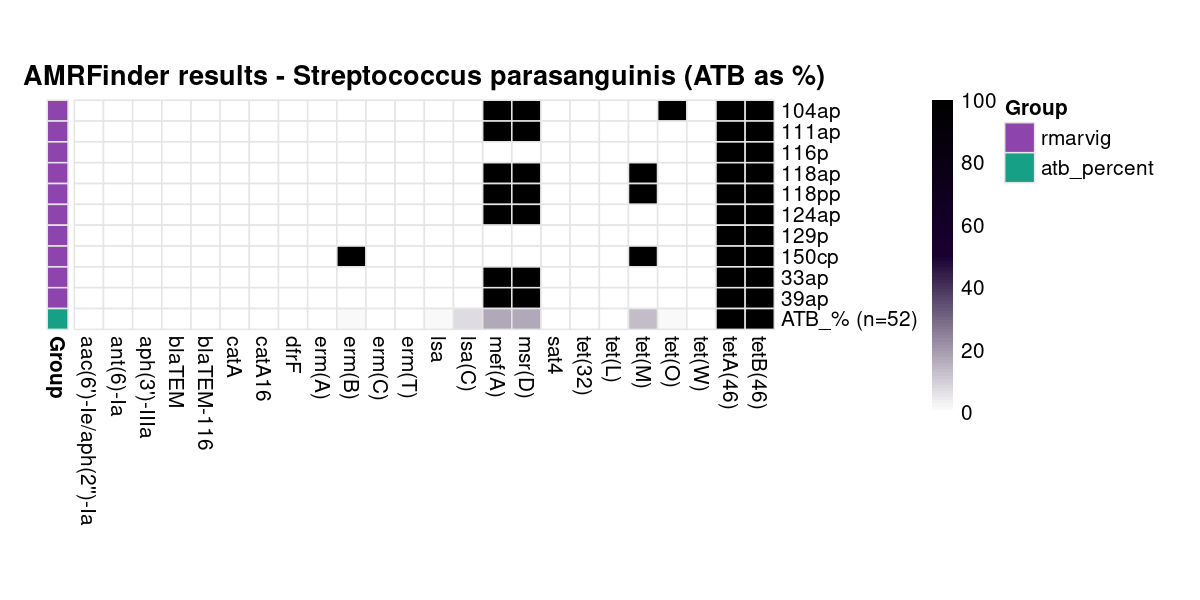

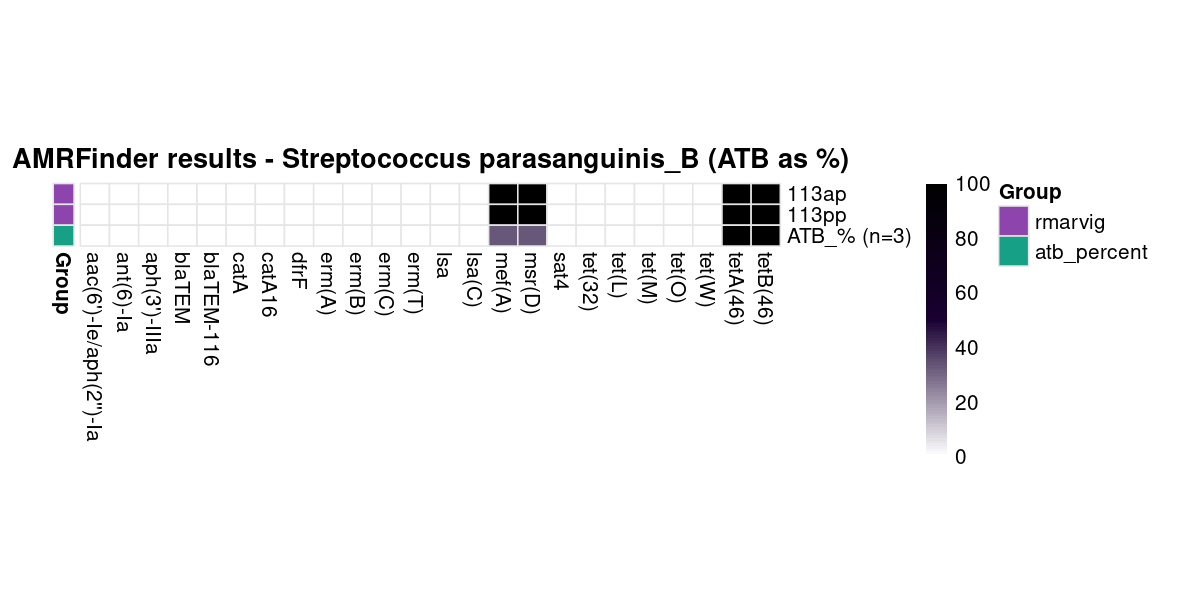

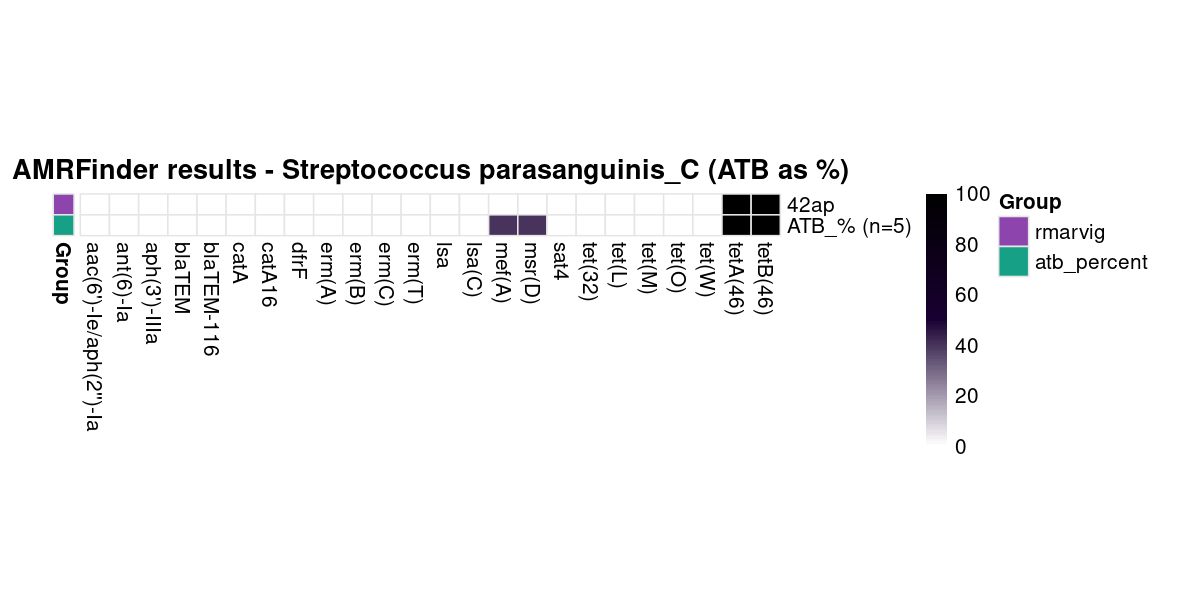

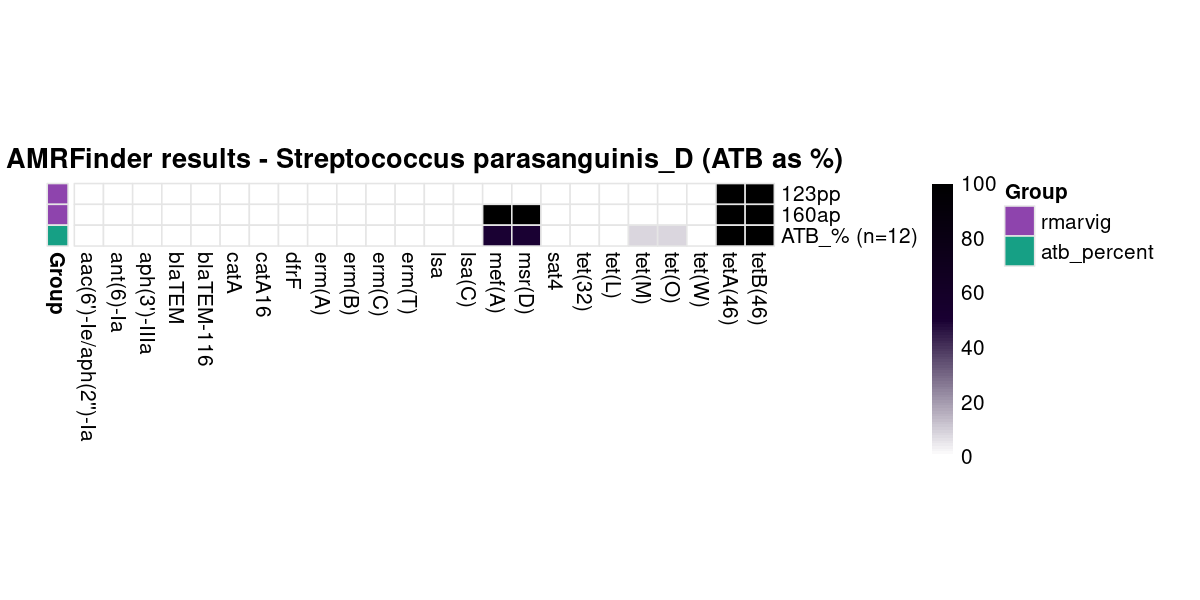

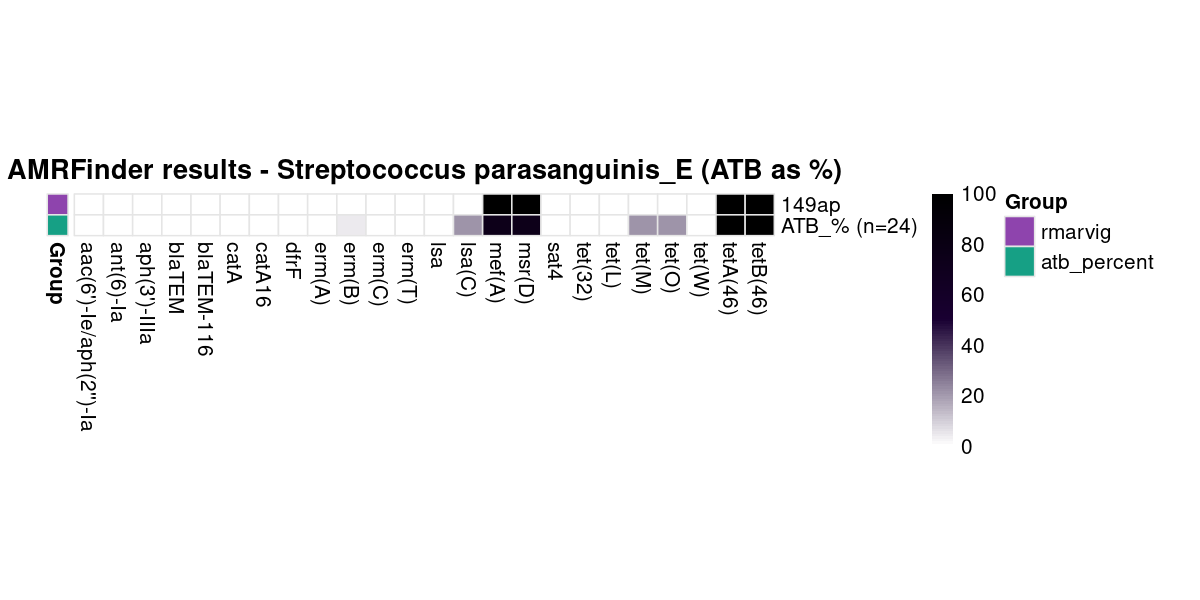

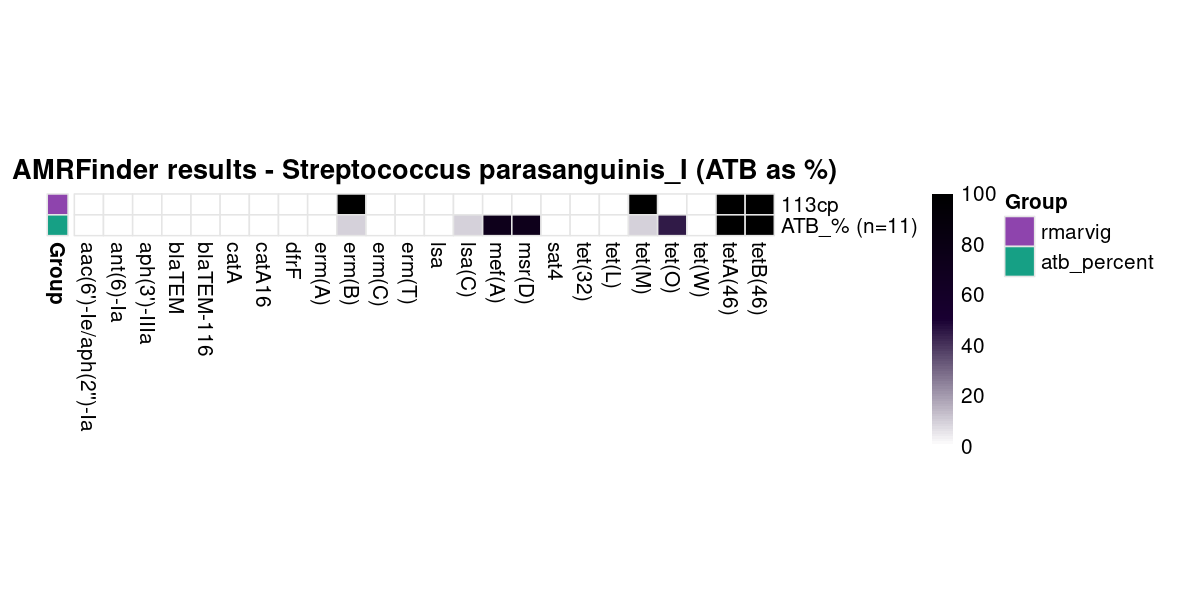

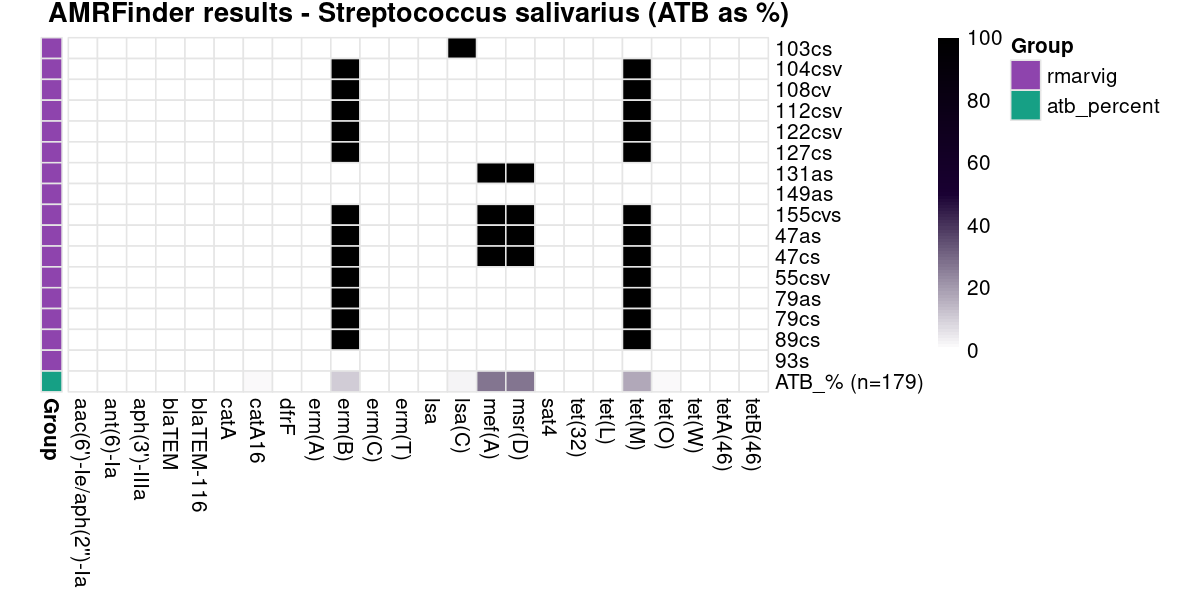

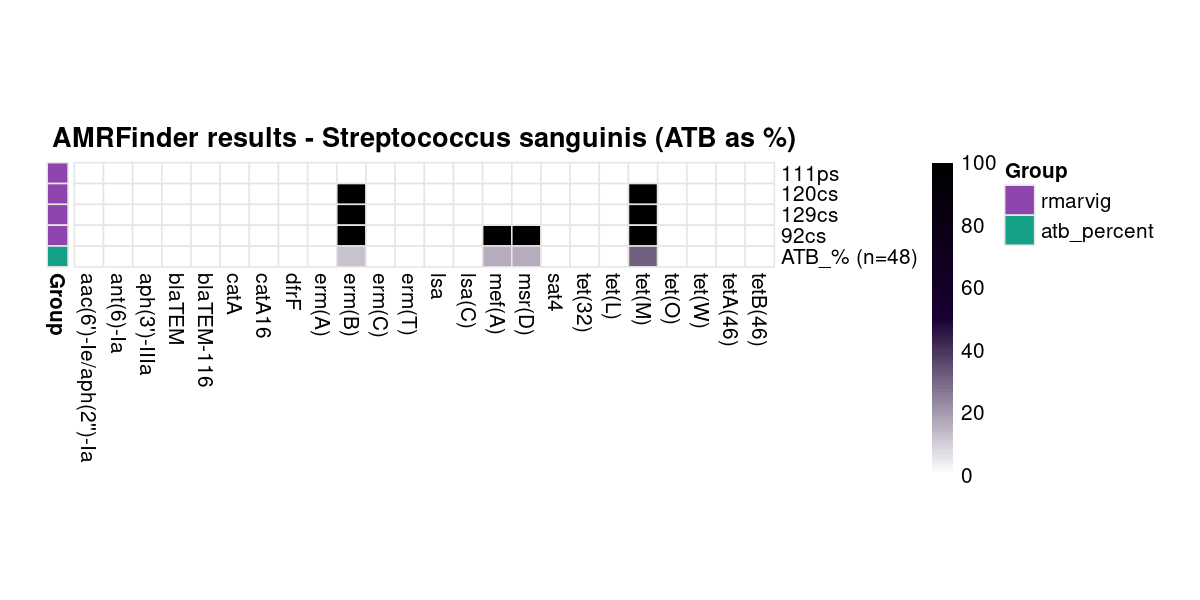

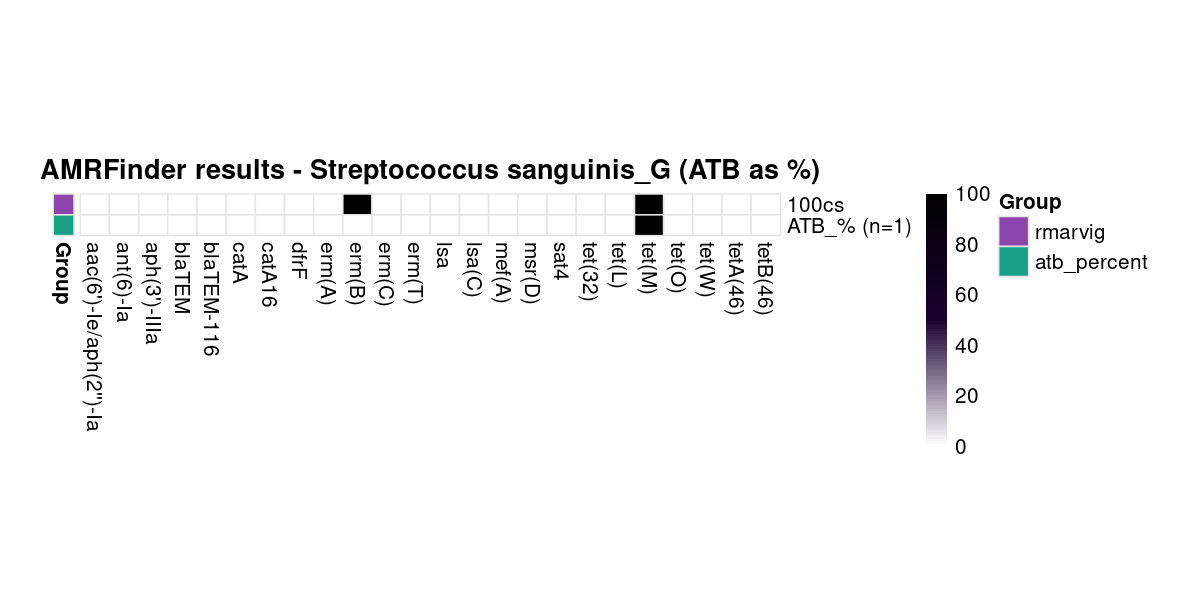

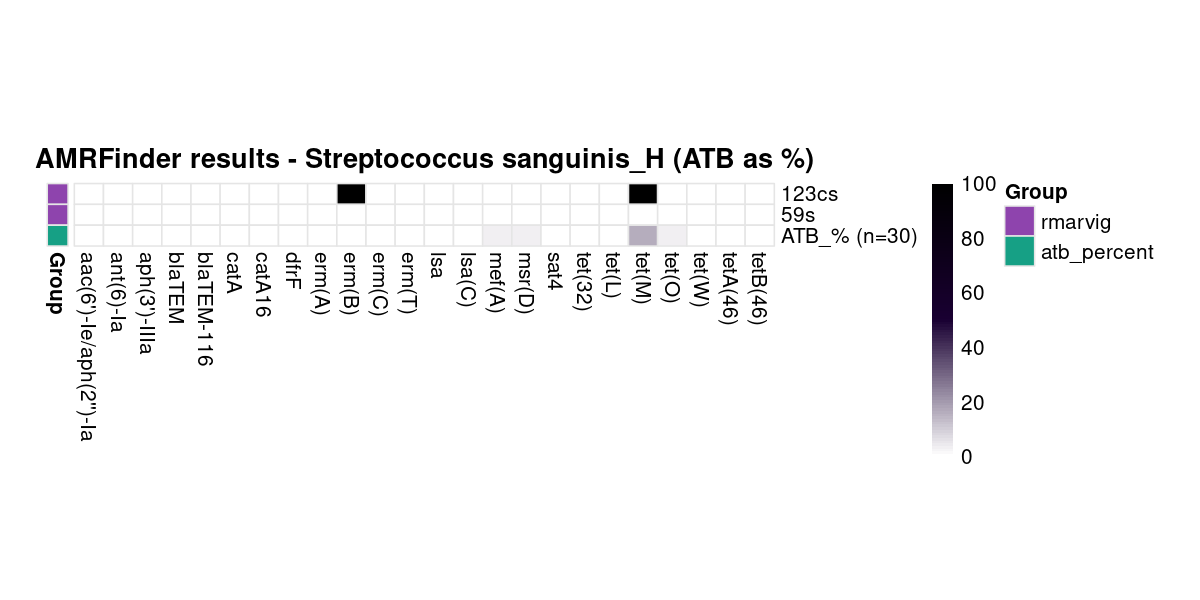

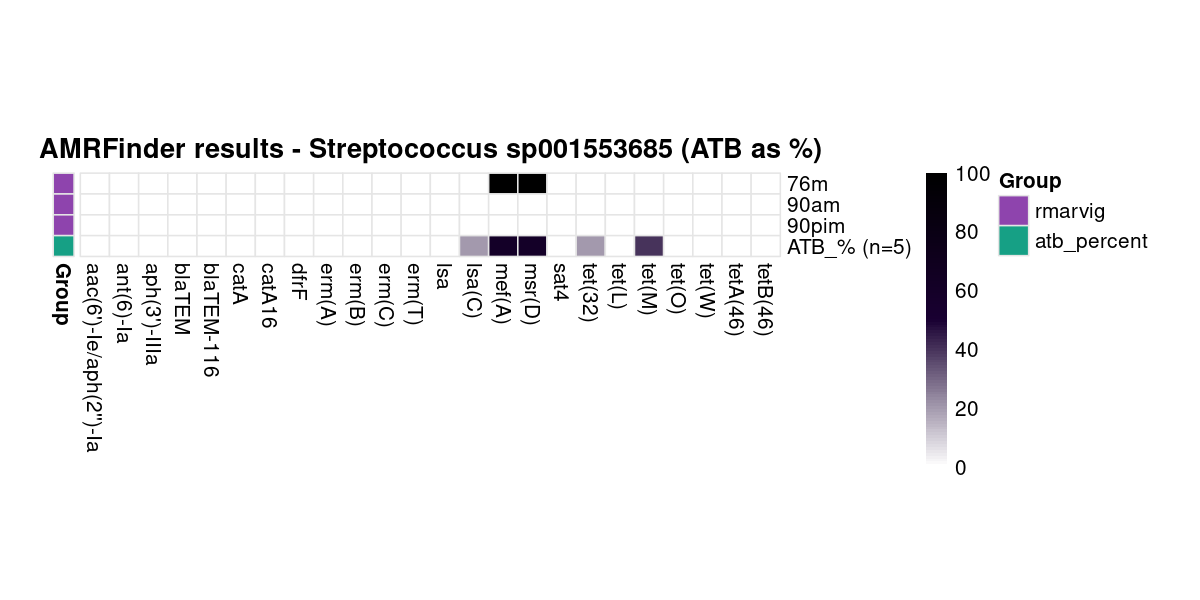

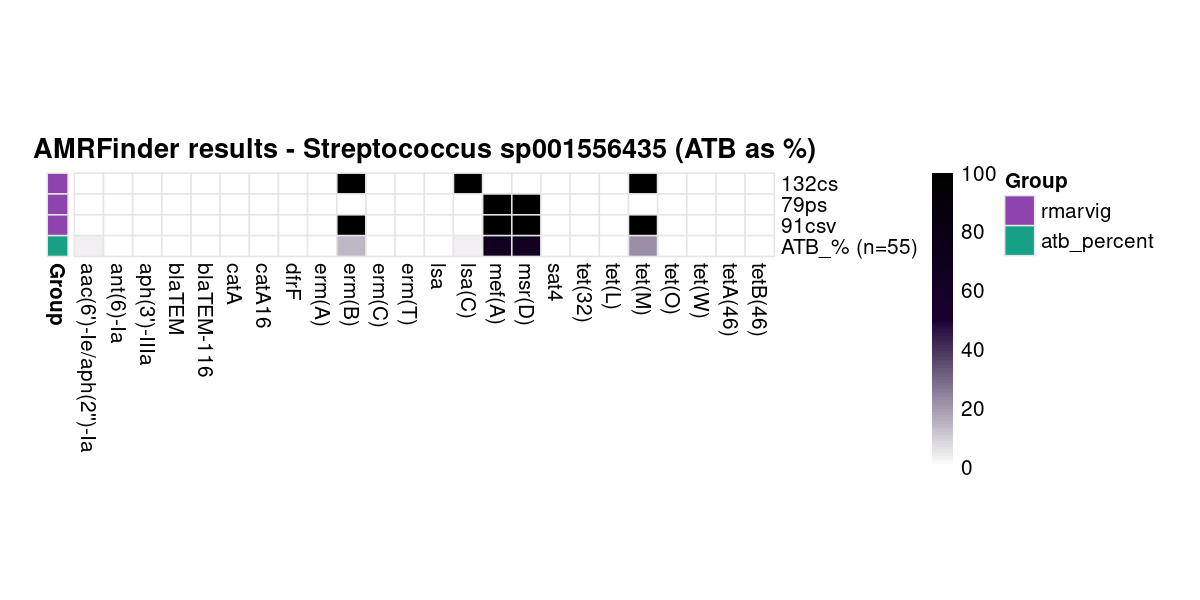

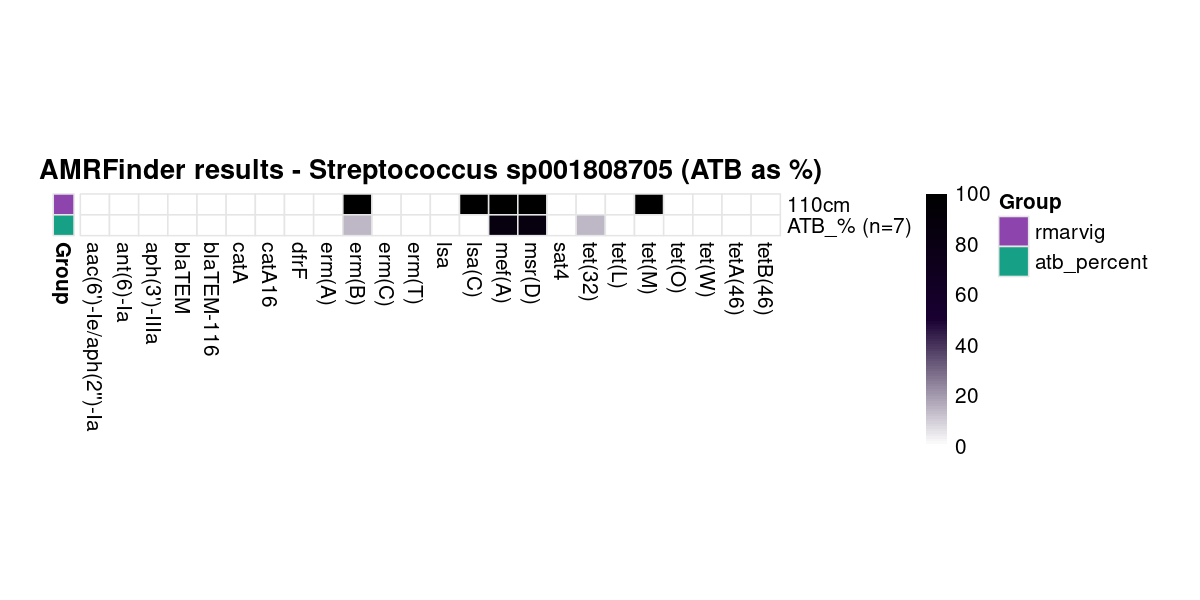

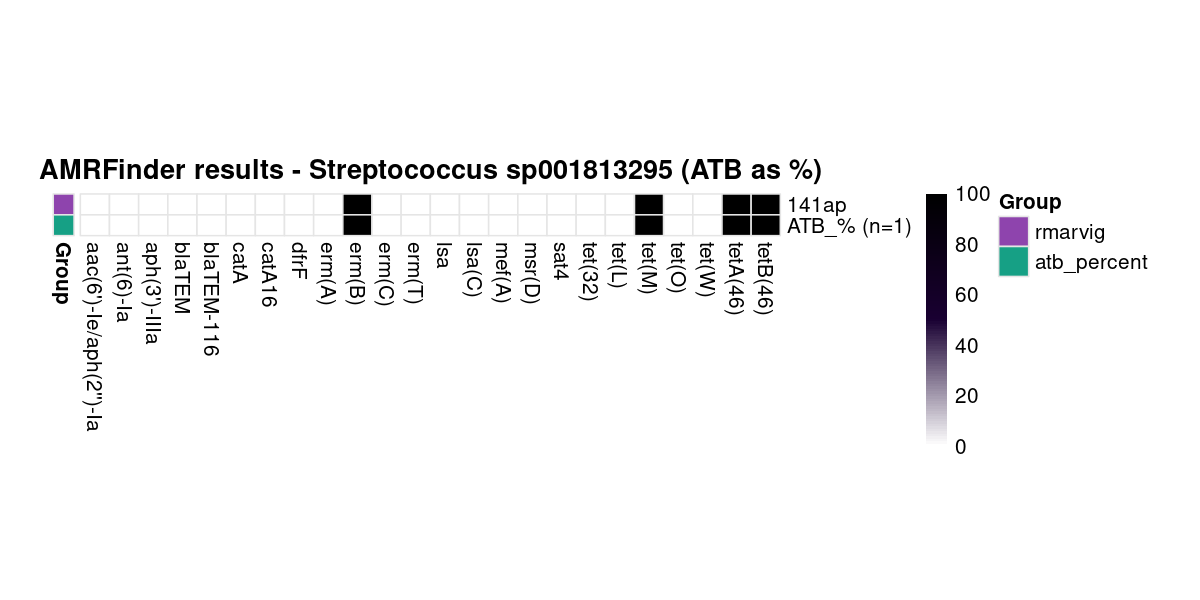

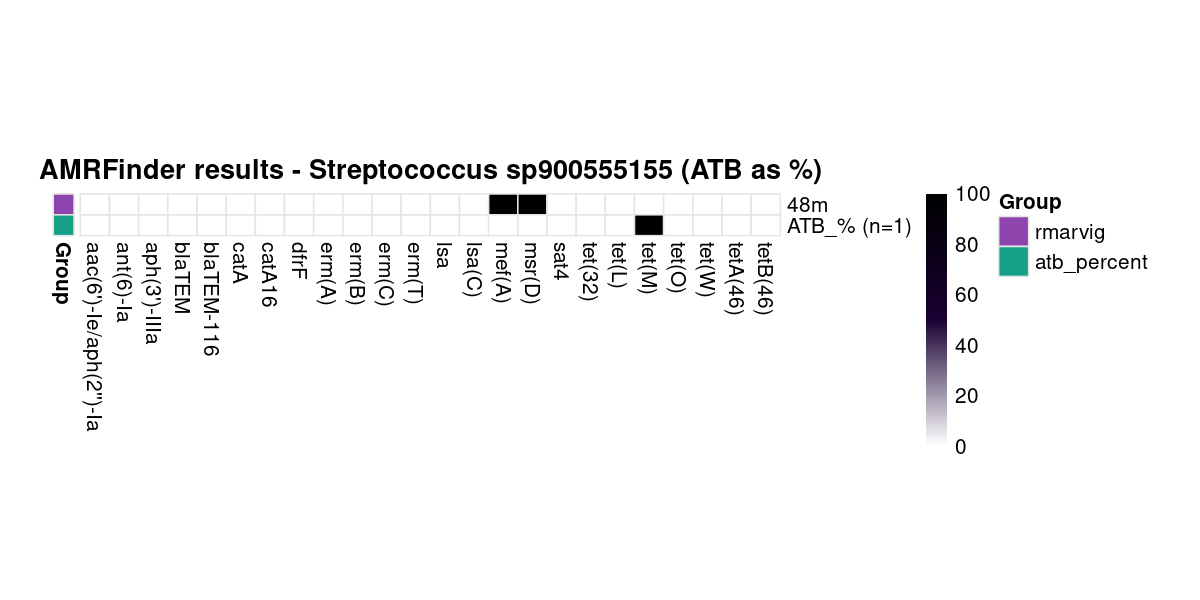

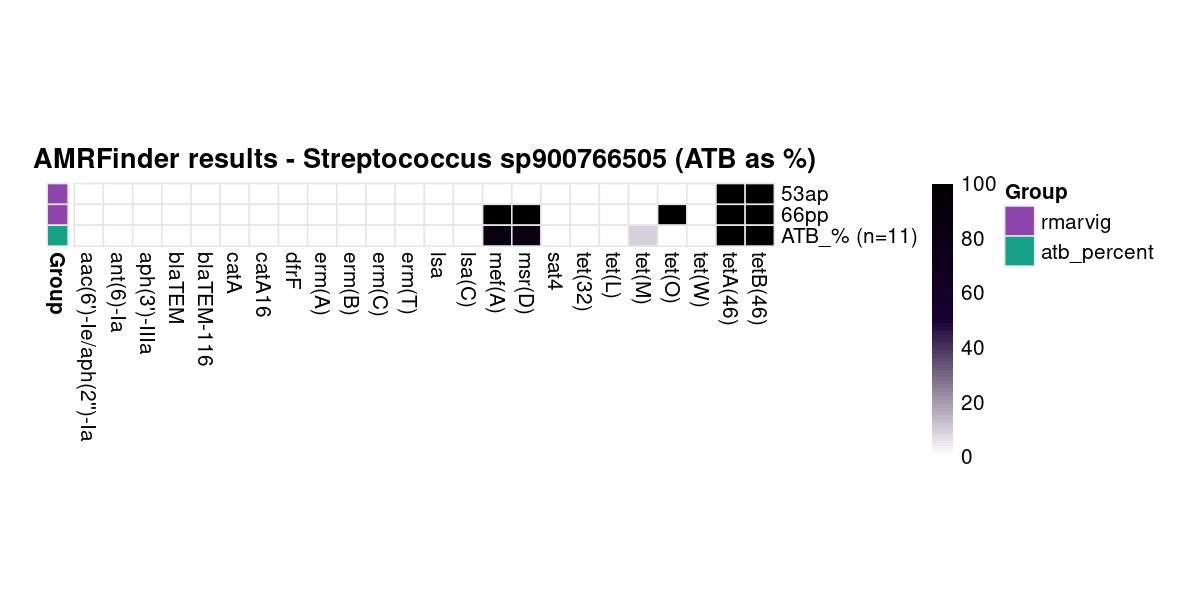

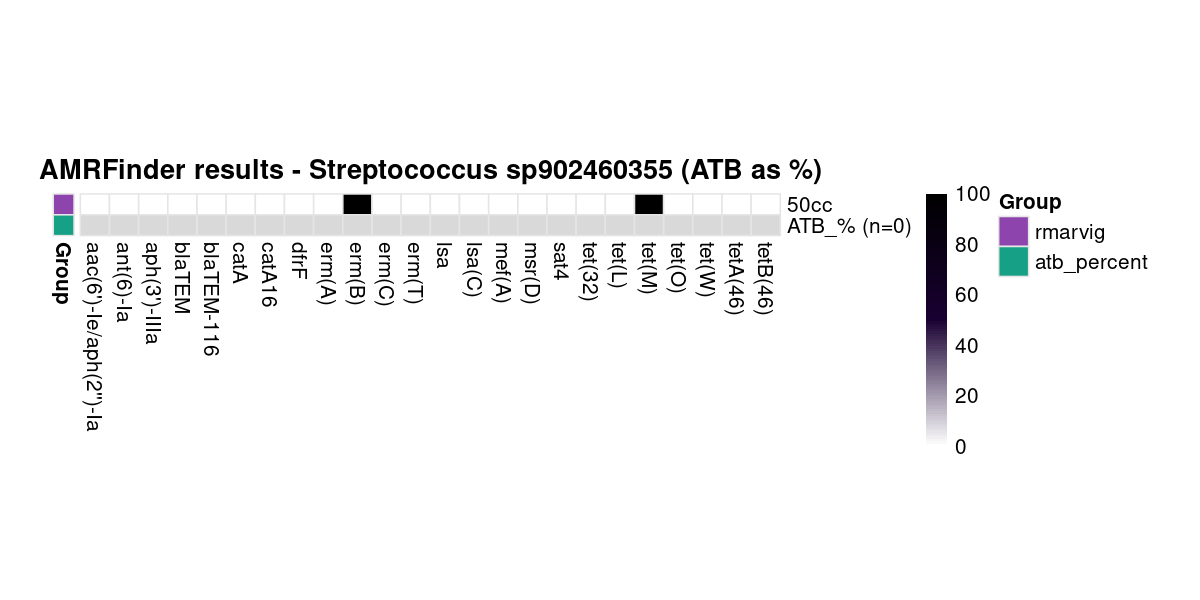

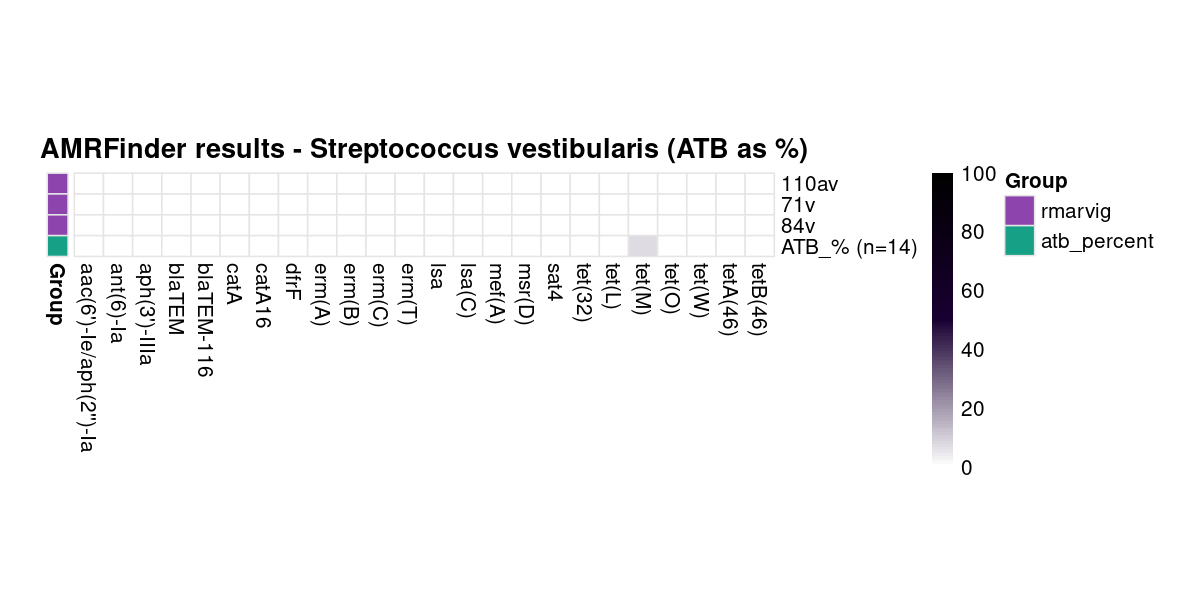

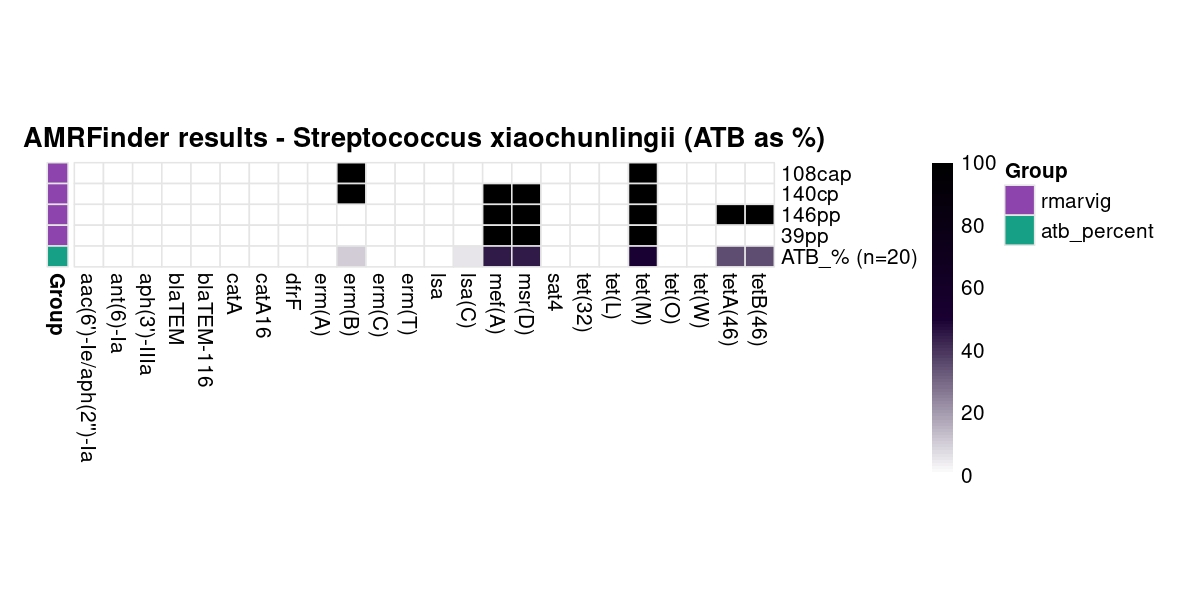

In [ ]:
options(
  repr.plot.width = 8,
  repr.plot.height = 4
)

# AMRFinder-only: one global gene order for all species
global_gene_universe <- combined_amr |>
  purrr::map(~ .x$element_symbol) |>
  unlist(use.names = FALSE) |>
  as.character() |>
  unique()

global_gene_universe <- global_gene_universe[!is.na(global_gene_universe) & global_gene_universe != ""]
global_gene_universe <- sort(global_gene_universe)

plot_species_heatmap_amr_only <- function(
  sp,
  combined_amr,
  gene_universe,
  fixed_cellwidth = 18,
  fixed_cellheight = 12
) {
  df <- combined_amr[[sp]]
  if (is.null(df) || nrow(df) == 0) stop(paste("No data for species:", sp))

  df <- df |>
    filter(!is.na(sample), sample != "") |>
    mutate(sample_id = as.character(sample))

  r_samples <- df |> filter(source == "rmarvig") |> pull(sample_id) |> unique()
  a_samples <- df |> filter(source == "atb")     |> pull(sample_id) |> unique()

  build_pa <- function(d, sample_ids, genes) {
    m <- matrix(0L, nrow = length(sample_ids), ncol = length(genes),
                dimnames = list(sample_ids, genes))
    hits <- d |>
      filter(!is.na(element_symbol), element_symbol != "") |>
      distinct(sample_id, gene = element_symbol)

    if (nrow(hits) > 0 && length(sample_ids) > 0) {
      rr <- match(hits$sample_id, sample_ids)
      cc <- match(hits$gene, genes)
      keep <- !is.na(rr) & !is.na(cc)
      if (any(keep)) m[cbind(rr[keep], cc[keep])] <- 1L
    }
    m
  }

  # rmarvig rows: binary presence shown as 0/100
  r_df <- df |> filter(source == "rmarvig")
  r_mat <- build_pa(r_df, r_samples, gene_universe) * 100
  if (nrow(r_mat) > 0) {
    rownames(r_mat) <- clean_id(rownames(r_mat))
    r_mat <- r_mat[order(rownames(r_mat)), , drop = FALSE]
  }

  # ATB single row: percent prevalence per gene
  a_df <- df |> filter(source == "atb")
  if (length(a_samples) > 0) {
    a_mat <- build_pa(a_df, a_samples, gene_universe)
    atb_pct <- colMeans(a_mat) * 100
  } else {
    atb_pct <- rep(NA_real_, length(gene_universe))
  }

  atb_rowname <- paste0("ATB_% (n=", length(a_samples), ")")
  atb_mat <- matrix(atb_pct, nrow = 1, dimnames = list(atb_rowname, gene_universe))

  hm <- rbind(r_mat, atb_mat)

  ann_row <- data.frame(
    Group = c(rep("rmarvig", nrow(r_mat)), "atb_percent"),
    row.names = rownames(hm)
  )

  pheatmap::pheatmap(
    hm,
    cluster_rows = FALSE,
    cluster_cols = FALSE,  # fixed gene order across species
    border_color = "grey90",
    cellwidth = fixed_cellwidth,
    cellheight = fixed_cellheight,
    fontsize_row = 10,
    fontsize_col = 10,
    angle_col = 270,
    annotation_row = ann_row,
    annotation_colors = list(Group = c(rmarvig = "#8E44AD", atb_percent = "#16A085")),
    color = colorRampPalette(c("white", "#1a0133", "black"))(101),
    breaks = seq(0, 100, length.out = 102),
    na_col = "grey85",
    main = paste("AMRFinder results - Streptococcus", sp, "(ATB as %)")
  )
}

# AMRFinder species only
species <- sort(names(combined_amr))

for (sp in species) {

  tryCatch(
    plot_species_heatmap_amr_only(
      sp = sp,
      combined_amr = combined_amr,
      gene_universe = global_gene_universe,
      fixed_cellwidth = 14,
      fixed_cellheight = 10
    ),
    error = function(e) message("Skipped ", sp, ": ", e$message)
  )
}


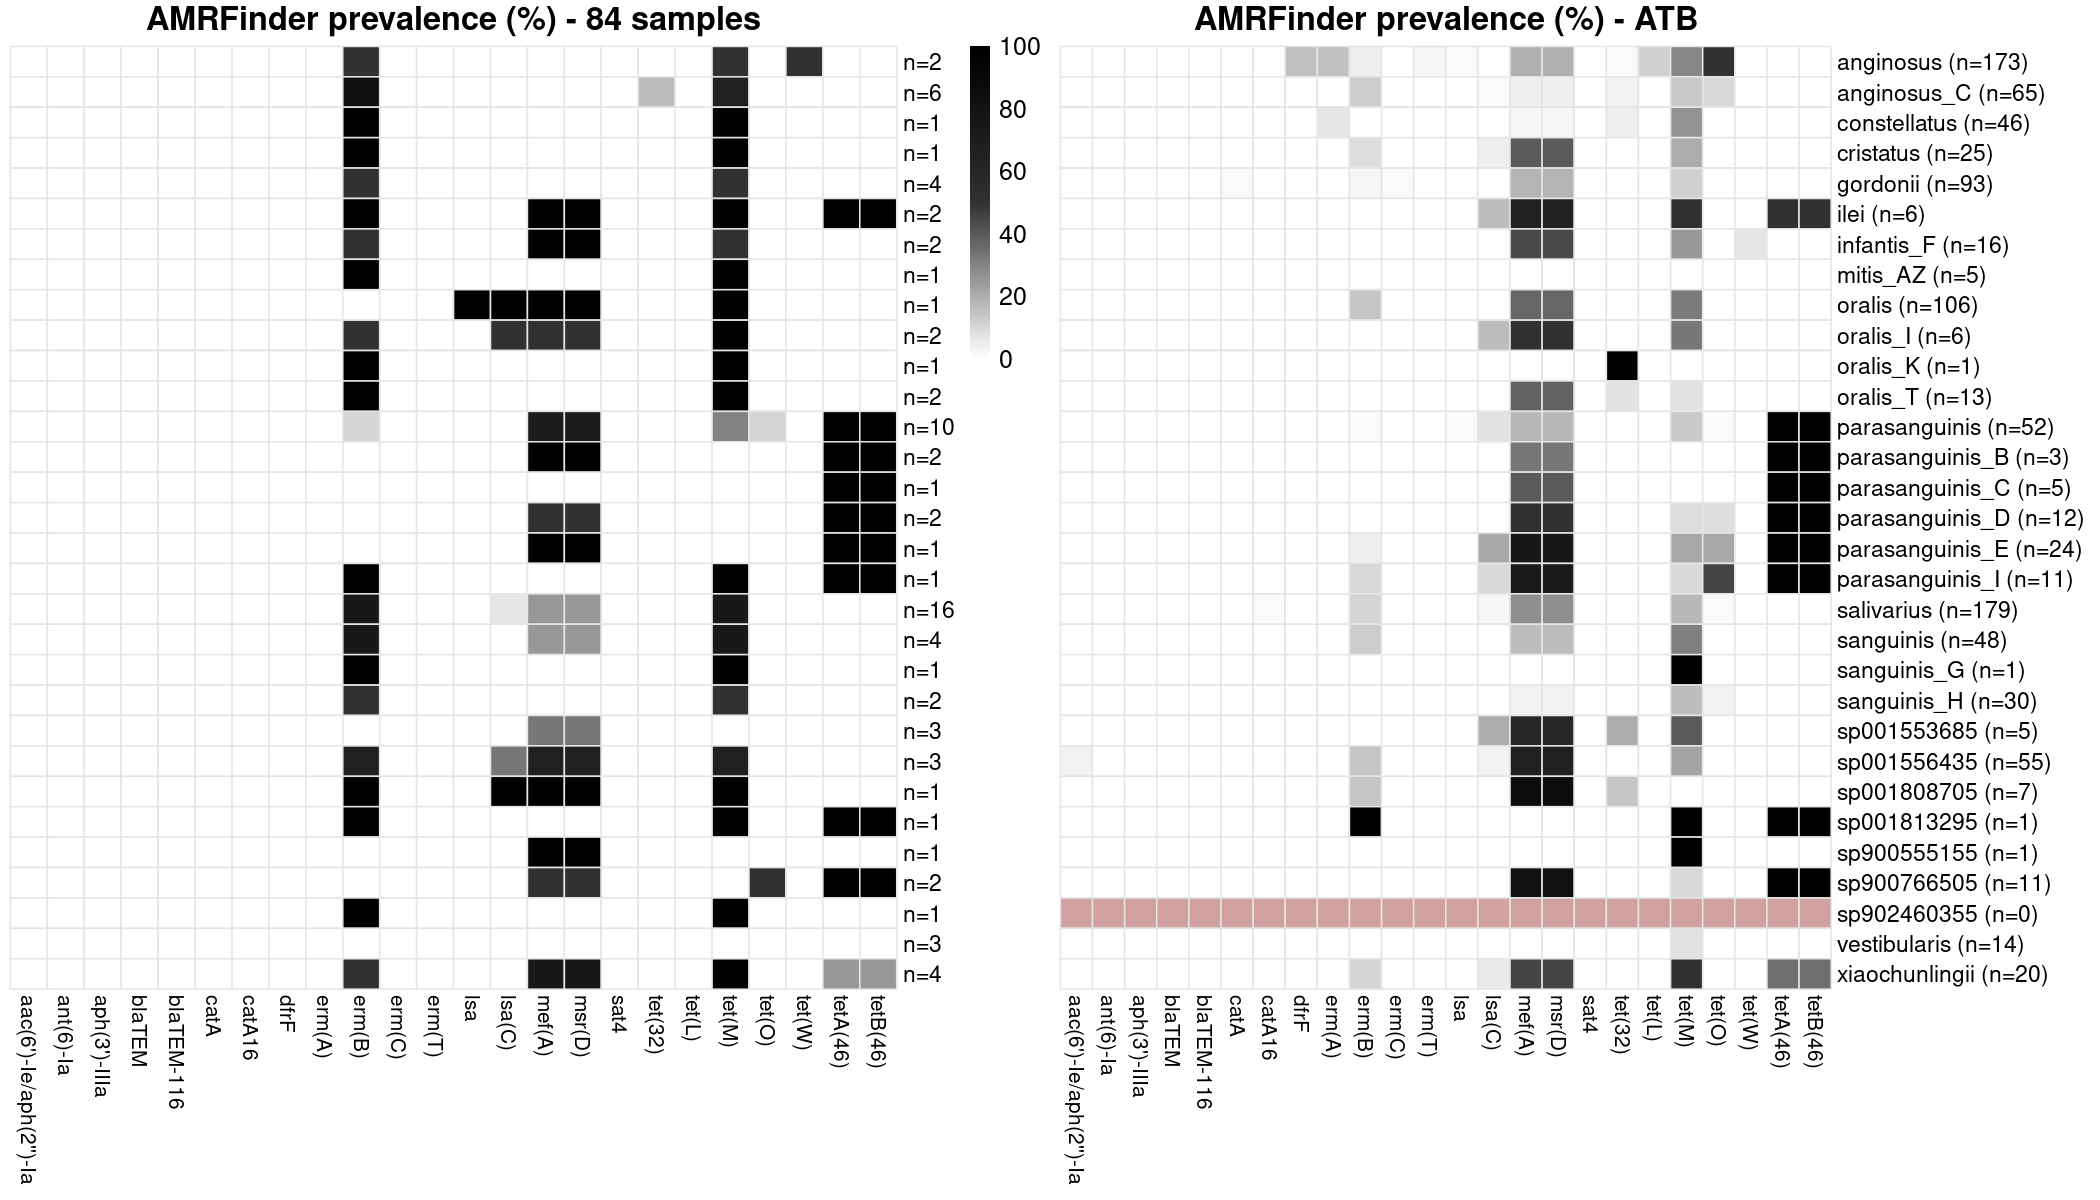

In [ ]:
build_species_pct_matrix <- function(combined_amr, gene_universe, source_keep = c("rmarvig", "atb")) {
 
  build_pa <- function(d, sample_ids, genes) {
    m <- matrix(0L, nrow = length(sample_ids), ncol = length(genes),
                dimnames = list(sample_ids, genes))
    hits <- d |>
      filter(!is.na(element_symbol), element_symbol != "") |>
      distinct(sample_id, gene = element_symbol)

    if (nrow(hits) > 0 && length(sample_ids) > 0) {
      rr <- match(hits$sample_id, sample_ids)
      cc <- match(hits$gene, genes)
      keep <- !is.na(rr) & !is.na(cc)
      if (any(keep)) m[cbind(rr[keep], cc[keep])] <- 1L
    }
    m
  }

  species <- sort(names(combined_amr))

  out <- purrr::map(species, function(sp) {
    df <- combined_amr[[sp]] |>
      filter(source %in% source_keep, !is.na(sample), sample != "") |>
      mutate(sample_id = as.character(sample))

    sids <- unique(df$sample_id)
    pct <- if (length(sids) == 0) rep(NA_real_, length(gene_universe)) else colMeans(build_pa(df, sids, gene_universe)) * 100
    list(
      sp = sp,
      n = length(sids),
      row = matrix(pct, nrow = 1, dimnames = list(sp, gene_universe))
    )
  })

  mat <- do.call(rbind, purrr::map(out, "row"))
  n_tbl <- tibble::tibble(species = purrr::map_chr(out, "sp"), n = purrr::map_int(out, "n"))
  list(mat = mat, n_tbl = n_tbl)
}

my_obj  <- build_species_pct_matrix(combined_amr, global_gene_universe, source_keep = "rmarvig")
atb_obj <- build_species_pct_matrix(combined_amr, global_gene_universe, source_keep = "atb")

hm_my  <- my_obj$mat
hm_atb <- atb_obj$mat

# align by species names 
common_species <- intersect(rownames(hm_my), rownames(hm_atb))
hm_my  <- hm_my[common_species, , drop = FALSE]
hm_atb <- hm_atb[common_species, colnames(hm_my), drop = FALSE]

lab_my  <- paste0(common_species, " (n=", my_obj$n_tbl$n[match(common_species, my_obj$n_tbl$species)], ")")
lab_atb <- paste0(common_species, " (n=", atb_obj$n_tbl$n[match(common_species, atb_obj$n_tbl$species)], ")")

brks <- seq(0, 100, length.out = 102)
cols <- colorRampPalette(c("white", "#313131", "black"))(101)



# keep species names internally for alignment, but show only n on "your samples"
lab_my <- paste0("n=", my_obj$n_tbl$n[match(common_species, my_obj$n_tbl$species)])

# keep ATB labels 
lab_atb <- paste0(common_species, " (n=", atb_obj$n_tbl$n[match(common_species, atb_obj$n_tbl$species)], ")")

p1 <- pheatmap(
  hm_my,
  labels_row = lab_my,
  cluster_rows = FALSE, cluster_cols = FALSE,
  color = cols, breaks = brks, na_col = "#d1a0a0",
  border_color = "grey90", angle_col = 270,
  fontsize = 12,
  fontsize_row = 11,
  fontsize_col = 10,
  main = "AMRFinder prevalence (%) - 84 samples",
  silent = TRUE
)

p2 <- pheatmap(
  hm_atb,
  labels_row = lab_atb,
  cluster_rows = FALSE, cluster_cols = FALSE,
  color = cols, breaks = brks, na_col = "#d1a0a0",
  border_color = "grey90", angle_col = 270,
  fontsize = 12,
  fontsize_row = 11,
  fontsize_col = 10,
  main = "AMRFinder prevalence (%) - ATB",
  legend = FALSE,
  silent = TRUE
)

options(
  repr.plot.width = 14,
  repr.plot.height = 8
)

gridExtra::grid.arrange(p1$gtable, p2$gtable, ncol = 2, widths = c(1, 1))



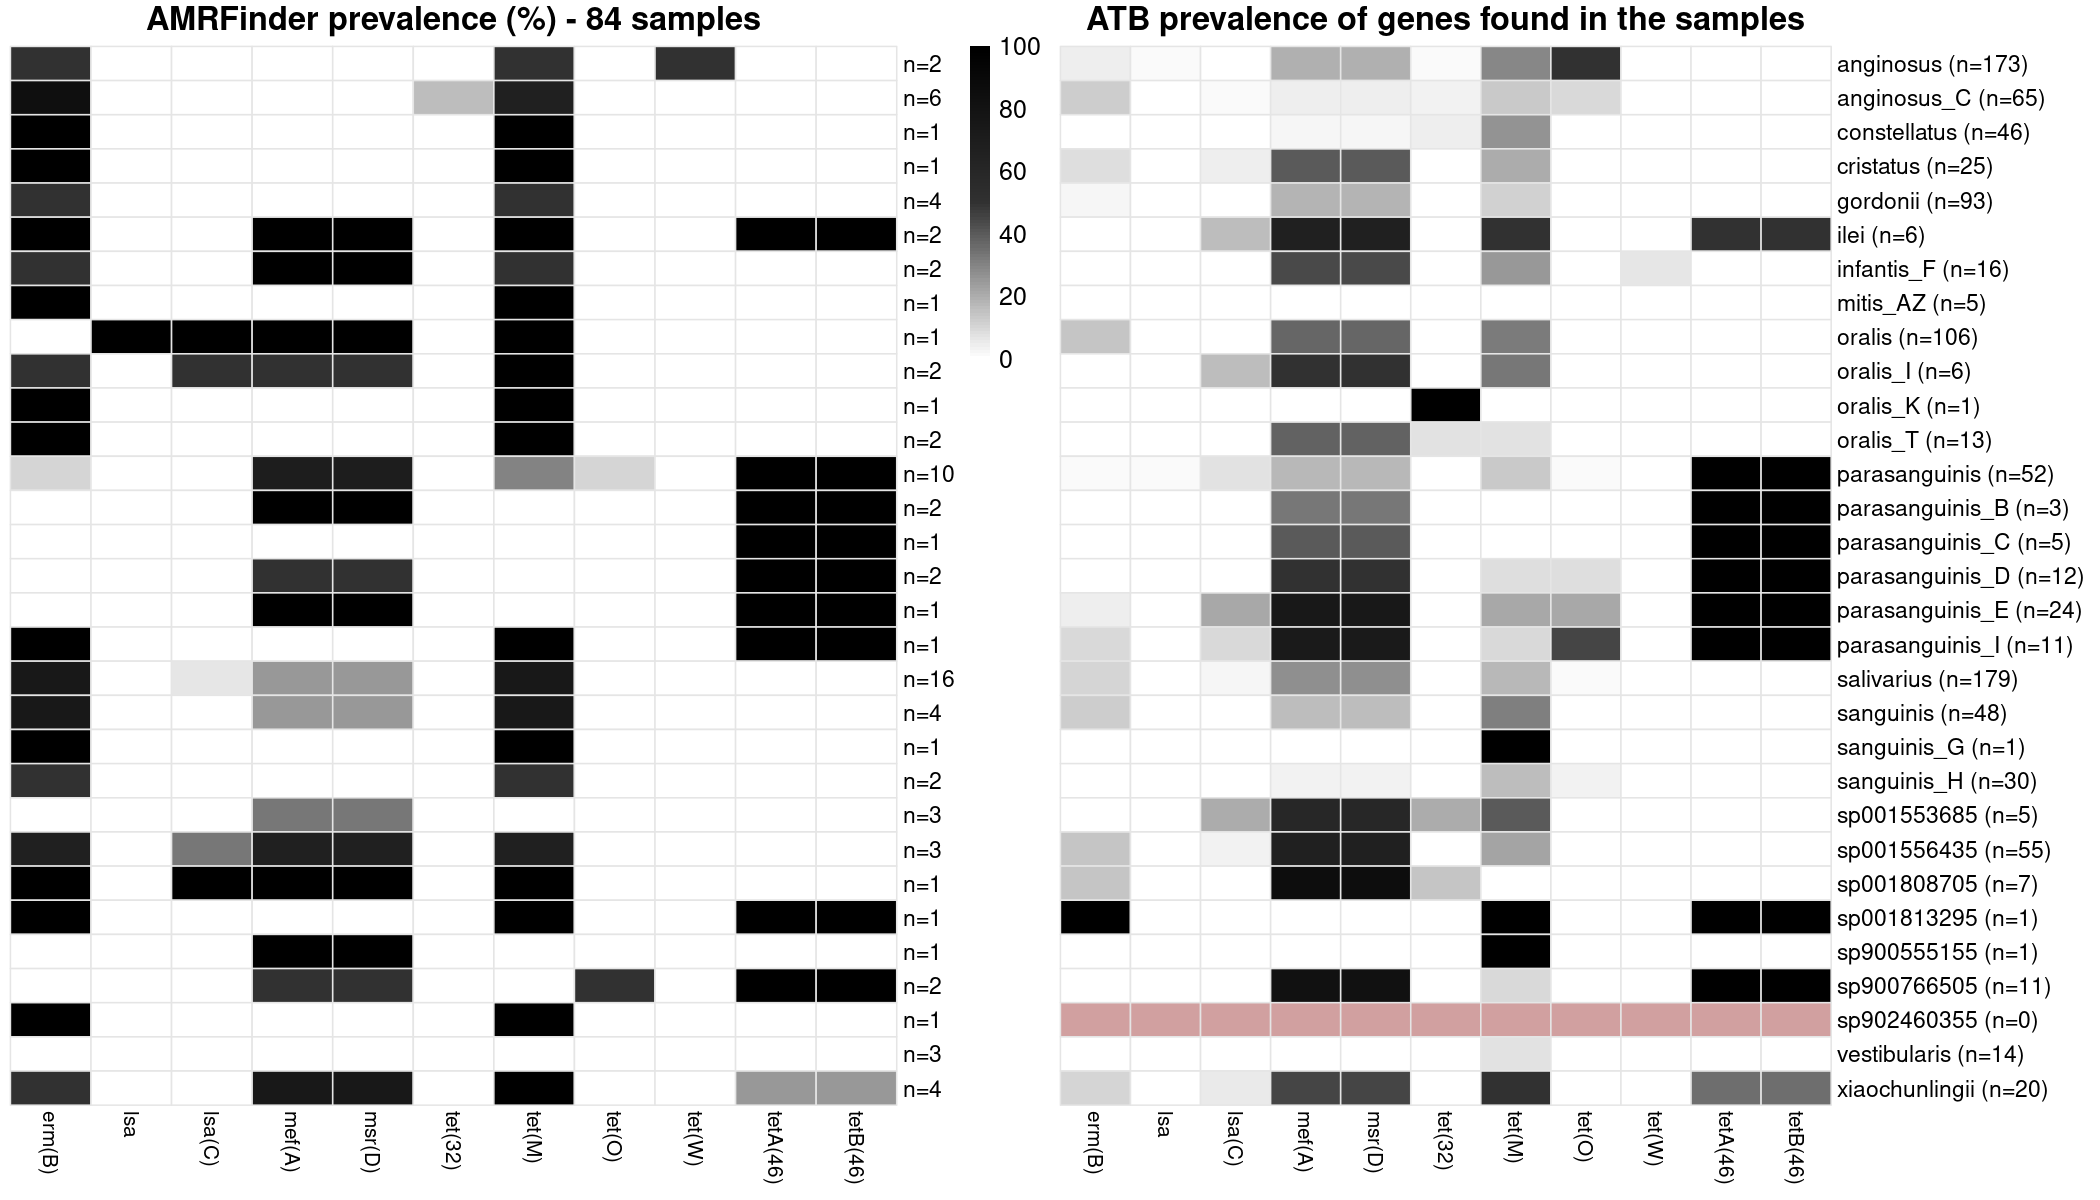

In [ ]:
# genes found in our samples only
gene_universe_my_only <- combined_amr |>
  purrr::map(~ filter(.x, source == "rmarvig")$element_symbol) |>
  unlist(use.names = FALSE) |>
  as.character() |>
  unique()

gene_universe_my_only <- gene_universe_my_only[
  !is.na(gene_universe_my_only) & gene_universe_my_only != ""
]

gene_universe_my_only <- sort(gene_universe_my_only)

my_obj_only  <- build_species_pct_matrix(
  combined_amr,
  gene_universe_my_only,
  source_keep = "rmarvig"
)

atb_obj_only <- build_species_pct_matrix(
  combined_amr,
  gene_universe_my_only,
  source_keep = "atb"
)

hm_my_only  <- my_obj_only$mat
hm_atb_only <- atb_obj_only$mat

common_species <- intersect(rownames(hm_my_only), rownames(hm_atb_only))
hm_my_only  <- hm_my_only[common_species, , drop = FALSE]
hm_atb_only <- hm_atb_only[common_species, colnames(hm_my_only), drop = FALSE]

lab_my_only  <- paste0("n=", my_obj_only$n_tbl$n[match(common_species, my_obj_only$n_tbl$species)])
lab_atb_only <- paste0(common_species, " (n=", atb_obj_only$n_tbl$n[match(common_species, atb_obj_only$n_tbl$species)], ")")

brks <- seq(0, 100, length.out = 102)
cols <- colorRampPalette(c("white", "#313131", "black"))(101)

p1_only <- pheatmap::pheatmap(
  hm_my_only,
  labels_row = lab_my_only,
  cluster_rows = FALSE, cluster_cols = FALSE,
  color = cols, breaks = brks, na_col = "#d1a0a0",
  border_color = "grey90", angle_col = 270,
  fontsize = 12,
  fontsize_row = 11,
  fontsize_col = 10,
  main = "AMRFinder prevalence (%) - 84 samples",
  silent = TRUE
)

p2_only <- pheatmap::pheatmap(
  hm_atb_only,
  labels_row = lab_atb_only,
  cluster_rows = FALSE, cluster_cols = FALSE,
  color = cols, breaks = brks, na_col = "#d1a0a0",
  border_color = "grey90", angle_col = 270,
  fontsize = 12,
  fontsize_row = 11,
  fontsize_col = 10,
  main = "ATB prevalence of genes found in the samples",
  legend = FALSE,
  silent = TRUE
)

gridExtra::grid.arrange(p1_only$gtable, p2_only$gtable, ncol = 2, widths = c(1, 1))

In [ ]:


maldi_colors <- c(
    "anginosus"     = "#B8E0B8",  # pastel green
    "constellatus"  = "#B8D4C8",  # pastel teal-green — anginosus group
    "salivarius"    = "#f7f293",  # pastel yellow
    "vestibularis"  = "#fedc93",  # pastel peach-yellow — salivarius group
    "mitis oralis"  = "#B8D4F0",  # pastel blue
    "infantis"      = "#CCB8F0",  # pastel lavender — M-clade with mitis
    "sanguinis"     = "#FFB8C8",  # pastel pink
    "gordonii"      = "#E8B8E8",  # pastel purple
    "parasanguinis" = "#fbb98c",  # pastel orange
    "cristatus"     = "#B8EEE8"   # pastel teal
)

gtdb_colors <- c(
    # anginosus — brighter greens
    "anginosus"      = "#2E8B2E",  # bright green
    "anginosus_C"    = "#52B052",  # mid green

    # constellatus — brighter teal-green (anginosus group)
    "constellatus"   = "#2E7A5A",  # bright teal-green

    # salivarius — brighter yellows
    "salivarius"     = "#E8D800",  # bright yellow
    "sp001556435"    = "#C8B800",  # deeper yellow — related to salivarius
    "infantis_F"     = "#D4C400",  # gold-yellow — GTDB groups with salivarius

    # vestibularis — brighter peach-yellows (salivarius group)
    "vestibularis"   = "#FFB300",  # bright amber

    # mitis oralis — brighter blues (M-clade)
    "oralis"         = "#1E7EC8",  # bright blue
    "oralis_I"       = "#1A6AAA",  # slightly darker blue
    "oralis_K"       = "#1458A0",  # deeper blue
    "oralis_T"       = "#3D8FD4",  # lighter bright blue
    "mitis_AZ"       = "#0D4F8C",  # dark blue
    "ilei"           = "#0A3D6E",  # navy — mitis group
    "sp001553685"    = "#2E5FA8",  # indigo-blue — mitis group
    "sp001808705"    = "#4A78C0",  # lighter indigo — mitis group

    # infantis — brighter purples (M-clade with mitis/oralis)
    #"infantis_F"     = "#7B4EC8",  # bright purple
    # note: infantis_F is in salivarius group per GTDB — kept both options,
    # use whichever matches your actual tree clustering

    # sanguinis — brighter pinks
    "sanguinis"      = "#E81050",  # bright pink-red
    "sanguinis_G"    = "#CC0D44",  # darker pink-red
    "sanguinis_H"    = "#FF3D6E",  # lighter bright pink

    # gordonii — brighter purples
    "gordonii"       = "#A020C8",  # bright purple
    "sp902460355"    = "#8818A8",  # deeper purple — related to gordonii

    # parasanguinis — brighter oranges (S-clade)
    "parasanguinis"   = "#FF6A00",  # bright orange
    "parasanguinis_B" = "#E85A00",  # slightly deeper orange
    "parasanguinis_C" = "#FF8C00",  # lighter orange
    "parasanguinis_D" = "#CC5500",  # darker orange
    "parasanguinis_E" = "#FF4500",  # red-orange
    "parasanguinis_I" = "#B83C00",  # dark red-orange
    "xiaochunlingii"  = "#FFA040",  # pale bright orange — related to parasanguinis
    "sp900766505"     = "#FF7820",  # mid orange
    "sp001813295"     = "#FF9050",  # light orange
    

    # cristatus — brighter teals (S-clade)
    "cristatus"      = "#00A896",  # bright teal

    # no species / unresolved — greys
    "no species"     = "#AAAAAA",
    "sp900555155"    = "#888888"
    
)


# legend order
maldi_order <- c(
    "anginosus",
    "constellatus",
    "salivarius",
    "vestibularis",
    "mitis oralis",
    "infantis",
    "sanguinis",
    "gordonii",
    "parasanguinis",
    "cristatus"
)

gtdb_order <- c(
    # anginosus group
    "anginosus",
    "anginosus_C",
    # constellatus group
    "constellatus",
    # salivarius group
    "salivarius",
    "sp001556435",
    "infantis_F",
    # vestibularis
    "vestibularis",
    # mitis oralis M-clade
    "oralis",
    "oralis_I",
    "oralis_K",
    "oralis_T",
    "mitis_AZ",
    "ilei",
    "sp001553685",
    "sp001808705",
    # sanguinis
    "sanguinis",
    "sanguinis_G",
    "sanguinis_H",
    # gordonii
    "gordonii",
    "sp902460355",
    # parasanguinis
    "parasanguinis",
    "parasanguinis_B",
    "parasanguinis_C",
    "parasanguinis_D",
    "parasanguinis_E",
    "parasanguinis_I",
    "xiaochunlingii",
    "sp900766505",
    "sp001813295",
    # cristatus
    "cristatus",
    # unresolved
    "no species",
    "sp900555155"
)




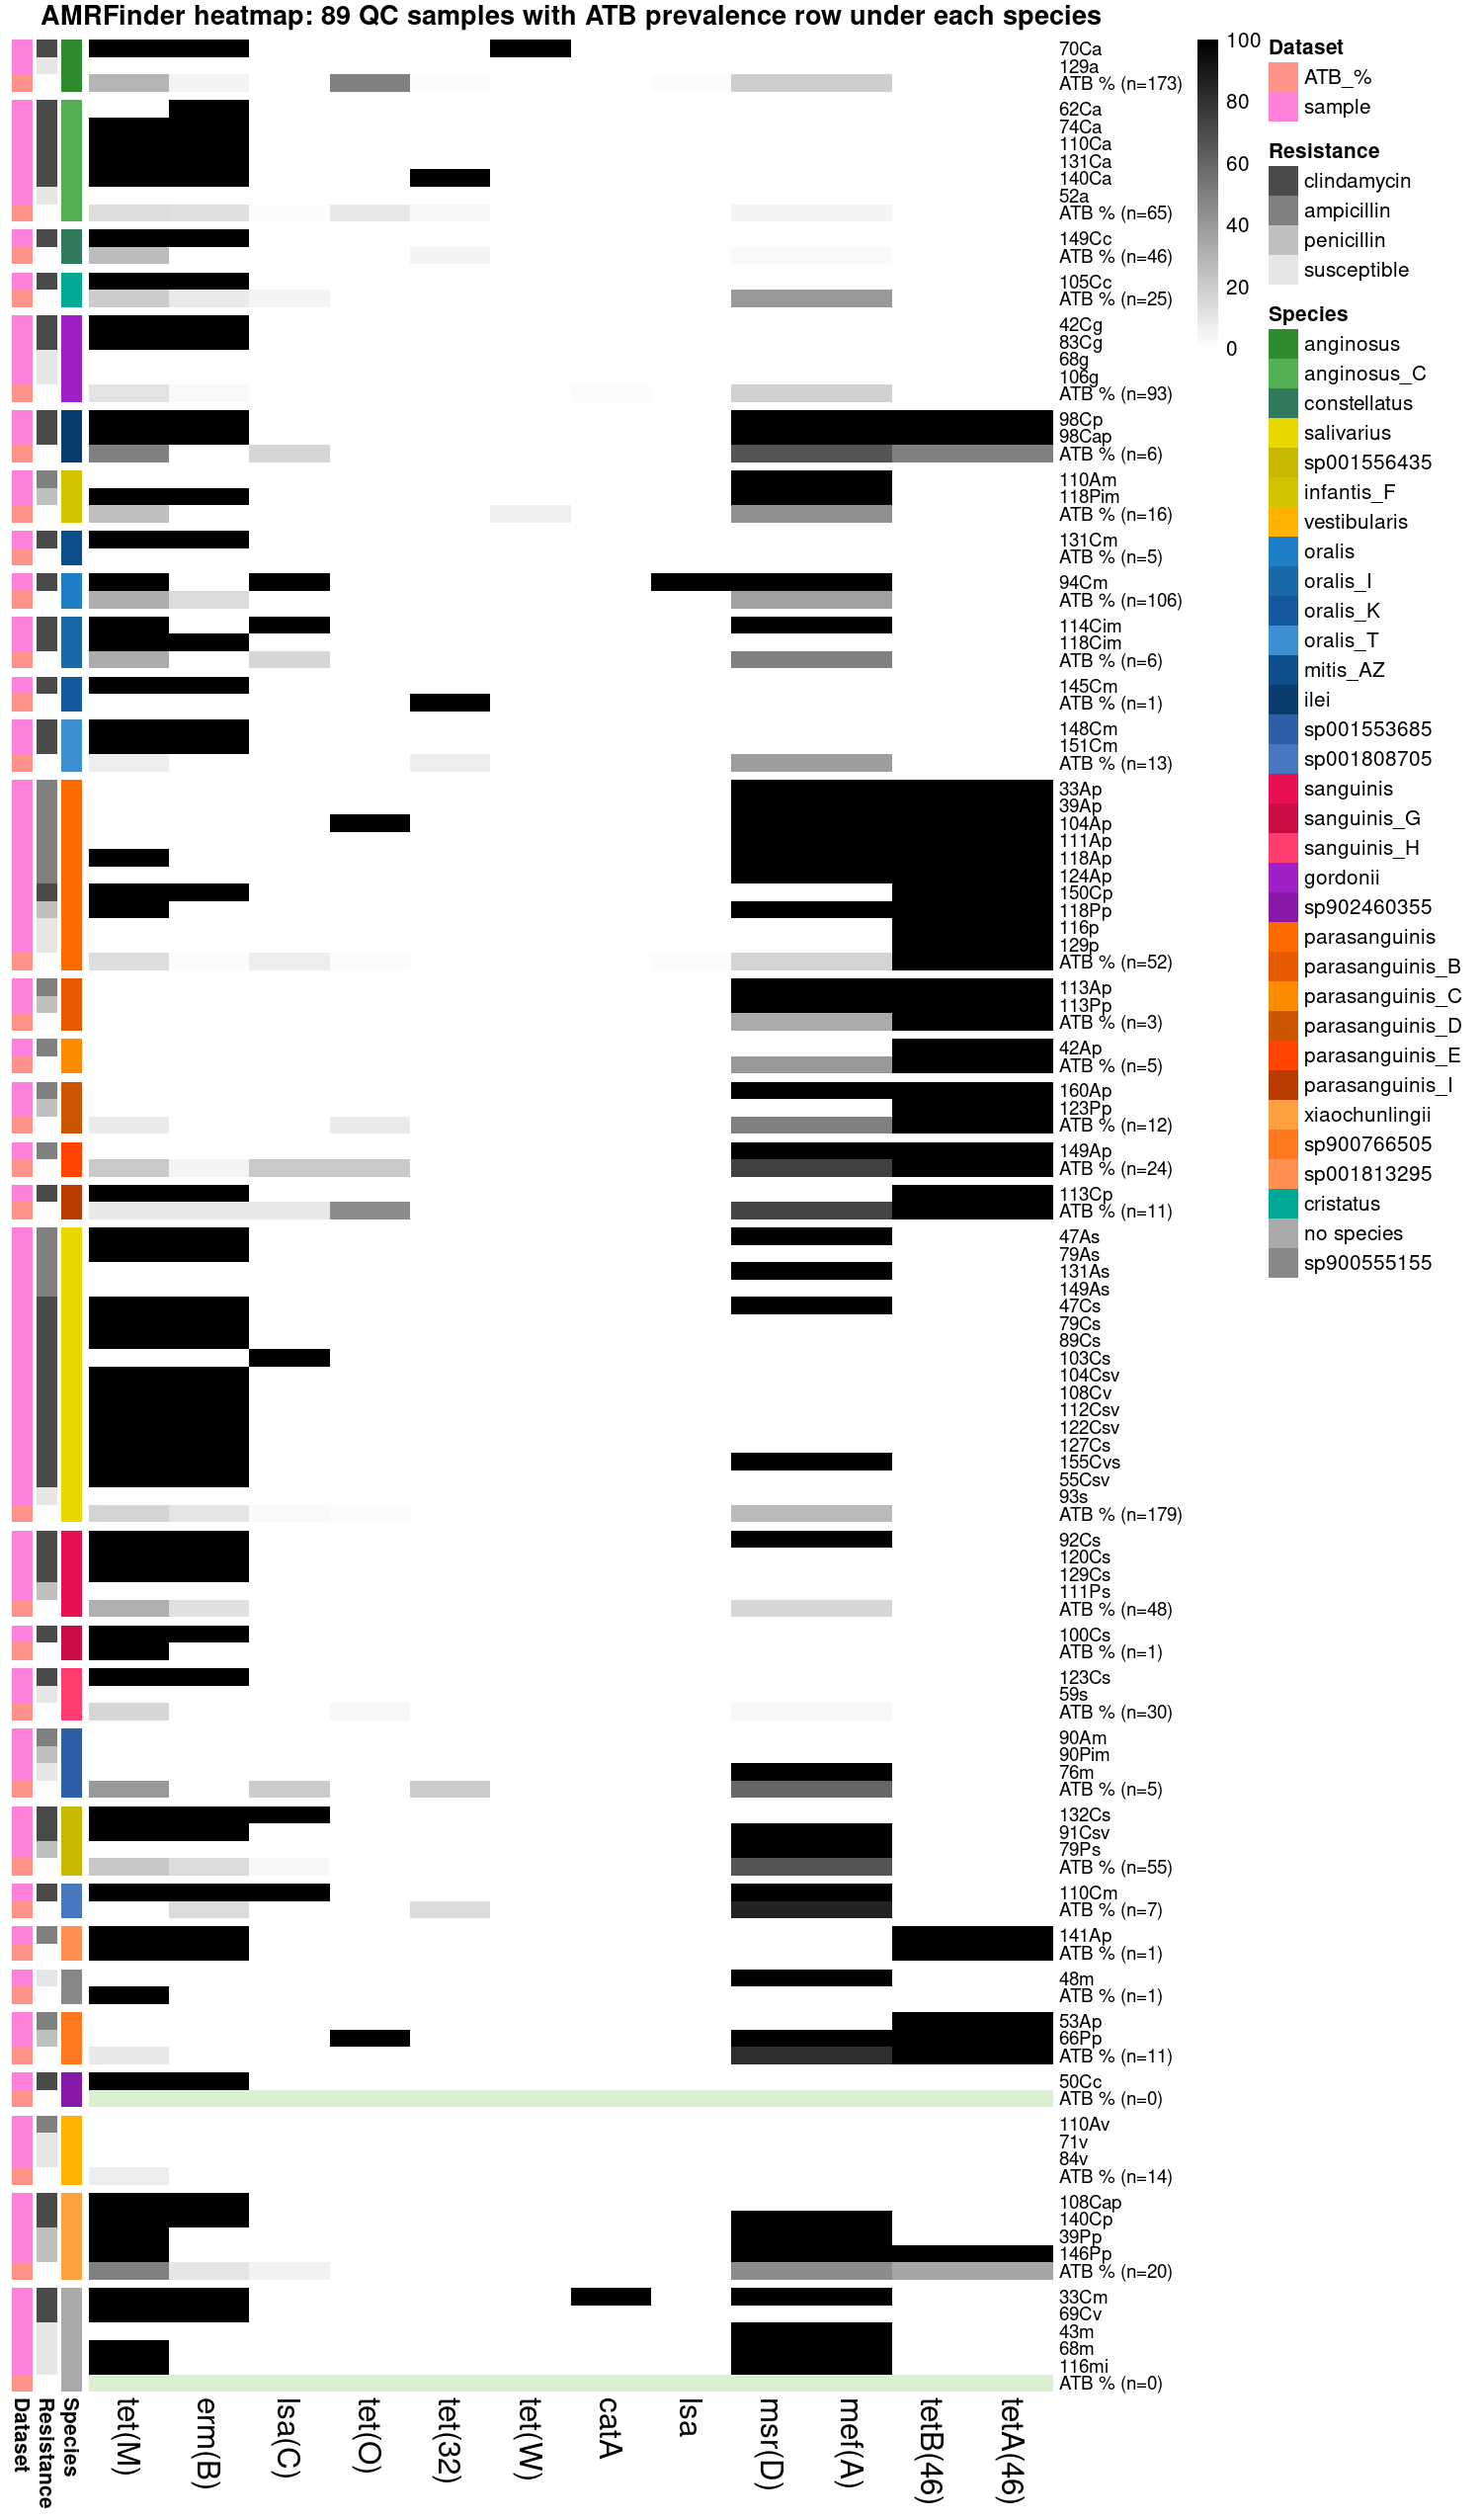

In [ ]:


options(repr.plot.width = 10, repr.plot.height = 17, repr.plot.res = 150)

# rebuild the sample heatmap matrix, but keep all 89 QC-filtered samples
annot <- species_df |>
  select(SAMPLE_ID, GTDB_214) |>
  left_join(df_filtered |> select(SAMPLE_ID, Resistance), by = "SAMPLE_ID") |>
  transmute(
    SAMPLE_ID,
    Species = dplyr::coalesce(GTDB_214, "no species"),
    Resistance = dplyr::coalesce(Resistance, "susceptible")
  ) |>
  distinct(SAMPLE_ID, .keep_all = TRUE)

all_sample_ids <- annot$SAMPLE_ID

pa_data_amr <- amr_clean |>
  filter(!is.na(element_symbol)) |>
  mutate(sample_short = sub("-.*", "", sample) |> sub("^0+", "", x = _)) |>
  distinct(sample_short, element_symbol) |>
  mutate(present = 1L) |>
  pivot_wider(names_from = element_symbol, values_from = present, values_fill = 0L)

pa_data_amr <- tibble(sample_short = all_sample_ids) |>
  left_join(pa_data_amr, by = "sample_short") |>
  mutate(across(-sample_short, ~replace_na(as.integer(.x), 0L)))

pa_mat_amr <- pa_data_amr |>
  column_to_rownames("sample_short") |>
  as.matrix()

annot_sorted_amr <- annot |>
  filter(SAMPLE_ID %in% rownames(pa_mat_amr)) |>
  arrange(
    Species == "no species",
    Species,
    Resistance
  ) |>
  column_to_rownames("SAMPLE_ID")

annot_sorted_clean_amr <- annot_sorted_amr |>
  mutate(
    Resistance = stringr::str_remove(Resistance, "_resistant") |> stringr::str_to_lower()
  )

sorted_order_amr <- rownames(annot_sorted_clean_amr)
pa_mat_amr <- pa_mat_amr[sorted_order_amr, , drop = FALSE]

# convert sample rows to 0/100 so they can share a color scale with ATB percentages
sample_mat_100 <- pa_mat_amr * 100

# helper: ATB prevalence row for one species, using the same genes/order as the sample heatmap
build_atb_pct_row <- function(sp, genes, atb_amr_list) {
  if (!(sp %in% names(atb_amr_list))) {
    return(list(values = rep(NA_real_, length(genes)), n = 0L))
  }

  df <- atb_amr_list[[sp]]$data |>
    dplyr::filter(!is.na(sample), sample != "") |>
    dplyr::mutate(sample_id = as.character(sample))

  sample_ids <- unique(df$sample_id)

  if (length(sample_ids) == 0) {
    return(list(values = rep(NA_real_, length(genes)), n = 0L))
  }

  m <- matrix(
    0L,
    nrow = length(sample_ids),
    ncol = length(genes),
    dimnames = list(sample_ids, genes)
  )

  hits <- df |>
    dplyr::filter(!is.na(element_symbol), element_symbol != "") |>
    dplyr::distinct(sample_id, gene = element_symbol)

  rr <- match(hits$sample_id, sample_ids)
  cc <- match(hits$gene, genes)
  keep <- !is.na(rr) & !is.na(cc)

  if (any(keep)) {
    m[cbind(rr[keep], cc[keep])] <- 1L
  }

  list(values = colMeans(m) * 100, n = length(sample_ids))
}

species_order <- unique(annot_sorted_clean_amr$Species)
genes_order <- colnames(sample_mat_100)


hm_parts <- list()
ann_parts <- list()
group_sizes <- integer(length(species_order))
row_labels <- character()

for (i in seq_along(species_order)) {
  sp <- species_order[i]

  sample_rows_sp <- rownames(annot_sorted_clean_amr)[annot_sorted_clean_amr$Species == sp]

  # sample rows
  hm_parts[[length(hm_parts) + 1]] <- sample_mat_100[sample_rows_sp, , drop = FALSE]

  ann_parts[[length(ann_parts) + 1]] <- annot_sorted_clean_amr[sample_rows_sp, , drop = FALSE] |>
    mutate(Dataset = "sample")

  row_labels <- c(row_labels, sample_rows_sp)

  # ATB % row
  atb_info <- build_atb_pct_row(sp, genes_order, atb_amr_list)

  atb_row_id <- paste0("__ATB__", sp)                # unique internal row name
  atb_row_lab <- paste0("ATB % (n=", atb_info$n, ")")  # displayed label

  atb_row <- matrix(
    atb_info$values,
    nrow = 1,
    dimnames = list(atb_row_id, genes_order)
  )

  hm_parts[[length(hm_parts) + 1]] <- atb_row

  ann_parts[[length(ann_parts) + 1]] <- data.frame(
    Species = sp,
    Resistance = NA_character_,
    Dataset = "ATB_%",
    row.names = atb_row_id
  )

  row_labels <- c(row_labels, atb_row_lab)

  group_sizes[i] <- length(sample_rows_sp) + 1L
}

hm_combined <- do.call(rbind, hm_parts)
ann_combined <- do.call(rbind, ann_parts)

gaps_combined <- cumsum(group_sizes)
gaps_combined <- gaps_combined[-length(gaps_combined)]

resist_cols <- c(
  "clindamycin" = "#4A4A4A",
  "ampicillin"  = "#808080",
  "penicillin"  = "#BFBFBF",
  "susceptible" = "#E6E6E6"   # missing level
)

ann_colors <- list(
  Species    = gtdb_colors,
  Resistance = resist_cols
)

pheatmap::pheatmap(
  hm_combined,
  labels_row        = row_labels,
  annotation_row    = ann_combined,
  annotation_colors = ann_colors,
  cluster_rows      = FALSE,
  cluster_cols      = TRUE,
  treeheight_col    = 0,
  gaps_row          = gaps_combined,
  border_color      = "black",
  color             = colorRampPalette(c("white", "#808080", "black"))(101),
  breaks            = seq(0, 100, length.out = 102),
  na_col            = "#d9f0d3",
  fontsize_row      = 9,
  fontsize_col      = 15,
  angle_col         = 270,
  main              = "AMRFinder heatmap: 89 QC samples with ATB prevalence row under each species"
)



pheatmap::pheatmap(
  hm_combined,
  labels_row        = row_labels,
  annotation_row    = ann_combined,
  annotation_colors = ann_colors,
  cluster_rows      = FALSE,
  cluster_cols      = TRUE,
  treeheight_col    = 0,
  gaps_row          = gaps_combined,
  border_color      = "grey85",
  cellwidth         = 20,
  cellheight        = 10,
  color             = colorRampPalette(c("white", "#808080", "black"))(101),
  breaks            = seq(0, 100, length.out = 102),
  na_col            = "#e8fff1",
  fontsize_row      = 8,
  fontsize_col      = 12,
  angle_col         = 270,
  filename          = "figures/amr_heatmap_borders.pdf",
  width             = 20,
  height            = 24,
  main              = "AMRFinder results: 89 QC samples + ATB gene prevalence in %"
)




In [ ]:

species_gene_tables <- purrr::map(combined_amr, function(df_sp) {
  df_sp <- df_sp |>
    mutate(
      sample_id = as.character(sample),
      gene = str_trim(element_symbol)
    ) |>
    filter(!is.na(sample_id), sample_id != "")

  n_rmarvig_total <- df_sp |>
    filter(source == "rmarvig") |>
    distinct(sample_id) |>
    nrow()

  n_atb_total <- df_sp |>
    filter(source == "atb") |>
    distinct(sample_id) |>
    nrow()

  hits <- df_sp |>
    filter(!is.na(gene), gene != "") |>
    distinct(source, sample_id, gene)

  counts <- hits |>
    count(gene, source, name = "n") |>
    pivot_wider(names_from = source, values_from = n, values_fill = 0)

  if (!"rmarvig" %in% names(counts)) counts$rmarvig <- 0L
  if (!"atb" %in% names(counts)) counts$atb <- 0L

  counts |>
    transmute(
      gene,
      `N genomes (rmarvig)` = as.integer(rmarvig),
      `Isolates prevalence % (rmarvig)` = if (n_rmarvig_total > 0) round(100 * rmarvig / n_rmarvig_total, 1) else NA_real_,
      `ATB prevalence %` = if (n_atb_total > 0) round(100 * atb / n_atb_total, 1) else NA_real_,
      `N genomes (atb)` = as.integer(atb)
    ) |>
    filter(`N genomes (rmarvig)` > 0, `N genomes (atb)` > 0) |>
    arrange(desc(`ATB prevalence %`), desc(`Isolates prevalence % (rmarvig)`), gene)
})

# optional compact per-species totals table
species_totals <- purrr::imap_dfr(combined_amr, function(df_sp, sp) {
  df_sp <- df_sp |>
    mutate(sample_id = as.character(sample)) |>
    filter(!is.na(sample_id), sample_id != "")

  tibble(
    species = sp,
    `N genomes total (rmarvig)` = df_sp |> filter(source == "rmarvig") |> distinct(sample_id) |> nrow(),
    `N genomes total (atb)` = df_sp |> filter(source == "atb") |> distinct(sample_id) |> nrow()
  )
}) |>
  arrange(species)

species_totals

species_gene_tables



species,N genomes total (rmarvig),N genomes total (atb)
<chr>,<int>,<int>
anginosus,2,173
anginosus_C,6,65
constellatus,1,46
cristatus,1,25
gordonii,4,93
ilei,2,6
infantis_F,2,16
mitis_AZ,1,5
oralis,1,106


gene,N genomes (rmarvig),Isolates prevalence % (rmarvig),ATB prevalence %,N genomes (atb)
<chr>,<int>,<dbl>,<dbl>,<int>
tet(M),1,50,28.9,50
erm(B),1,50,4.6,8
gene,N genomes (rmarvig),Isolates prevalence % (rmarvig),ATB prevalence %,N genomes (atb)
<chr>,<int>,<dbl>,<dbl>,<int>
tet(M),4,66.7,13.8,9
erm(B),5,83.3,12.3,8
tet(32),1,16.7,3.1,2
gene,N genomes (rmarvig),Isolates prevalence % (rmarvig),ATB prevalence %,N genomes (atb)
<chr>,<int>,<dbl>,<dbl>,<int>


In [ ]:


species_gene_tables <- purrr::map_dfr(names(combined_amr), function(sp) {
  df_sp <- combined_amr[[sp]] |>
    mutate(
      sample_id = as.character(sample),
      gene = str_trim(element_symbol)
    ) |>
    filter(!is.na(sample_id), sample_id != "")

  n_rmarvig_total <- df_sp |>
    filter(source == "rmarvig") |>
    distinct(sample_id) |>
    nrow()

  n_atb_total <- df_sp |>
    filter(source == "atb") |>
    distinct(sample_id) |>
    nrow()

  hits <- df_sp |>
    filter(!is.na(gene), gene != "") |>
    distinct(source, sample_id, gene)

  counts <- hits |>
    count(gene, source, name = "n") |>
    pivot_wider(names_from = source, values_from = n, values_fill = 0)

  if (!"rmarvig" %in% names(counts)) counts$rmarvig <- 0L
  if (!"atb" %in% names(counts)) counts$atb <- 0L

  counts |>
    transmute(
      species = sp,
      gene,
      `N genomes total (rmarvig)` = n_rmarvig_total,
      `N genomes total (atb)` = n_atb_total,
      `N genomes (rmarvig)` = as.integer(rmarvig),
      `Isolates prevalence % (rmarvig)` = if (n_rmarvig_total > 0) round(100 * rmarvig / n_rmarvig_total, 1) else NA_real_,
      `ATB prevalence %` = if (n_atb_total > 0) round(100 * atb / n_atb_total, 1) else NA_real_,
      `N genomes (atb)` = as.integer(atb)
    ) |>
    filter(`N genomes (rmarvig)` > 0, `N genomes (atb)` > 0)
}) |>
  arrange(species, desc(`Isolates prevalence % (rmarvig)`), desc(`ATB prevalence %`), gene)

species_gene_tables

write_tsv(species_gene_tables, "../results/species_tables/species_gene_tables_appendix.tsv")


species,gene,N genomes total (rmarvig),N genomes total (atb),N genomes (rmarvig),Isolates prevalence % (rmarvig),ATB prevalence %,N genomes (atb)
<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>
anginosus,tet(M),2,173,1,50.0,28.9,50
anginosus,erm(B),2,173,1,50.0,4.6,8
anginosus_C,erm(B),6,65,5,83.3,12.3,8
anginosus_C,tet(M),6,65,4,66.7,13.8,9
anginosus_C,tet(32),6,65,1,16.7,3.1,2
constellatus,tet(M),1,46,1,100.0,26.1,12
cristatus,tet(M),1,25,1,100.0,20.0,5
cristatus,erm(B),1,25,1,100.0,8.0,2
gordonii,tet(M),4,93,2,50.0,11.8,11


In [ ]:


df_all_genes <- bind_rows(combined_amr, .id = "species") |>
  mutate(
    sample_id = as.character(sample),
    element_symbol = str_trim(element_symbol),
    element_name = str_trim(element_name)
  ) |>
  filter(!is.na(sample_id), sample_id != "")

n_rmarvig_total <- df_all_genes |>
  filter(source == "rmarvig") |>
  distinct(sample_id) |>
  nrow()

n_atb_total <- df_all_genes |>
  filter(source == "atb") |>
  distinct(sample_id) |>
  nrow()

gene_names <- df_all_genes |>
  filter(!is.na(element_symbol), element_symbol != "") |>
  group_by(element_symbol) |>
  summarise(
    element_name = {x <- na.omit(element_name); if (length(x)) x[1] else NA_character_},
    .groups = "drop"
  )

counts <- df_all_genes |>
  filter(!is.na(element_symbol), element_symbol != "") |>
  distinct(source, sample_id, element_symbol) |>
  count(element_symbol, source, name = "n") |>
  pivot_wider(names_from = source, values_from = n, values_fill = 0)

if (!"rmarvig" %in% names(counts)) counts$rmarvig <- 0L
if (!"atb" %in% names(counts)) counts$atb <- 0L

gene_table_all_species <- counts |>
  left_join(gene_names, by = "element_symbol") |>
  transmute(
    element_symbol,
    element_name,
    `N rmarvig genomes total` = as.integer(rmarvig),
    `% of rmarvig genomes` = if (n_rmarvig_total > 0) round(100 * rmarvig / n_rmarvig_total, 1) else NA_real_,
    `ATB prevalence %` = if (n_atb_total > 0) round(100 * atb / n_atb_total, 1) else NA_real_
  ) |>
  filter(`N rmarvig genomes total` > 0) |>
  arrange(desc(`% of rmarvig genomes`), desc(`ATB prevalence %`), element_symbol)



#write_xlsx(gene_table_all_species, "../results/amr/gene_table_all_species.xlsx")

## Resistance gene exploration

run bakta -> panaroo -> iqtree

$n_genomes
[1] 89

$n_genes_total
[1] 18768

$core_genes
[1] 65

$accessory_genes
[1] 13403

$unique_genes
[1] 5300

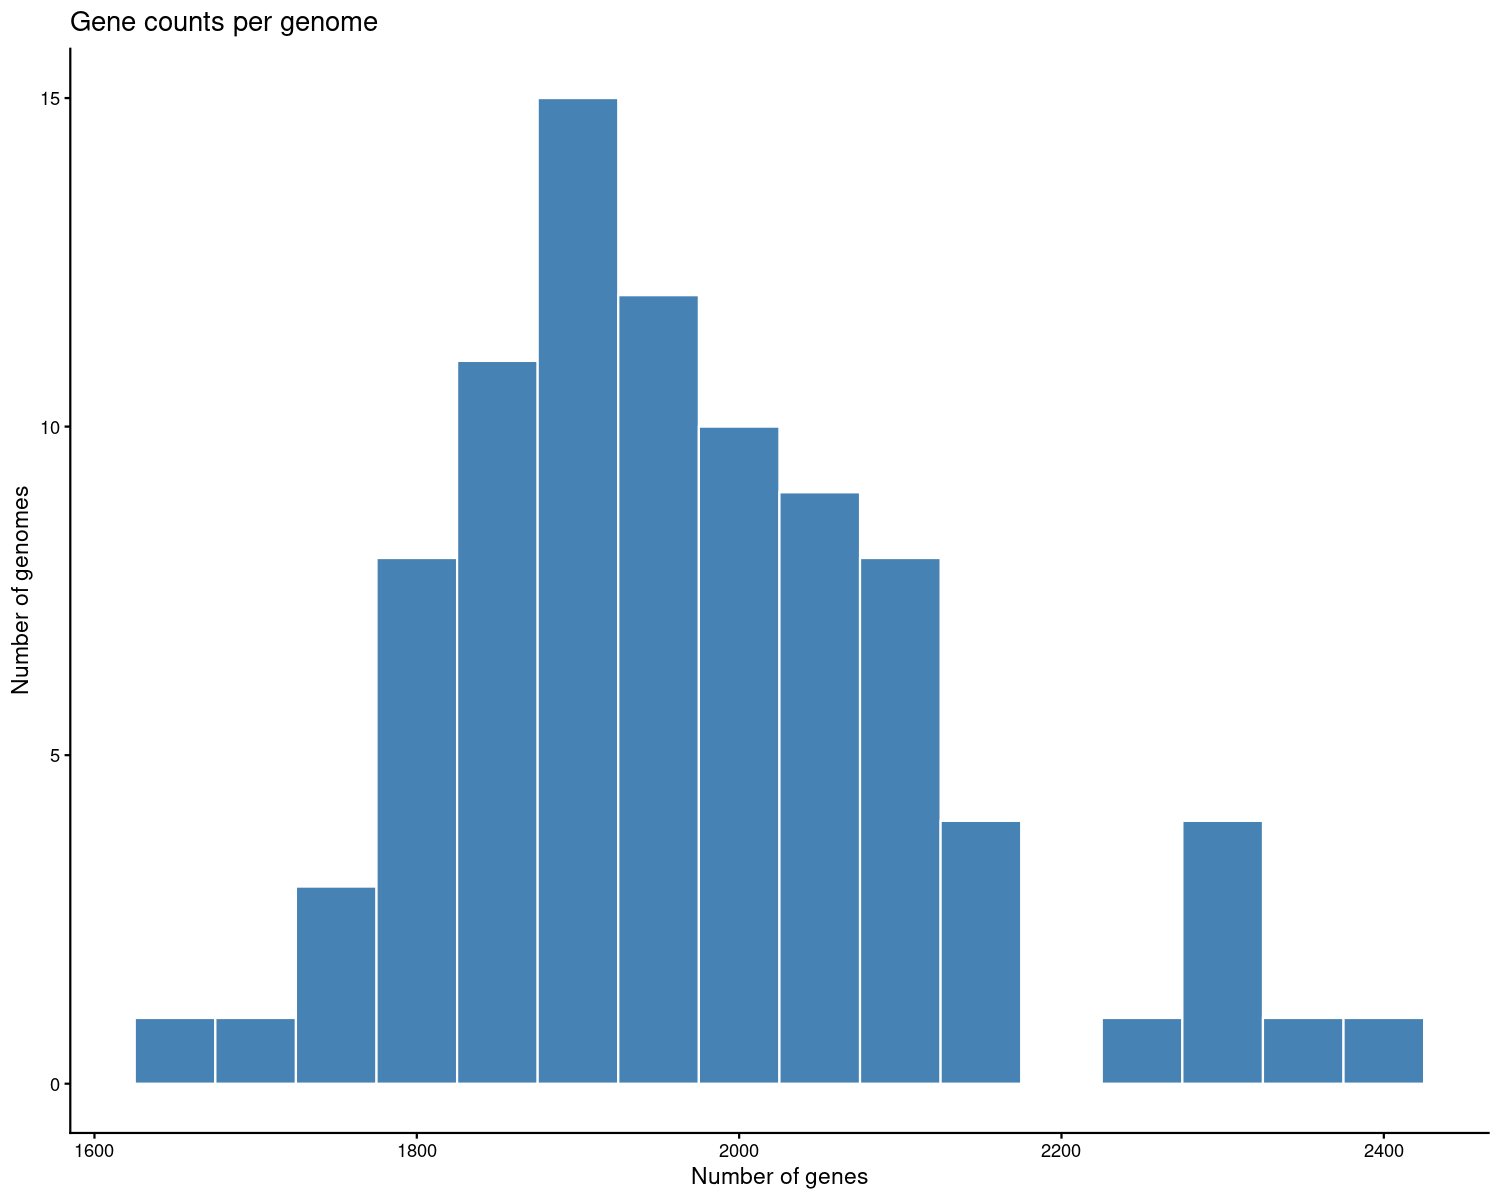

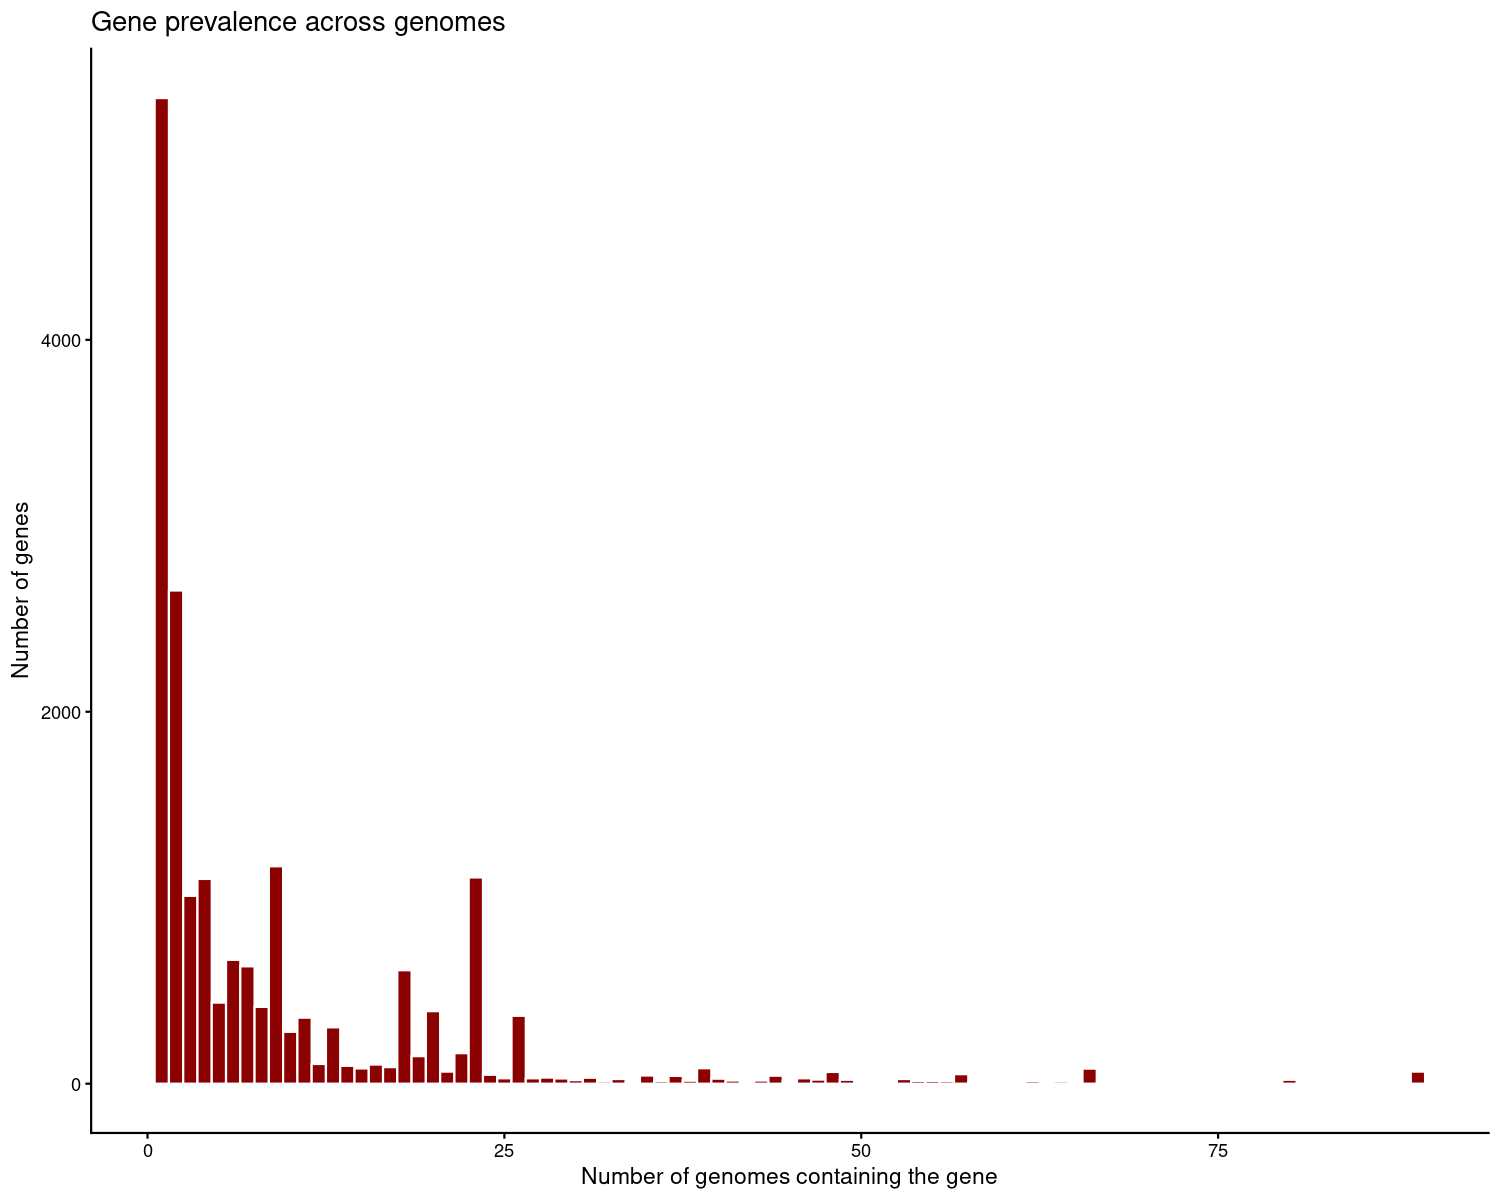

In [ ]:
# pangenome gene counts

pan <- read.table("../results/pangenome/gene_presence_absence.Rtab",
                  header = TRUE, row.names = 1, sep = "\t")

# presence/absence
pan_binary <- as.matrix(pan > 0)

# counts per genome
genes_per_genome <- colSums(pan_binary)
# counts per gene across genomes
genomes_per_gene <- rowSums(pan_binary)

gene_count_df <- tibble::tibble(
  sample = names(genes_per_genome),
  gene_count = as.integer(genes_per_genome)
)

gene_prevalence_df <- tibble::tibble(
  gene = names(genomes_per_gene),
  n_genomes = as.integer(genomes_per_gene)
)

# summary
summary_counts <- list(
  n_genomes = ncol(pan_binary),
  n_genes_total = nrow(pan_binary),
  core_genes = sum(genomes_per_gene == ncol(pan_binary)),
  accessory_genes = sum(genomes_per_gene > 1 & genomes_per_gene < ncol(pan_binary)),
  unique_genes = sum(genomes_per_gene == 1)
)

summary_counts

options(repr.plot.width = 10, repr.plot.height = 8)

# gene counts per genome
ggplot(gene_count_df, aes(x = gene_count)) +
  geom_histogram(binwidth = 50, fill = "steelblue", color = "white") +
  labs(
    title = "Gene counts per genome",
    x = "Number of genes",
    y = "Number of genomes"
  ) +
  theme_classic()

# gene prevalence across genomes
ggplot(gene_prevalence_df, aes(x = n_genomes)) +
  geom_histogram(binwidth = 1, fill = "darkred", color = "white") +
  labs(
    title = "Gene prevalence across genomes",
    x = "Number of genomes containing the gene",
    y = "Number of genes"
  ) +
  theme_classic()

Tree File analysis

In [43]:
tree <- read.tree("../results/pangenome/strep_core_tree.treefile")
pan <- read.table("../results/pangenome/gene_presence_absence.Rtab")


In [ ]:


tree <- midpoint.root(tree)

tree$tip.label <- sub("[-_].*$", "", tree$tip.label)
tree$tip.label <- sub("^0+", "", tree$tip.label)


head(tree$tip.label)

Loading required package: maps


Attaching package: ‘maps’


The following object is masked from ‘package:purrr’:

    map



Attaching package: ‘phytools’


The following object is masked from ‘package:vegan’:

    scores




[1] "160Ap" "68m"   "33Cm"  "151Cm" "148Cm" "48m"

In [47]:
colnames(species_df)
annot <- species_df |> select(-Resistance)

[1] "SAMPLE_ID"    "Resistance"   "Maldi_2"      "GTDB_214"     "match_status"

In [48]:
unique(species_df$Maldi_2)
unique(species_df$GTDB_214)

[1] "mitis oralis"  "anginosus"     "sanguinis"     "gordonii"     
 [5] "vestibularis"  "salivarius"    "parasanguinis" "cristatus"    
 [9] "infantis"      "constellatus"

[1] "no species"      "sp900555155"     "anginosus_C"     "sanguinis_H"    
 [5] "gordonii"        "vestibularis"    "sp001553685"     "salivarius"     
 [9] "parasanguinis"   "anginosus"       "xiaochunlingii"  "parasanguinis_C"
[13] "sp902460355"     "sp900766505"     "sp001556435"     "sanguinis"      
[17] "oralis"          "ilei"            "sanguinis_G"     "cristatus"      
[21] "infantis_F"      "sp001808705"     "parasanguinis_B" "parasanguinis_I"
[25] "oralis_I"        "parasanguinis_D" "mitis_AZ"        "sp001813295"    
[29] "oralis_K"        "oralis_T"        "parasanguinis_E" "constellatus"

In [49]:


maldi_colors <- c(
    "anginosus"     = "#B8E0B8",  # pastel green
    "constellatus"  = "#B8D4C8",  # pastel teal-green — anginosus group
    "salivarius"    = "#f7f293",  # pastel yellow
    "vestibularis"  = "#fedc93",  # pastel peach-yellow — salivarius group
    "mitis oralis"  = "#B8D4F0",  # pastel blue
    "infantis"      = "#CCB8F0",  # pastel lavender — M-clade with mitis
    "sanguinis"     = "#FFB8C8",  # pastel pink
    "gordonii"      = "#E8B8E8",  # pastel purple
    "parasanguinis" = "#fbb98c",  # pastel orange
    "cristatus"     = "#B8EEE8"   # pastel teal
)

gtdb_colors <- c(
    # anginosus — brighter greens
    "anginosus"      = "#2E8B2E",  # bright green
    "anginosus_C"    = "#52B052",  # mid green

    # constellatus — brighter teal-green (anginosus group)
    "constellatus"   = "#2E7A5A",  # bright teal-green

    # salivarius — brighter yellows
    "salivarius"     = "#E8D800",  # bright yellow
    "sp001556435"    = "#C8B800",  # deeper yellow — related to salivarius
    "infantis_F"     = "#D4C400",  # gold-yellow — GTDB groups with salivarius

    # vestibularis — brighter peach-yellows (salivarius group)
    "vestibularis"   = "#FFB300",  # bright amber

    # mitis oralis — brighter blues (M-clade)
    "oralis"         = "#1E7EC8",  # bright blue
    "oralis_I"       = "#1A6AAA",  # slightly darker blue
    "oralis_K"       = "#1458A0",  # deeper blue
    "oralis_T"       = "#3D8FD4",  # lighter bright blue
    "mitis_AZ"       = "#0D4F8C",  # dark blue
    "ilei"           = "#0A3D6E",  # navy — mitis group
    "sp001553685"    = "#2E5FA8",  # indigo-blue — mitis group
    "sp001808705"    = "#4A78C0",  # lighter indigo — mitis group

    # infantis — brighter purples (M-clade with mitis/oralis)
    "infantis_F"     = "#7B4EC8",  # bright purple
    # note: infantis_F is in salivarius group per GTDB — kept both options,
    # use whichever matches your actual tree clustering

    # sanguinis — brighter pinks
    "sanguinis"      = "#E81050",  # bright pink-red
    "sanguinis_G"    = "#CC0D44",  # darker pink-red
    "sanguinis_H"    = "#FF3D6E",  # lighter bright pink

    # gordonii — brighter purples
    "gordonii"       = "#A020C8",  # bright purple
    "sp902460355"    = "#8818A8",  # deeper purple — related to gordonii

    # parasanguinis — brighter oranges (S-clade)
    "parasanguinis"   = "#FF6A00",  # bright orange
    "parasanguinis_B" = "#E85A00",  # slightly deeper orange
    "parasanguinis_C" = "#FF8C00",  # lighter orange
    "parasanguinis_D" = "#CC5500",  # darker orange
    "parasanguinis_E" = "#FF4500",  # red-orange
    "parasanguinis_I" = "#B83C00",  # dark red-orange
    "xiaochunlingii"  = "#FFA040",  # pale bright orange — related to parasanguinis
    "sp900766505"     = "#FF7820",  # mid orange
    "sp001813295"     = "#FF9050",  # light orange
    "sp001813295"     = "#FF9050",

    # cristatus — brighter teals (S-clade)
    "cristatus"      = "#00A896",  # bright teal

    # no species / unresolved — greys
    "no species"     = "#AAAAAA",
    "sp900555155"    = "#888888",
    "sp001556435"    = "#CCCCCC"   # if unresolved, grey fallback
)


# legend order
maldi_order <- c(
    "anginosus",
    "constellatus",
    "salivarius",
    "vestibularis",
    "mitis oralis",
    "infantis",
    "sanguinis",
    "gordonii",
    "parasanguinis",
    "cristatus"
)

gtdb_order <- c(
    # anginosus group
    "anginosus",
    "anginosus_C",
    # constellatus group
    "constellatus",
    # salivarius group
    "salivarius",
    "sp001556435",
    "infantis_F",
    # vestibularis
    "vestibularis",
    # mitis oralis M-clade
    "oralis",
    "oralis_I",
    "oralis_K",
    "oralis_T",
    "mitis_AZ",
    "ilei",
    "sp001553685",
    "sp001808705",
    # sanguinis
    "sanguinis",
    "sanguinis_G",
    "sanguinis_H",
    # gordonii
    "gordonii",
    "sp902460355",
    # parasanguinis
    "parasanguinis",
    "parasanguinis_B",
    "parasanguinis_C",
    "parasanguinis_D",
    "parasanguinis_E",
    "parasanguinis_I",
    "xiaochunlingii",
    "sp900766505",
    "sp001813295",
    # cristatus
    "cristatus",
    # unresolved
    "no species",
    "sp900555155"
)




Cladogram:

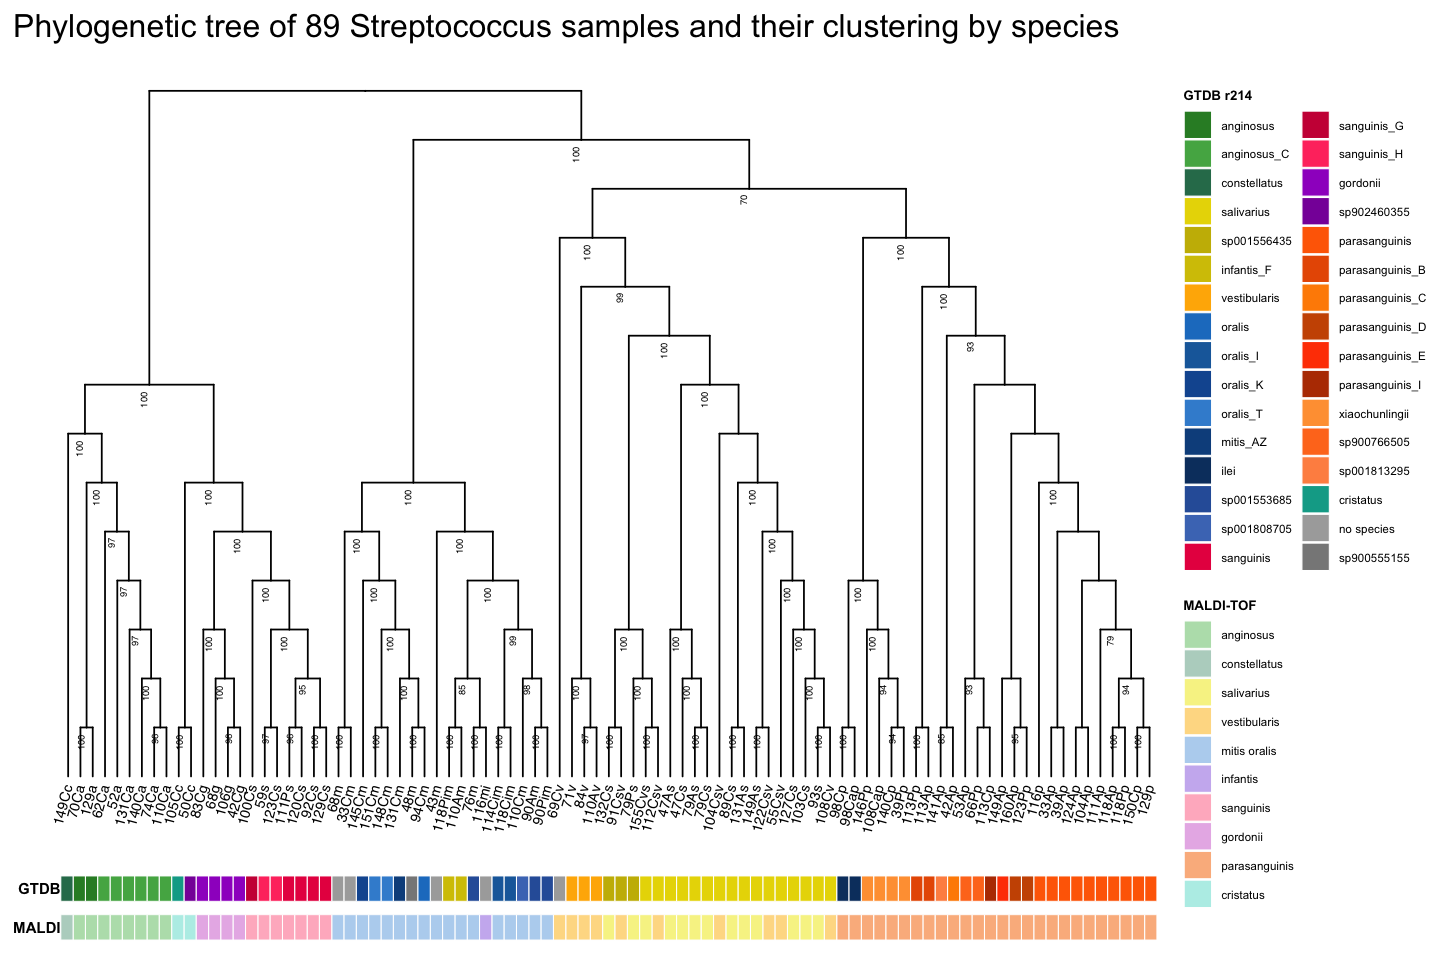

In [50]:
p_base_clado <- ggtree(tree, layout="rectangular", branch.length="none") %<+% annot +
    layout_dendrogram()

# tip order may differ slightly from branch length version
# always re-extract it from the new plot

tip_order_clado <- get_taxa_name(p_base_clado)
p_tree_clado <- p_base_clado +
    geom_nodelab(
        aes(label=label,
            subset=suppressWarnings(as.numeric(label)) >= 70 &
                   !is.na(suppressWarnings(as.numeric(label)))),
        size=2, hjust=1.2, vjust=-0.3
    ) +
    geom_tiplab(
        aes(label=label),   
        angle=75,         
        hjust=1,            
        size=3,
        offset=-0.1          # small gap between tip end and label start
    ) +
    theme(plot.margin=margin(0, 0, 30, 0))  # room for labels
                                           

tip_order_clado <- rev(tip_order_clado)

# order sample id by tip order
annot_ordered_clado <- annot %>%
    filter(SAMPLE_ID %in% tip_order_clado) %>%
    mutate(label=factor(SAMPLE_ID, levels=tip_order_clado))


p_gtdb_clado <- ggplot(annot_ordered_clado, aes(x=label, y=1, fill=GTDB_214)) +
    geom_tile(color="white", linewidth=0.3) +
    scale_fill_manual(
        "GTDB r214",
        values   = gtdb_colors,
        breaks   = gtdb_order,    # legend order
        na.value = "white"
    ) +
    scale_x_discrete(expand=c(0,0)) +
    scale_y_continuous(expand=c(0,0)) +
    labs(y="GTDB") +
    theme_void() +
    theme(
        axis.title.y    = element_text(size=9, angle=0, vjust=0.5, hjust=1,
                                       face="bold"),
        legend.position = "right",
        legend.text     = element_text(size=7),
        legend.title    = element_text(size=8, face="bold"),
        plot.margin     = margin(4, 0, 4, 0)
    )

p_maldi_clado <- ggplot(annot_ordered_clado, aes(x=label, y=1, fill=Maldi_2)) +
    geom_tile(color="white", linewidth=0.3) +
    scale_fill_manual(
        "MALDI-TOF",
        values   = maldi_colors,
        breaks   = maldi_order,    # legend order
        na.value = "white"
    ) +
    scale_x_discrete(expand=c(0,0)) +
    scale_y_continuous(expand=c(0,0)) +
    labs(y="MALDI") +
    theme_void() +
    theme(
        axis.title.y    = element_text(size=9, angle=0, vjust=0.5, hjust=1,
                                       face="bold"),
        legend.position = "right",
        legend.text     = element_text(size=7),
        legend.title    = element_text(size=8, face="bold"),
        plot.margin     = margin(4, 0, 4, 0)
    ) 

# combine plot
p_combined_clado <- p_tree_clado / p_gtdb_clado / p_maldi_clado +
    plot_layout(
        heights = c(0.3, 0.01, 0.01, 0),
        guides  = "collect"
    ) &
    theme(legend.position="right")

options(repr.plot.width = 12, repr.plot.height = 8)

p_combined_clado +
  plot_annotation(
    title = "Phylogenetic tree of 89 Streptococcus samples and their clustering by species"
  )




Tree:

In [51]:
p_base <- ggtree(tree, layout="rectangular") %<+% annot +
    layout_dendrogram()

p_tree <- p_base +
    geom_nodelab(
        aes(label=label,
            subset=suppressWarnings(as.numeric(label)) >= 70 &
                   !is.na(suppressWarnings(as.numeric(label)))),
        size=2, hjust=1.2, vjust=-0.3
    ) +
    geom_tiplab(
        aes(label=label),   
        angle=75,         
        hjust=1,            
        size=2.5
        #offset=-0.01
        
    ) +
    theme(plot.margin=margin(0, 0, 10, 0))  # room for labels



In [52]:

p_tree <- p_base +
    geom_point2(
        aes(
            color = suppressWarnings(as.numeric(label)),
            subset = !is.na(suppressWarnings(as.numeric(label)))
        ),
        size = 1.5
    ) +
    scale_color_gradient(
        name = "Node support",
        low = "#d4c0c0",
        high = "#420101"
    ) +
    geom_tiplab(
        aes(label = label),
        angle = 90,
        hjust = 1,
        size = 3,
    ) +
    theme(plot.margin = margin(0, 0, 30, 0))



Filtered heatmap:

In [53]:
pan <- read.table("../results/pangenome/gene_presence_absence.Rtab", 
                  header=TRUE, row.names=1, sep="\t")

# clean names
clean_pan_names <- function(x) {
  x <- sub("^X0*", "", x)          # remove leading X and zeros
  x <- sub("\\..*$", "", x)         # remove dot and everything after
  x
}

colnames(pan) <- clean_pan_names(colnames(pan))

# filter to accessory genome
n_samples <- ncol(pan)
prevalence <- rowSums(pan) / n_samples

pan_acc <- pan[prevalence > 0.01 & prevalence < 0.99, ]

#filter  by variability
gene_var <- apply(pan_acc, 1, var)
pan_acc  <- pan_acc[order(gene_var, decreasing=TRUE)[1:1000], ]

# pivot to long
pan_long <- pan_acc |>
  as.data.frame() |>
  rownames_to_column("gene") |>
  pivot_longer(-gene, names_to="sample", values_to="present") |>
  mutate(
    sample  = factor(sample, levels=tip_order_clado),   # same order as tree
    present = factor(present, levels=c(1, 0))
  ) |>
  filter(!is.na(sample))   # drop any samples not in the tree

p_pan_clado <- ggplot(pan_long, aes(x=sample, y=gene, fill=present)) +
  geom_tile(linewidth=0) +
  scale_fill_manual(
    "Gene",
    values   = c("1"="#2c7bb6", "0"="grey93"),
    labels   = c("1"="Present", "0"="Absent"),
    na.value = "white"
  ) +
  scale_x_discrete(expand=c(0, 0)) +
  scale_y_discrete(expand=c(0, 0)) +
  labs(y="") +
  theme_void() +
  theme(
    axis.title.y    = element_text(size=9, angle=0, vjust=0.5, hjust=1,
                                   face="bold"),
    axis.text.y     = element_blank(),   # too many genes to label; set size=4 if you want them
    legend.position = "right",
    legend.text     = element_text(size=7),
    legend.title    = element_text(size=8, face="bold"),
    plot.margin     = margin(4, 0, 4, 0)
  )




Unfiltered heatmap:

In [54]:
# pivot to long: show ALL genes
pan_long_all <- pan |>
  as.data.frame() |>
  rownames_to_column("gene") |>
  pivot_longer(-gene, names_to = "sample", values_to = "present") |>
  mutate(
    sample  = factor(sample, levels = tip_order_clado),   # same order as tree
    gene    = factor(gene, levels = rev(unique(gene))),   # keep all genes, top-to-bottom
    present = factor(present, levels = c(1, 0))
  ) |>
  filter(!is.na(sample))   # drop any samples not in the tree

p_pan_clado_all <- ggplot(pan_long_all, aes(x = sample, y = gene, fill = present)) +
  geom_tile(linewidth = 0) +
  scale_fill_manual(
    "Gene",
    values   = c("1" = "#2c7bb6", "0" = "grey93"),
    labels   = c("1" = "Present", "0" = "Absent"),
    na.value = "white"
  ) +
  scale_x_discrete(expand = c(0, 0)) +
  scale_y_discrete(expand = c(0, 0)) +
  labs(y = "") +
  theme_void() +
  theme(
    axis.title.y    = element_text(size = 9, angle = 0, vjust = 0.5, hjust = 1, face = "bold"),
    axis.text.y     = element_blank(),
    legend.position = "right",
    legend.text     = element_text(size = 7),
    legend.title    = element_text(size = 8, face = "bold"),
    plot.margin     = margin(4, 0, 4, 0)
  )



Filtered with no unique:

In [55]:
# remove unique genes: keep genes found in >1 sample
pan_no_unique <- pan[rowSums(pan > 0) > 1, , drop = FALSE]

pan_long_no_unique <- pan_no_unique |>
  as.data.frame() |>
  rownames_to_column("gene") |>
  pivot_longer(-gene, names_to = "sample", values_to = "present") |>
  mutate(
    sample  = factor(sample, levels = tip_order_clado),
    gene    = factor(gene, levels = rev(unique(gene))),
    present = factor(present, levels = c(1, 0))
  ) |>
  filter(!is.na(sample))

p_pan_clado_no_unique <- ggplot(pan_long_no_unique, aes(x = sample, y = gene, fill = present)) +
  geom_tile(linewidth = 0) +
  scale_fill_manual(
    "Gene",
    values   = c("1" = "#14212b", "0" = "grey93"),
    labels   = c("1" = "Present", "0" = "Absent"),
    na.value = "white"
  ) +
  scale_x_discrete(expand = c(0, 0)) +
  scale_y_discrete(expand = c(0, 0)) +
  labs(y = "") +
  theme_void() +
  theme(
    axis.title.y    = element_text(size = 9, angle = 0, vjust = 0.5, hjust = 1, face = "bold"),
    axis.text.y     = element_blank(),
    legend.position = "right",
    legend.text     = element_text(size = 7),
    legend.title    = element_text(size = 8, face = "bold"),
    plot.margin     = margin(4, 0, 4, 0)
  )


In [56]:
nrow(pan_no_unique)

[1] 13468

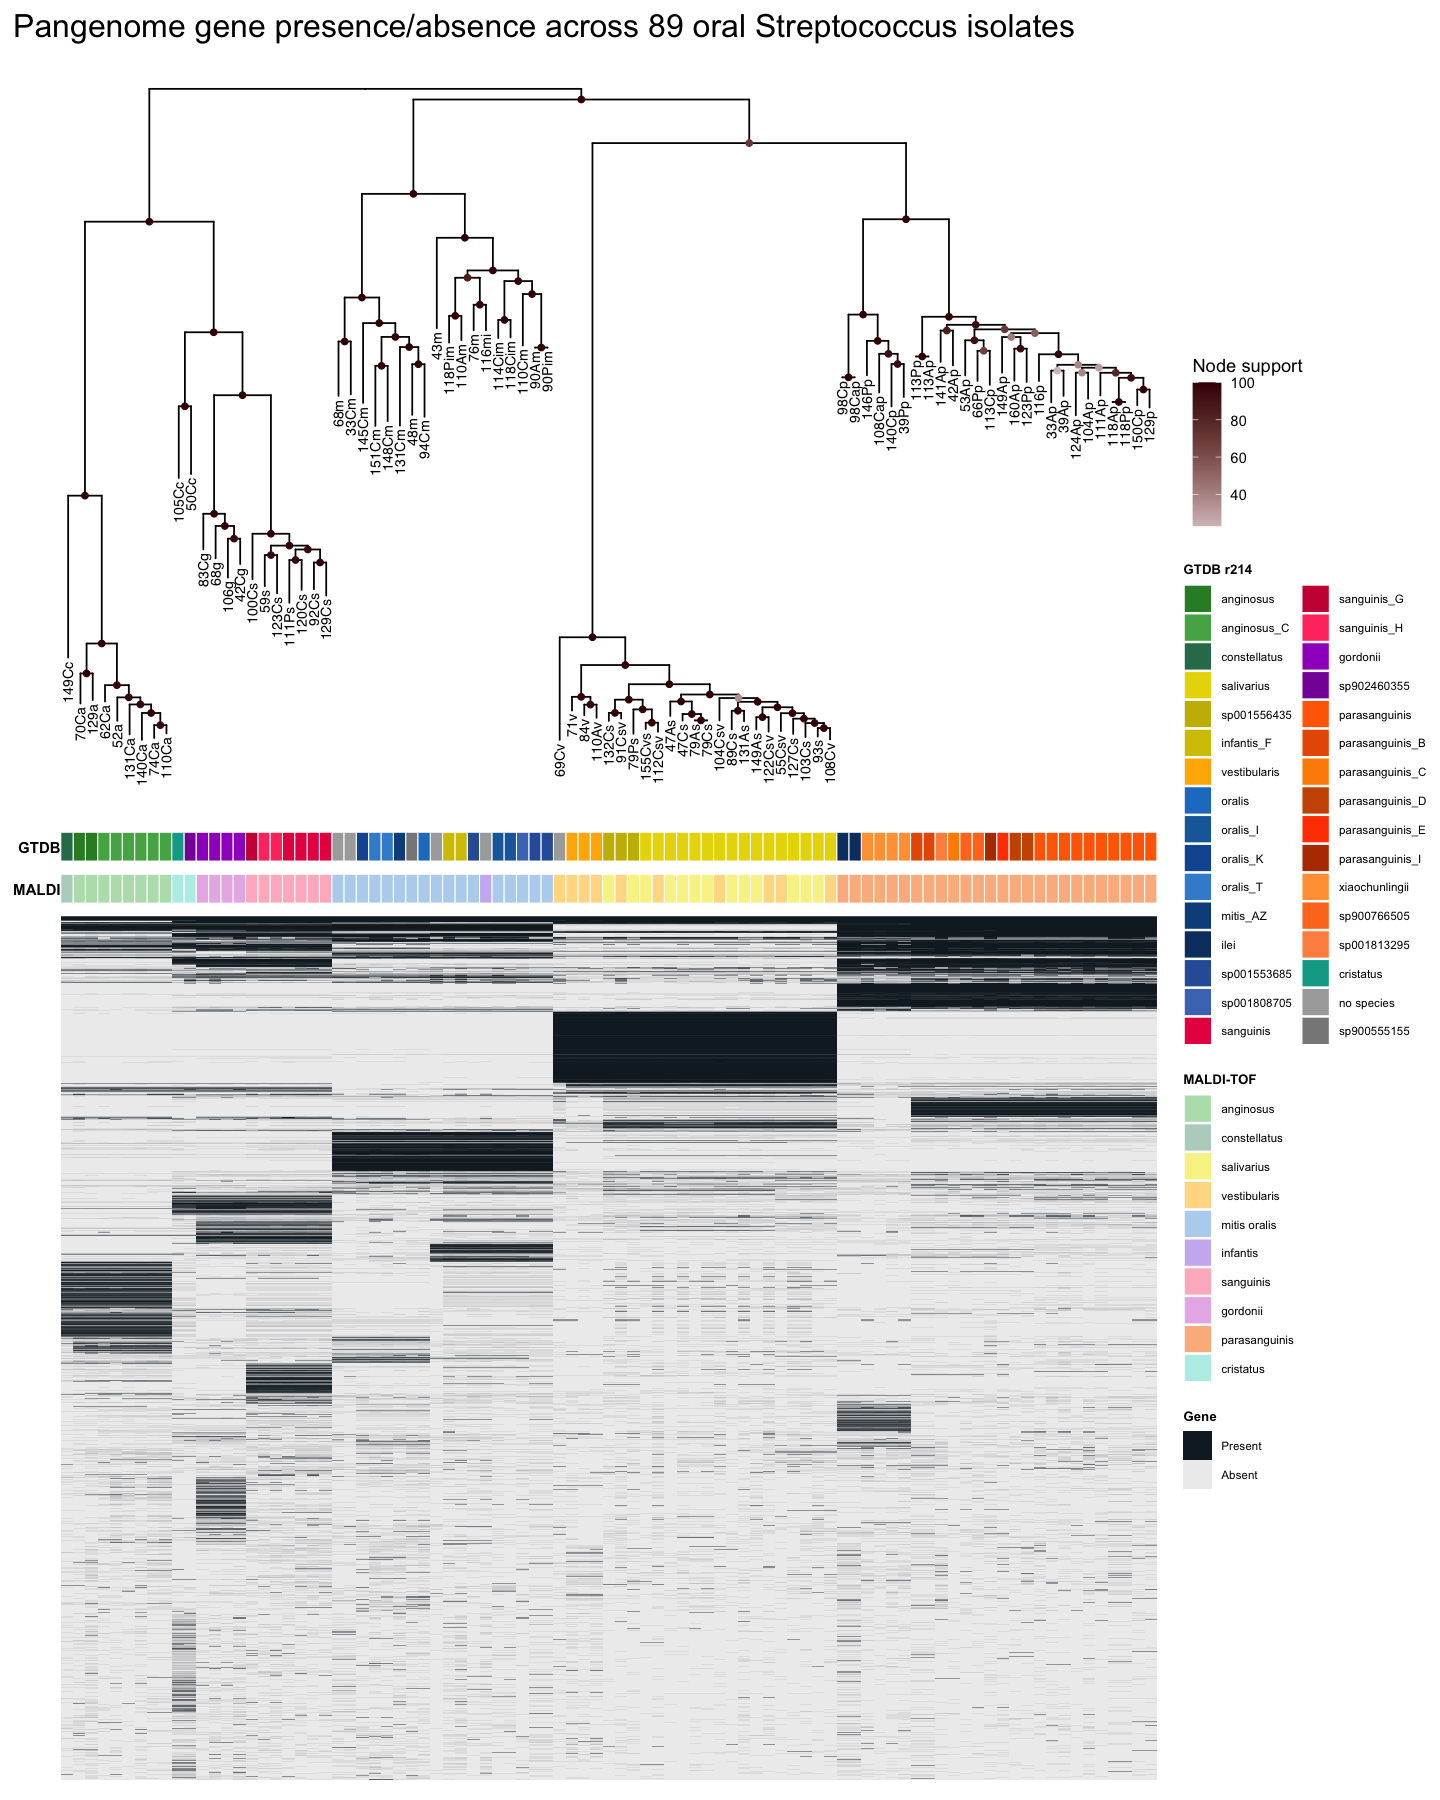

In [57]:
p_combined <- p_tree / p_gtdb_clado / p_maldi_clado / p_pan_clado_no_unique +
  plot_layout(
    heights = c(0.25, 0.01, 0.01, 0.3),   # give the heatmap more height
    guides  = "collect"
  ) &
  theme(legend.position="right")

options(repr.plot.width=12, repr.plot.height=15)   # slightly taller for extra panel

p_combined +
  plot_annotation(
    title="Pangenome gene presence/absence across 89 oral Streptococcus isolates"
  )


connect it to the disagreement between gtdb and maldi, is maldi making bad calls or are genomes really so differnt

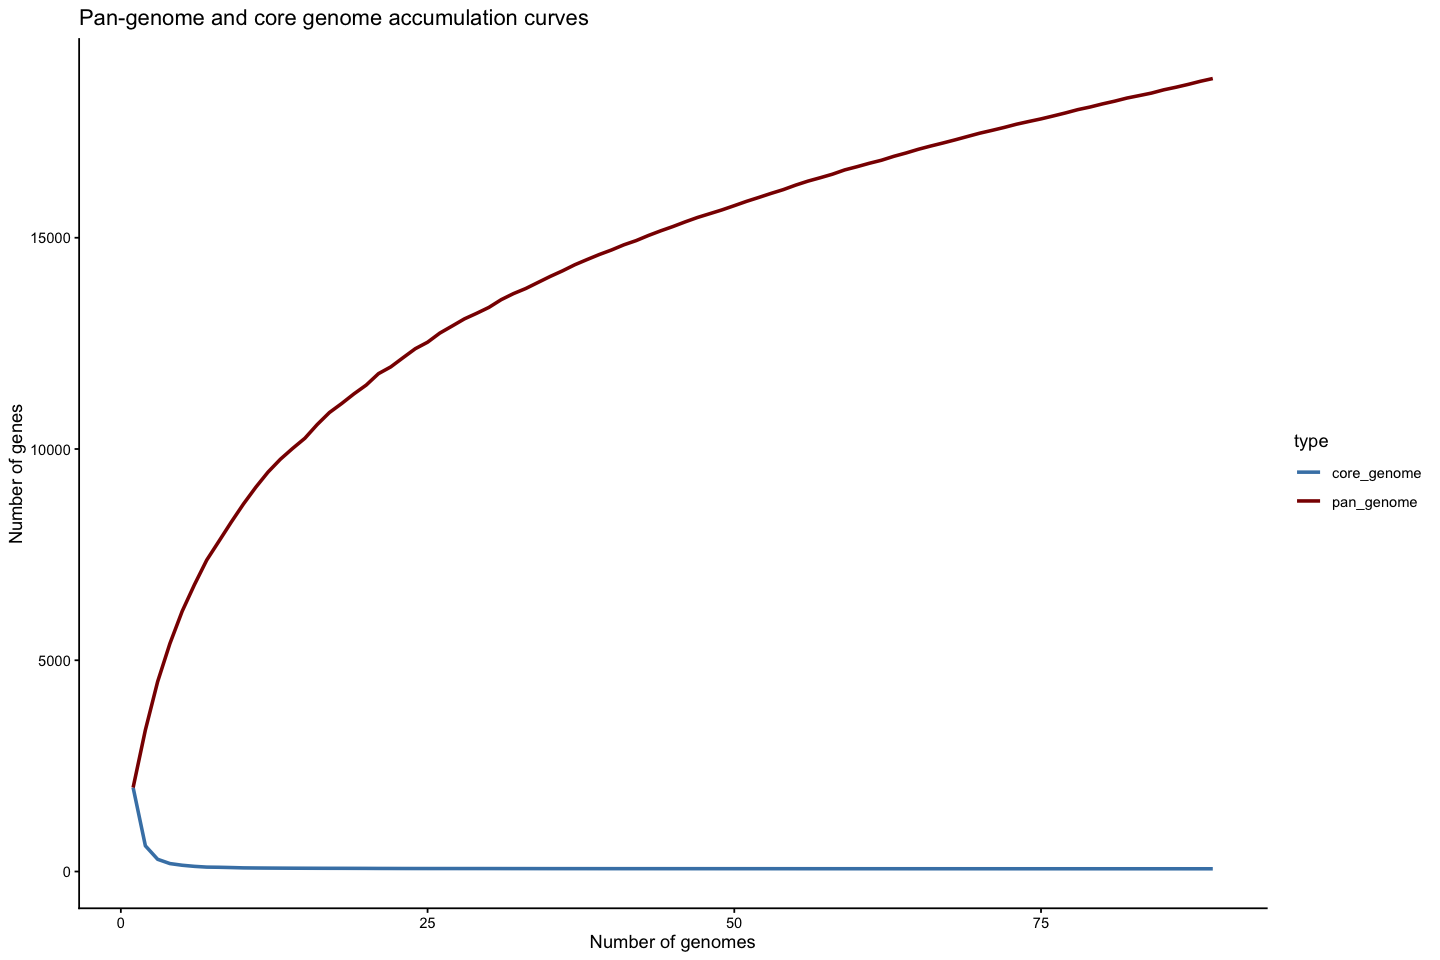

In [58]:
options(repr.plot.width = 12, repr.plot.height = 8)

# rarefaction curve — how many new genes added per new genome
# randomly subsample and count unique genes at each n
set.seed(42)
n_perms <- 100
pan_binary <- as.matrix(pan > 0)

pan_size    <- numeric(ncol(pan_binary))
core_size   <- numeric(ncol(pan_binary))

for (i in 1:n_perms) {
    sample_order <- sample(ncol(pan_binary))
    cumulative_genes <- 0
    for (j in seq_along(sample_order)) {
        subset <- pan_binary[, sample_order[1:j], drop=FALSE]
        pan_size[j]  <- pan_size[j]  + sum(rowSums(subset) >= 1)
        core_size[j] <- core_size[j] + sum(rowSums(subset) == j)
    }
}

pan_curve  <- pan_size  / n_perms
core_curve <- core_size / n_perms

curve_df <- data.frame(
    n_genomes  = 1:ncol(pan_binary),
    pan_genome = pan_curve,
    core_genome = core_curve
) %>%
    pivot_longer(-n_genomes, names_to="type", values_to="genes")

ggplot(curve_df, aes(x=n_genomes, y=genes, color=type)) +
    geom_line(linewidth=1) +
    scale_color_manual(values=c("pan_genome"="darkred", "core_genome"="steelblue")) +
    labs(x="Number of genomes", y="Number of genes",
         title="Pan-genome and core genome accumulation curves") +
    theme_classic()